#**Business Case: Delhivery - Feature Engineering**
###**Name : Asit Nayak**

In [1]:
# importing the required modules and packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import re
from scipy.stats import norm,zscore,boxcox,probplot
from scipy.stats import ttest_ind,ttest_rel,mannwhitneyu,wilcoxon
from scipy.stats import shapiro,levene,kstest,anderson
import statsmodels.api as sm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler , MinMaxScaler , OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
# pd_reading the data
delhivery_data = pd.read_csv('/content/sample_data/delhivery_data.csv')

In [3]:
# setting the option of displaying all the columns
pd.set_option('display.max_columns', 50)

In [4]:
# making a deep copy for backup
dd = delhivery_data.copy()
dd.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,9.0,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,18.0,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,27.0,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,True,36.0,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,2018-09-20 04:47:45.236797,86.0,False,39.0,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


#Exploration of data

In [6]:
dd.shape

(65532, 24)

In [7]:
dd.columns

Index(['data', 'trip_creation_time', 'route_schedule_uuid', 'route_type',
       'trip_uuid', 'source_center', 'source_name', 'destination_center',
       'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'is_cutoff', 'cutoff_factor',
       'cutoff_timestamp', 'actual_distance_to_destination', 'actual_time',
       'osrm_time', 'osrm_distance', 'factor', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_factor'],
      dtype='object')

In [9]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65532 entries, 0 to 65531
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   data                            65532 non-null  object 
 1   trip_creation_time              65532 non-null  object 
 2   route_schedule_uuid             65532 non-null  object 
 3   route_type                      65532 non-null  object 
 4   trip_uuid                       65532 non-null  object 
 5   source_center                   65531 non-null  object 
 6   source_name                     65391 non-null  object 
 7   destination_center              65531 non-null  object 
 8   destination_name                65435 non-null  object 
 9   od_start_time                   65531 non-null  object 
 10  od_end_time                     65531 non-null  object 
 11  start_scan_to_end_scan          65531 non-null  float64
 12  is_cutoff                       

#Statistical summary

In [11]:
dd.describe().T

,count,mean,std,min,25%,50%,75%,max
start_scan_to_end_scan,65531.0,937.287833,1011.057079,20.000000,163.000000,449.000000,1528.000000,4535.000000
cutoff_factor,65531.0,226.931727,335.333076,9.000000,22.000000,66.000000,286.000000,1927.000000
actual_distance_to_destination,65531.0,228.076713,335.542702,9.000267,23.373592,66.116690,286.191741,1927.447705
actual_time,65531.0,406.070470,580.964622,9.000000,52.000000,132.000000,500.000000,4532.000000
osrm_time,65531.0,208.683722,300.031194,6.000000,27.000000,64.000000,251.500000,1686.000000
osrm_distance,65531.0,277.767490,410.247141,9.072900,29.930400,78.607500,334.891250,2326.199100
factor,65531.0,2.106788,1.497202,0.203125,1.607866,1.857143,2.216409,77.387097
segment_actual_time,65531.0,36.024828,51.271562,-211.000000,20.000000,29.000000,40.000000,2464.000000
segment_osrm_time,65531.0,18.467061,14.268028,0.000000,11.000000,17.000000,22.000000,997.000000
segment_osrm_distance,65531.0,22.768476,17.152820,0.000000,12.065200,23.506000,27.787450,1367.592800


In [12]:
dd.describe(include=object).T

,count,unique,top,freq
data,65532,2,training,47390
trip_creation_time,65532,6692,2018-10-01 05:04:55.268931,101
route_schedule_uuid,65532,1341,thanos::sroute:dca6268f-741a-4d1a-b1b0-aab1309...,764
route_type,65532,2,FTL,44991
trip_uuid,65532,6692,trip-153837029526866991,101
source_center,65531,1381,IND000000ACB,10405
source_name,65391,1374,Gurgaon_Bilaspur_HB (Haryana),10405
destination_center,65531,1343,IND000000ACB,6844
destination_name,65435,1332,Gurgaon_Bilaspur_HB (Haryana),6844
od_start_time,65531,11891,2018-09-21 18:37:09.322207,81


#Duplication detection

In [14]:
dd[dd.duplicated()]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor


#Insights

In [17]:
dd.isna().any()

,0
data,False
trip_creation_time,False
route_schedule_uuid,False
route_type,False
trip_uuid,False
source_center,True
source_name,True
destination_center,True
destination_name,True
od_start_time,True


In [18]:
dd.isna().sum()

,0
data,0
trip_creation_time,0
route_schedule_uuid,0
route_type,0
trip_uuid,0
source_center,1
source_name,141
destination_center,1
destination_name,97
od_start_time,1


In [21]:
def missing_data(df):
    total_missing_df = df.isnull().sum().sort_values(ascending =False)
    percent_missing_df = (df.isnull().sum()/df.isna().count()*100).sort_values(ascending=False) # ----> /len(dd)
    missing_data_df = pd.concat([total_missing_df, percent_missing_df], axis=1, keys=['Total', 'Percent'])
    return missing_data_df

missing_pct = missing_data(dd)
missing_pct[missing_pct['Total']>0]

,Total,Percent
source_name,141,0.215162
destination_name,97,0.148019
destination_center,1,0.001526
source_center,1,0.001526
start_scan_to_end_scan,1,0.001526
od_end_time,1,0.001526
od_start_time,1,0.001526
is_cutoff,1,0.001526
actual_time,1,0.001526
osrm_time,1,0.001526


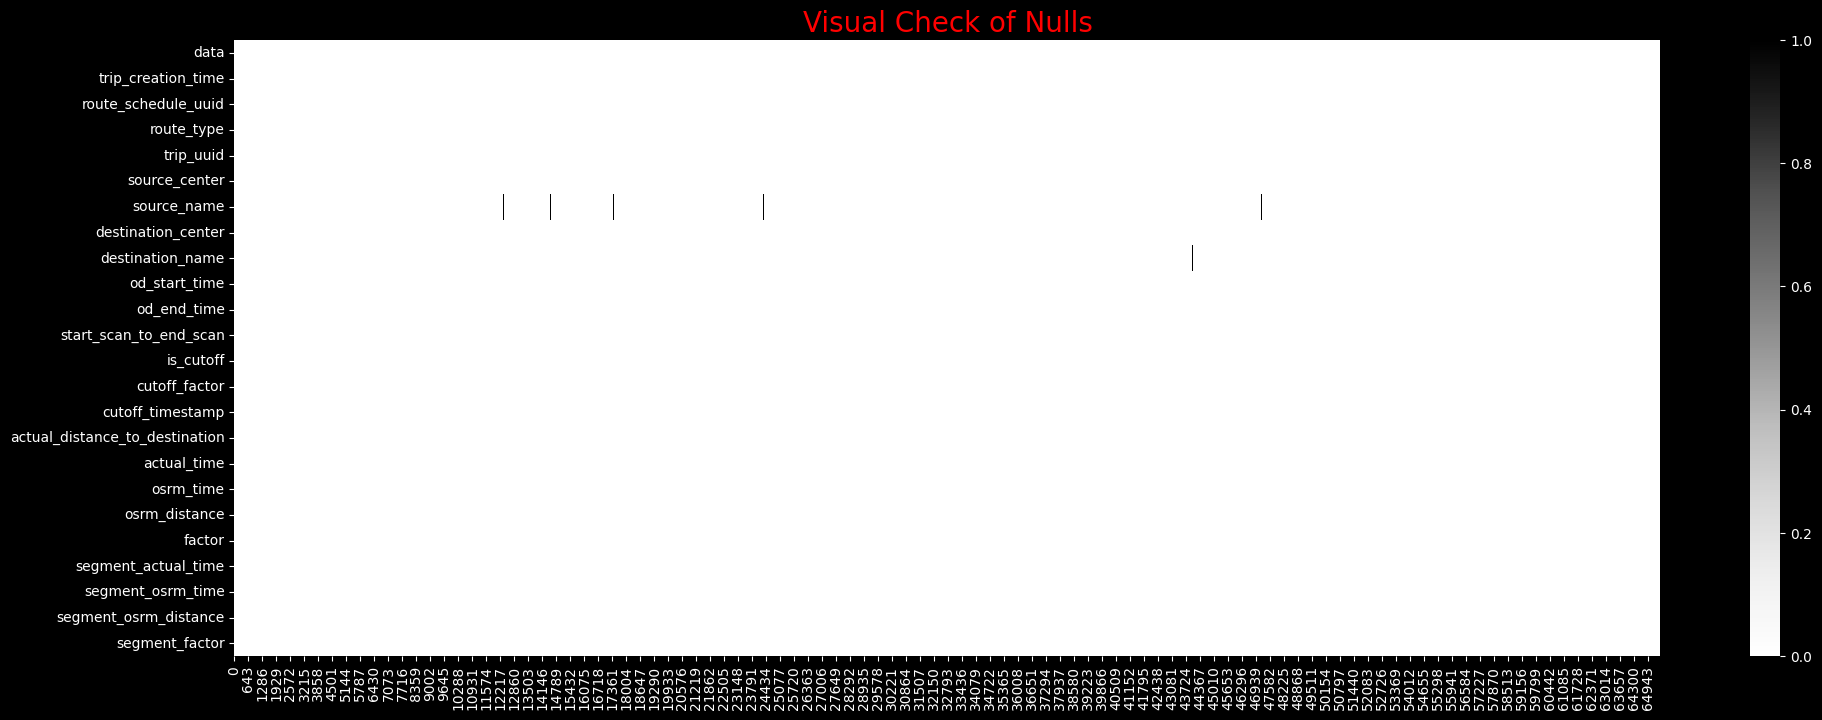

In [24]:
plt.figure(figsize=(23,8))
plt.style.use('dark_background')
sns.heatmap(dd.isnull().T,cmap='Greys')
plt.title('Visual Check of Nulls',fontsize=20,color='r')
plt.show()

In [28]:
dd[dd['destination_center'].isna()]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,is_cutoff,cutoff_factor,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
65531,training,2018-09-20 20:44:57.424801,thanos::sroute:ed5b80be-7abf-424d-b8cd-d81556a...,FTL,trip-153747629742455165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
dd = dd.dropna(subset=['destination_center'])

In [30]:
def missing_data(df):
    total_missing_df = df.isnull().sum().sort_values(ascending =False)
    percent_missing_df = (df.isnull().sum()/df.isna().count()*100).sort_values(ascending=False) # ----> /len(dd)
    missing_data_df = pd.concat([total_missing_df, percent_missing_df], axis=1, keys=['Total', 'Percent'])
    return missing_data_df

missing_pct = missing_data(dd)
missing_pct[missing_pct['Total']>0]

,Total,Percent
source_name,140,0.213639
destination_name,96,0.146496


In [31]:
# Dropping unknown fields

unknown_fields = ['is_cutoff', 'cutoff_factor', 'cutoff_timestamp', 'factor', 'segment_factor']
dd = dd.drop(columns = unknown_fields)

In [32]:
dd.sample()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
9024,test,2018-09-28 19:07:27.563134,thanos::sroute:6e01eb09-11ca-4a88-839f-2fe0836...,Carting,trip-153816164756290062,IND400072AAB,Mumbai Hub (Maharashtra),IND421302AAR,Mumbai_East_I_21 (Maharashtra),2018-09-28 19:07:27.563134,2018-09-28 20:49:49.894396,102.0,18.467108,39.0,20.0,24.6404,20.0,9.0,11.2408


In [33]:
dd.shape

(65531, 19)

In [39]:
#checking the unique values for columns
for _ in dd.columns:
    print()
    print(f'Total Unique Values in {_} column are :- {dd[_].nunique()}')
    print(f'Unique Values in {_} column are :-\n {dd[_].unique() if dd[_].nunique() <= 10 else str(dd[_].unique()[:15]) + " and more"}')
    print()
    print('-'*120)


Total Unique Values in data column are :- 2
Unique Values in data column are :-
 ['training' 'test']

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in trip_creation_time column are :- 6692
Unique Values in trip_creation_time column are :-
 ['2018-09-20 02:35:36.476840' '2018-09-23 06:42:06.021680'
 '2018-09-14 15:42:46.437249' '2018-09-13 20:44:19.424489'
 '2018-09-29 22:21:45.149226' '2018-09-17 21:26:00.454695'
 '2018-09-12 01:33:48.711350' '2018-10-01 16:00:45.719099'
 '2018-09-27 14:16:14.819357' '2018-09-13 16:41:41.992300'
 '2018-09-28 21:11:40.693356' '2018-09-25 08:53:04.377810'
 '2018-09-25 15:29:19.647336' '2018-09-15 23:58:16.827101'
 '2018-09-18 19:50:53.096021'] and more

------------------------------------------------------------------------------------------------------------------------

Total Unique Values in route_schedule_uuid column are :- 1341
Unique Values in route_sc

#Changing the datatype of columns

In [40]:
dd.sample()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
53020,training,2018-09-18 10:27:42.872583,thanos::sroute:b9622248-4dfb-4964-8f1d-ec5f83f...,FTL,trip-153726646287232095,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-18 10:27:42.872583,2018-09-18 22:07:26.687675,699.0,88.821254,148.0,73.0,102.0894,46.0,16.0,23.8526


In [43]:
dd.dtypes

,0
data,object
trip_creation_time,object
route_schedule_uuid,object
route_type,object
trip_uuid,object
source_center,object
source_name,object
destination_center,object
destination_name,object
od_start_time,object


In [44]:
# Converting the datatypes to category for columns like data and route_type as they only have 2 values.
dd['data'] = dd['data'].astype('category')
dd['route_type'] = dd['route_type'].astype('category')

# Converting time columns to datetime format
datetime_cols = ['trip_creation_time', 'od_start_time', 'od_end_time']
for _ in datetime_cols:
    dd[_] = pd.to_datetime(dd[_])

In [45]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65531 entries, 0 to 65530
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            65531 non-null  category      
 1   trip_creation_time              65531 non-null  datetime64[ns]
 2   route_schedule_uuid             65531 non-null  object        
 3   route_type                      65531 non-null  category      
 4   trip_uuid                       65531 non-null  object        
 5   source_center                   65531 non-null  object        
 6   source_name                     65391 non-null  object        
 7   destination_center              65531 non-null  object        
 8   destination_name                65435 non-null  object        
 9   od_start_time                   65531 non-null  datetime64[ns]
 10  od_end_time                     65531 non-null  datetime64[ns]
 11  start_s

In [46]:
float_cols = []
for _ in dd.columns:
    if dd[_].dtype=='float64':
        float_cols.append(_)
float_cols

['start_scan_to_end_scan',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance']

In [47]:
# reducing the float64 to float32 to save memory
for _ in float_cols:
    dd[_] = dd[_].astype('float32')

In [48]:
dd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65531 entries, 0 to 65530
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            65531 non-null  category      
 1   trip_creation_time              65531 non-null  datetime64[ns]
 2   route_schedule_uuid             65531 non-null  object        
 3   route_type                      65531 non-null  category      
 4   trip_uuid                       65531 non-null  object        
 5   source_center                   65531 non-null  object        
 6   source_name                     65391 non-null  object        
 7   destination_center              65531 non-null  object        
 8   destination_name                65435 non-null  object        
 9   od_start_time                   65531 non-null  datetime64[ns]
 10  od_end_time                     65531 non-null  datetime64[ns]
 11  start_s

##Insights:
- Earlier the dataset was using 25.6+ MB of memory but now it has been reduced to 14.6 + MB. Around 40.63 % reduction in the memory usage.

In [49]:
# Time period of data
dd['trip_creation_time'].max(), dd['trip_creation_time'].min() , dd['trip_creation_time'].max()-dd['trip_creation_time'].min()

(Timestamp('2018-10-03 23:59:42.701692'),
 Timestamp('2018-09-12 00:05:40.333071'),
 Timedelta('21 days 23:54:02.368621'))

In [50]:
# Time period of data
dd['od_start_time'].max(), dd['od_start_time'].min(), dd['od_start_time'].max() - dd['od_start_time'].min()

(Timestamp('2018-10-06 00:08:33.866586'),
 Timestamp('2018-09-12 00:05:40.333071'),
 Timedelta('24 days 00:02:53.533515'))

In [51]:
# Time period of data
dd['od_end_time'].max(), dd['od_end_time'].min(), dd['od_end_time'].max() - dd['od_end_time'].min()

(Timestamp('2018-10-06 19:46:59.723686'),
 Timestamp('2018-09-12 00:50:10.814399'),
 Timedelta('24 days 18:56:48.909287'))

In [52]:
data_time_frame =  dd['od_end_time'].max() - dd['trip_creation_time'].min()
data_time_frame

Timedelta('24 days 19:41:19.390615')

#Null Treatment:
Replace null values in 'source_name' and 'destination_name' columns with 'unknown' through scikit imputation
columns_to_impute = ['source_name', 'destination_name']
imputer = SimpleImputer(strategy='constant', fill_value='unknown')
dd[columns_to_impute] = imputer.fit_transform(dd[columns_to_impute])

**but 'unknown' transactions will be more and to be omitted while analyzing ... Hence no use of imputing....**

In [53]:
dd[(dd.source_name.isna())&(dd.destination_name.isna())]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance


In [54]:
dd[dd.source_name.isna()]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
112,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,2018-09-26 15:54:14.280942,536.0,22.783440,48.0,34.0,37.774899,48.0,34.0,37.774899
113,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,2018-09-26 15:54:14.280942,536.0,46.071251,98.0,41.0,56.357498,49.0,33.0,34.166100
114,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,2018-09-26 15:54:14.280942,536.0,67.714996,127.0,58.0,80.481102,29.0,17.0,24.123600
115,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,2018-09-26 15:54:14.280942,536.0,88.149643,156.0,73.0,101.255600,28.0,14.0,20.774599
116,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342902A1B,NaN,IND302014AAA,Jaipur_Hub (Rajasthan),2018-09-26 06:58:08.054001,2018-09-26 15:54:14.280942,536.0,112.691978,212.0,92.0,127.986000,55.0,18.0,26.730400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
63304,test,2018-09-28 00:26:28.863690,thanos::sroute:ae08e84c-e6e4-411a-8c2f-27af4cf...,FTL,trip-153809438886343536,IND282002AAD,NaN,IND281004AAA,Mathura_DC (Uttar Pradesh),2018-09-28 00:26:28.863690,2018-09-28 04:03:17.650068,216.0,22.375881,39.0,76.0,67.149300,39.0,76.0,67.149300
63305,test,2018-09-28 00:26:28.863690,thanos::sroute:ae08e84c-e6e4-411a-8c2f-27af4cf...,FTL,trip-153809438886343536,IND282002AAD,NaN,IND281004AAA,Mathura_DC (Uttar Pradesh),2018-09-28 00:26:28.863690,2018-09-28 04:03:17.650068,216.0,44.061199,81.0,66.0,80.018700,42.0,19.0,27.786301
63336,training,2018-09-25 19:54:19.853543,thanos::sroute:da7a341a-ba3d-436d-b4b5-607d1a0...,FTL,trip-153790525985329256,IND509103AAC,NaN,IND518002AAA,Kurnool_AbbasNgr_I (Andhra Pradesh),2018-09-26 04:39:01.457853,2018-09-26 07:38:00.701124,178.0,23.959143,62.0,19.0,26.966299,62.0,19.0,26.966299
63337,training,2018-09-25 19:54:19.853543,thanos::sroute:da7a341a-ba3d-436d-b4b5-607d1a0...,FTL,trip-153790525985329256,IND509103AAC,NaN,IND518002AAA,Kurnool_AbbasNgr_I (Andhra Pradesh),2018-09-26 04:39:01.457853,2018-09-26 07:38:00.701124,178.0,44.487831,97.0,41.0,57.551399,35.0,22.0,30.585199


In [55]:
dd[dd.destination_name.isna()]

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
110,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342601AAA,Piparcity_BsstdDPP_D (Rajasthan),IND342902A1B,NaN,2018-09-26 05:04:49.254901,2018-09-26 06:58:08.054001,113.0,24.538214,58.0,33.0,30.884501,58.0,33.0,30.884501
111,training,2018-09-25 08:53:04.377810,thanos::sroute:4460a38d-ab9b-484e-bd4e-f4201d0...,FTL,trip-153786558437756691,IND342601AAA,Piparcity_BsstdDPP_D (Rajasthan),IND342902A1B,NaN,2018-09-26 05:04:49.254901,2018-09-26 06:58:08.054001,113.0,34.657707,110.0,43.0,41.536098,52.0,10.0,10.651700
982,test,2018-10-01 20:56:18.155260,thanos::sroute:d0ebdacd-e09b-47d3-be77-c9c4a05...,FTL,trip-153842737815495661,IND573103AAA,Arsikere_HsnRdDPP_D (Karnataka),IND577116AAA,NaN,2018-10-02 01:22:21.450243,2018-10-02 02:07:27.840862,45.0,22.029638,21.0,16.0,22.962999,21.0,16.0,22.962999
983,test,2018-10-01 20:56:18.155260,thanos::sroute:d0ebdacd-e09b-47d3-be77-c9c4a05...,FTL,trip-153842737815495661,IND573103AAA,Arsikere_HsnRdDPP_D (Karnataka),IND577116AAA,NaN,2018-10-02 01:22:21.450243,2018-10-02 02:07:27.840862,45.0,35.528961,36.0,25.0,36.505001,15.0,9.0,13.542000
4882,training,2018-09-24 07:18:06.087341,thanos::sroute:2f43f11e-d3ba-4590-9355-82928e1...,FTL,trip-153777348608709328,IND202001AAB,Aligarh_KhirByps_I (Uttar Pradesh),IND282002AAD,NaN,2018-09-24 15:02:13.760270,2018-09-24 18:49:23.454535,227.0,22.193687,40.0,26.0,28.981701,40.0,26.0,28.981701
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53427,test,2018-09-27 12:50:12.657545,thanos::sroute:633a10ac-43ff-4a98-8f79-9bbf5cb...,FTL,trip-153805261265714576,IND202001AAB,Aligarh_KhirByps_I (Uttar Pradesh),IND282002AAD,NaN,2018-09-27 21:02:31.142260,2018-09-28 00:11:23.255157,188.0,67.283821,105.0,62.0,78.631897,30.0,17.0,23.740499
53428,test,2018-09-27 12:50:12.657545,thanos::sroute:633a10ac-43ff-4a98-8f79-9bbf5cb...,FTL,trip-153805261265714576,IND202001AAB,Aligarh_KhirByps_I (Uttar Pradesh),IND282002AAD,NaN,2018-09-27 21:02:31.142260,2018-09-28 00:11:23.255157,188.0,77.092674,120.0,73.0,92.847298,14.0,11.0,14.215400
56623,test,2018-10-03 00:41:44.419686,thanos::sroute:9e556660-5a55-42dc-b668-acacd7f...,FTL,trip-153852730441947714,IND328001AAA,Dholpur_GtRoad_D (Rajasthan),IND282002AAD,NaN,2018-10-03 05:34:43.503014,2018-10-03 09:24:19.797858,229.0,22.466553,108.0,25.0,26.423500,108.0,25.0,26.423500
56624,test,2018-10-03 00:41:44.419686,thanos::sroute:9e556660-5a55-42dc-b668-acacd7f...,FTL,trip-153852730441947714,IND328001AAA,Dholpur_GtRoad_D (Rajasthan),IND282002AAD,NaN,2018-10-03 05:34:43.503014,2018-10-03 09:24:19.797858,229.0,44.214493,135.0,49.0,48.421600,26.0,23.0,21.998100


In [56]:
ddd = dd.copy()

In [57]:
missing_source_name = ddd.loc[ddd['source_name'].isnull(), 'source_center'].unique()
missing_source_name

array(['IND342902A1B', 'IND577116AAA', 'IND282002AAD', 'IND465333A1B',
       'IND841301AAC', 'IND509103AAC', 'IND126116AAA'], dtype=object)

In [58]:
missing_destination_name = ddd.loc[ddd['destination_name'].isnull(), 'destination_center'].unique()
missing_destination_name

array(['IND342902A1B', 'IND577116AAA', 'IND282002AAD', 'IND465333A1B',
       'IND841301AAC', 'IND505326AAB', 'IND852118A1B', 'IND126116AAA',
       'IND509103AAC', 'IND221005A1A', 'IND250002AAC'], dtype=object)

In [59]:
# checking if element of one np.array isin another np.array

#np.all(df.loc[df['source_name'].isnull(), 'source_center'].isin(missing_destination_name))

np.in1d(missing_source_name, missing_destination_name).all()

np.True_

In [60]:
for _ in missing_source_name:
    unique_source_name = ddd.loc[ddd['source_center'] == _, 'source_name'].unique()
    if pd.isna(unique_source_name):
        print("Source Center :", _, "-" * 5, "Source Name :", 'NA')
    else :
        print("Source Center :", _, "-" * 5, "Source Name :", unique_source_name)

Source Center : IND342902A1B ----- Source Name : NA
Source Center : IND577116AAA ----- Source Name : NA
Source Center : IND282002AAD ----- Source Name : NA
Source Center : IND465333A1B ----- Source Name : NA
Source Center : IND841301AAC ----- Source Name : NA
Source Center : IND509103AAC ----- Source Name : NA
Source Center : IND126116AAA ----- Source Name : NA


In [61]:
for _ in missing_destination_name:
    unique_destination_name = ddd.loc[ddd['destination_center'] == _, 'destination_name'].unique()
    if pd.isna(unique_destination_name):
        print("Destination Center :", _, "-" * 5, "Destination Name :", 'NA')
    else :
        print("Destination Center :", _, "-" * 5, "Destination Name :", unique_destination_name)

Destination Center : IND342902A1B ----- Destination Name : NA
Destination Center : IND577116AAA ----- Destination Name : NA
Destination Center : IND282002AAD ----- Destination Name : NA
Destination Center : IND465333A1B ----- Destination Name : NA
Destination Center : IND841301AAC ----- Destination Name : NA
Destination Center : IND505326AAB ----- Destination Name : NA
Destination Center : IND852118A1B ----- Destination Name : NA
Destination Center : IND126116AAA ----- Destination Name : NA
Destination Center : IND509103AAC ----- Destination Name : NA
Destination Center : IND221005A1A ----- Destination Name : NA
Destination Center : IND250002AAC ----- Destination Name : NA


In [62]:
count = 1
for i in missing_destination_name:
    ddd.loc[ddd['destination_center'] == i, 'destination_name'] = ddd.loc[ddd['destination_center'] == i,
                                     'destination_name'].replace(np.nan, f'location_{count}')
    count += 1

In [63]:
d = {}
for i in missing_source_name:
    d[i] = ddd.loc[ddd['destination_center'] == i, 'destination_name'].unique()
for idx, val in d.items():
    if len(val) == 0:
        d[idx] = [f'location_{count}']
        count += 1
d2 = {}
for idx, val in d.items():
    d2[idx] = val[0]
for i, v in d2.items():
    print(i, v)

IND342902A1B location_1
IND577116AAA location_2
IND282002AAD location_3
IND465333A1B location_4
IND841301AAC location_5
IND509103AAC location_9
IND126116AAA location_8


In [64]:
for i in missing_source_name:
    ddd.loc[ddd['source_center'] == i, 'source_name'] = ddd.loc[ddd['source_center'] == i, 'source_name'].replace(np.nan, d2[i])

In [65]:
ddd.source_name.value_counts()

,count
source_name,
Gurgaon_Bilaspur_HB (Haryana),10405
Bangalore_Nelmngla_H (Karnataka),4488
Bhiwandi_Mankoli_HB (Maharashtra),4258
Pune_Tathawde_H (Maharashtra),1849
Hyderabad_Shamshbd_H (Telangana),1711
...,...
Mumbai_Tejpal_I (Maharashtra),1
Sonepur_Sabalpur_D (Bihar),1
Chikhli_KKndrDPP_D (Maharashtra),1


In [66]:
ddd.destination_name.value_counts()

,count
destination_name,
Gurgaon_Bilaspur_HB (Haryana),6844
Bangalore_Nelmngla_H (Karnataka),4510
Bhiwandi_Mankoli_HB (Maharashtra),2680
Hyderabad_Shamshbd_H (Telangana),2602
Kolkata_Dankuni_HB (West Bengal),2016
...,...
Udupi (Karnataka),1
Dohrighat_AzmrdDPP_D (Uttar Pradesh),1
Luxettipet_ShivaDPP_D (Telangana),1


In [67]:
len(delhivery_data)

65532

In [68]:
df = dd.dropna()

In [69]:
df.isna().sum().any()

np.False_

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65295 entries, 0 to 65530
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   data                            65295 non-null  category      
 1   trip_creation_time              65295 non-null  datetime64[ns]
 2   route_schedule_uuid             65295 non-null  object        
 3   route_type                      65295 non-null  category      
 4   trip_uuid                       65295 non-null  object        
 5   source_center                   65295 non-null  object        
 6   source_name                     65295 non-null  object        
 7   destination_center              65295 non-null  object        
 8   destination_name                65295 non-null  object        
 9   od_start_time                   65295 non-null  datetime64[ns]
 10  od_end_time                     65295 non-null  datetime64[ns]
 11  start_s

##Insights:
- Only two fields have a tiny fraction of missing values, less than 0.05% of the whole dataset.
- Since we have plenty of data to work with, we're choosing to just get rid of the missing values instead of trying to guess them using methods like using the average or most common value.
- I'm dropping the missing values to keep things simple and not mess up how the features are spread out. But if a lot more data was missing, we could have used other methods like guessing based on what's there or using the most common values.

#Exploratory data analysis

In [71]:
cp = ['gray','red','dimgrey','tomato','dimgray','orangered','k','salmon','gray','red','dimgrey','tomato','dimgray','orangered','k','salmon']

In [72]:
df.sample()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance
51842,training,2018-09-18 04:32:21.900842,thanos::sroute:14c55592-ba2e-4f72-820c-3a22334...,FTL,trip-153724514190061713,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),IND462022AAA,Bhopal_Trnsport_H (Madhya Pradesh),2018-09-18 04:32:21.900842,2018-09-19 20:42:13.070876,2409.0,969.134155,1867.0,864.0,1209.065674,26.0,17.0,23.7134


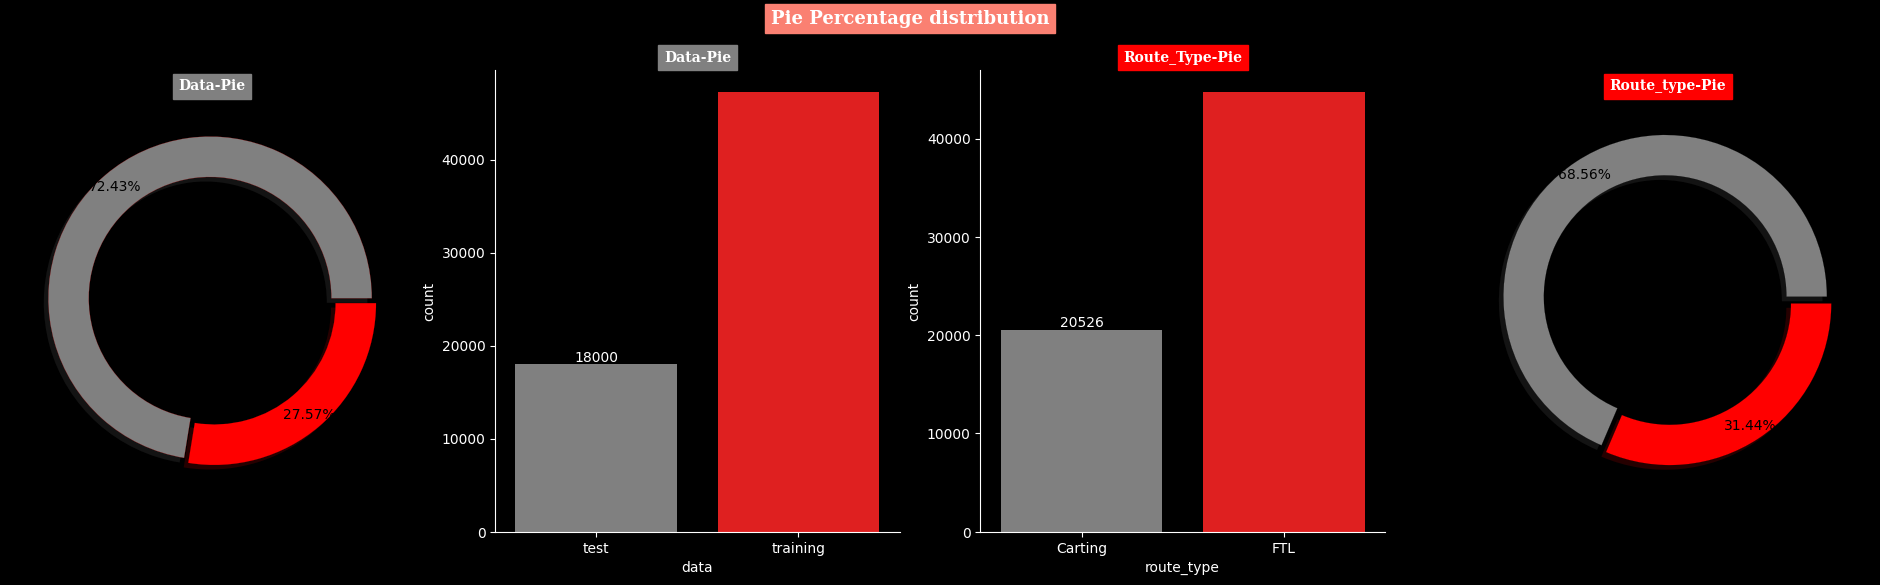

In [75]:
plt.figure(figsize=(24,6))
plt.suptitle('Pie Percentage distribution',fontsize=13,fontfamily='serif',fontweight='bold',backgroundcolor=cp[-1],color='w')

plt.subplot(141)
plt.pie(df['data'].value_counts(), labels=df['data'].value_counts().index, colors=cp,counterclock=True , explode=(0.02,0.02) , autopct='%.2f%%', pctdistance=0.905,
       textprops={'color':'k','fontsize':10} , shadow=True, radius=1,wedgeprops=dict(edgecolor='r',linewidth=0.1,width=0.25))
plt.title('Data-Pie',fontsize=10,fontfamily='serif',fontweight='bold',backgroundcolor=cp[0],color='w')

plt.subplot(142)
a = sns.barplot(x=df['data'].value_counts().index, y=df['data'].value_counts(), palette=cp)
a.bar_label(a.containers[0], label_type='edge',fmt='%d')
plt.title('Data-Pie',fontsize=10,fontfamily='serif',fontweight='bold',backgroundcolor=cp[0],color='w')

plt.subplot(143)
b = sns.barplot(x=df['route_type'].value_counts().index, y=df['route_type'].value_counts(), palette=cp)
b.bar_label(b.containers[0], label_type='edge',fmt='%d')
plt.title('Route_Type-Pie',fontsize=10,fontfamily='serif',fontweight='bold',backgroundcolor=cp[1],color='w')

plt.subplot(144)
plt.pie(df['route_type'].value_counts(), labels=df['route_type'].value_counts().index, colors=cp,counterclock=True , explode=(0.03,0.02) , autopct='%.2f%%', pctdistance=0.905,
       textprops={'color':'k','fontsize':10} , shadow=True, radius=1,wedgeprops=dict(edgecolor='k',linewidth=0.1,width=0.25))
plt.title('Route_type-Pie',fontsize=10,fontfamily='serif',fontweight='bold',backgroundcolor=cp[1],color='w')

sns.despine()
plt.show()

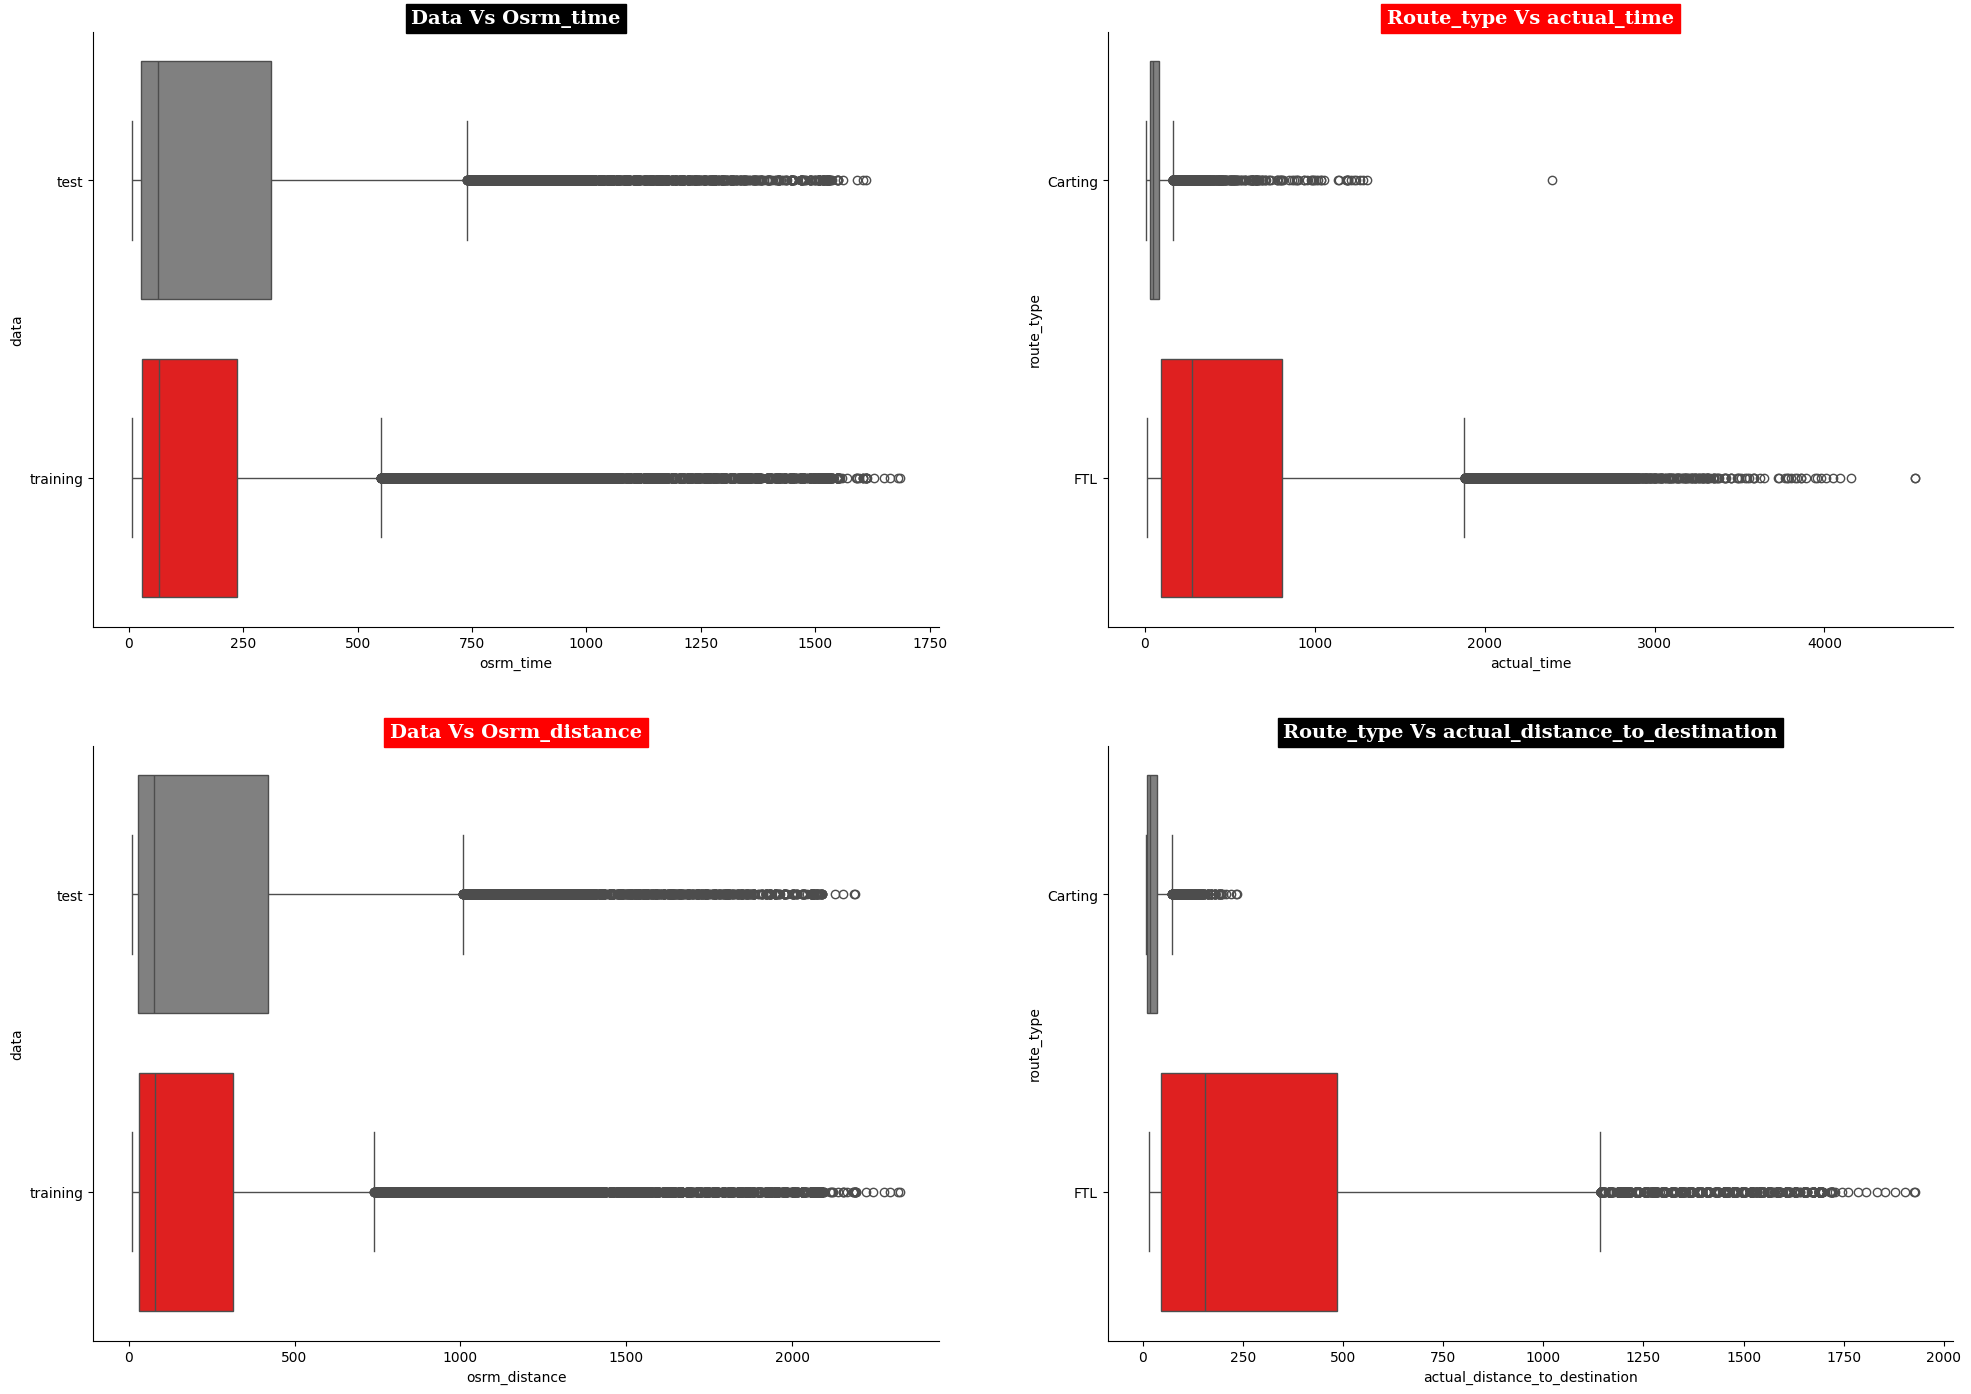

In [79]:
plt.figure(figsize=(24,17))
plt.style.use('default')

plt.subplot(221)
sns.boxplot(data=df,y='data',x='osrm_time',palette=cp)
plt.title('Data Vs Osrm_time',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='k',color='w')

plt.subplot(222)
sns.boxplot(data=df,y='route_type',x='actual_time',palette=cp)
plt.title('Route_type Vs actual_time',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='r',color='w')

plt.subplot(223)
sns.boxplot(data=df,y='data',x='osrm_distance',palette=cp)
plt.title('Data Vs Osrm_distance',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='r',color='w')

plt.subplot(224)
sns.boxplot(data=df,y='route_type',x='actual_distance_to_destination',palette=cp)
plt.title('Route_type Vs actual_distance_to_destination',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='k',color='w')
sns.despine()
plt.show()

##Observations:
- Both training and test data have the same range of osrm time recorded
- FTL route type has more actual time compared to Carting. This can also be since FTL is used a lot more than carting in the data available to us
- Both training and test data have the same range of osrm distance recorded
- FTL route type has more actual distance compared to Carting. This can also be since FTL is used a lot more than carting in the data available to us

#Merging of rows and aggregation of fields
**Merging of rows and aggregation of fields**

- Since delivery details of one package are divided into several rows (think of it as connecting flights to reach a particular destination). Now think about how we should treat their fields if we combine these rows? What aggregation would make sense if we merge. What would happen to the numeric fields if we merge the rows.

In [80]:
# Grouping by segment
# Creating a unique identifier for each segment of a trip

segment_cols = ['segment_actual_time', 'segment_osrm_distance', 'segment_osrm_time']

df['segment_key'] = df['trip_uuid'] + '+' + df['source_center'] + '+' + df['destination_center']

for col in segment_cols:
    df[col + '_sum'] = df.groupby('segment_key')[col].cumsum()

df[['segment_key', 'segment_actual_time', 'segment_actual_time_sum','segment_osrm_distance', 'segment_osrm_distance_sum','segment_osrm_time', 'segment_osrm_time_sum']]

,segment_key,segment_actual_time,segment_actual_time_sum,segment_osrm_distance,segment_osrm_distance_sum,segment_osrm_time,segment_osrm_time_sum
0,trip-153741093647649320+IND388121AAA+IND388620AAB,14.0,14.0,11.965300,11.965300,11.0,11.0
1,trip-153741093647649320+IND388121AAA+IND388620AAB,10.0,24.0,9.759000,21.724300,9.0,20.0
2,trip-153741093647649320+IND388121AAA+IND388620AAB,16.0,40.0,10.815200,32.539497,7.0,27.0
3,trip-153741093647649320+IND388121AAA+IND388620AAB,21.0,61.0,13.022400,45.561897,12.0,39.0
4,trip-153741093647649320+IND388121AAA+IND388620AAB,6.0,67.0,3.915300,49.477200,5.0,44.0
...,...,...,...,...,...,...,...
65526,trip-153747629742455165+IND305001AAC+IND305901AAA,34.0,34.0,24.233801,24.233801,17.0,17.0
65527,trip-153747629742455165+IND305001AAC+IND305901AAA,28.0,62.0,22.457701,46.691502,18.0,35.0
65528,trip-153747629742455165+IND305001AAC+IND305901AAA,17.0,79.0,9.145200,55.836700,8.0,43.0
65529,trip-153747629742455165+IND305901AAA+IND342602AAC,28.0,28.0,25.058300,25.058300,17.0,17.0


In [81]:
# Aggregating at segment level & Creating a dictionary for aggregation at segment level

segment_dict = {
  'trip_uuid' : 'first',
  'data': 'first',
  'route_type': 'first',
  'trip_creation_time': 'first',
  'source_name': 'first',
  'destination_name': 'last',
  'od_start_time': 'first',
  'od_end_time': 'last',
  'start_scan_to_end_scan': 'first',
  'actual_distance_to_destination': 'last',
  'actual_time': 'last',
  'osrm_time': 'last',
  'osrm_distance': 'last',
  'segment_actual_time' : 'sum',
  'segment_osrm_time' : 'sum',
  'segment_osrm_distance' : 'sum',
  'segment_actual_time_sum': 'last',
  'segment_osrm_time_sum': 'last',
  'segment_osrm_distance_sum': 'last',
}

# Grouping by segment_key and aggregating
segment_agg_data = df.groupby('segment_key').agg(segment_dict).reset_index()
segment_agg_data = segment_agg_data.sort_values(by=['segment_key','od_end_time'])
segment_agg_data

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,trip-153671074033284934+IND395009AAA+IND395023AAD,trip-153671074033284934,training,Carting,2018-09-12 00:05:40.333071,Surat_Central_D_12 (Gujarat),Surat_Central_I_4 (Gujarat),2018-09-12 02:31:39.246238,2018-09-12 05:16:28.581141,164.0,12.264924,128.0,16.0,17.022499,128.0,16.0,17.022499,128.0,16.0,17.022499
1,trip-153671074033284934+IND395023AAD+IND395004AAB,trip-153671074033284934,training,Carting,2018-09-12 00:05:40.333071,Surat_Central_I_4 (Gujarat),Surat_Central_D_3 (Gujarat),2018-09-12 00:05:40.333071,2018-09-12 02:01:41.638015,116.0,13.189923,33.0,13.0,13.913400,33.0,13.0,13.913300,33.0,13.0,13.913300
2,trip-153671079956500691+IND110024AAA+IND110014AAA,trip-153671079956500691,training,Carting,2018-09-12 00:06:39.565253,Delhi_Lajpat_IP (Delhi),Delhi_Bhogal (Delhi),2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999
3,trip-153671110078355292+IND121004AAB+IND121001AAA,trip-153671110078355292,training,Carting,2018-09-12 00:11:40.783923,FBD_Balabhgarh_DPC (Haryana),Faridabad (Haryana),2018-09-12 00:11:40.783923,2018-09-12 00:50:10.814399,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900
4,trip-153671127071609610+IND585104AAA+IND586128AAA,trip-153671127071609610,training,Carting,2018-09-12 00:14:30.716368,Gulbarga_Nehrugnj_I (Karnataka),Sindagi_KalyanNg_D (Karnataka),2018-09-12 00:14:30.716368,2018-09-12 03:21:35.028141,187.0,78.450333,148.0,73.0,92.522400,147.0,78.0,97.721992,147.0,78.0,97.721992
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11820,trip-153861095625827784+IND160102AAD+IND160002AAC,trip-153861095625827784,test,Carting,2018-10-03 23:55:56.258533,Chandigarh_Raiprkln_C (Chandigarh),Chandigarh_Mehmdpur_H (Punjab),2018-10-04 04:56:10.943956,2018-10-04 06:41:25.409035,105.0,31.261599,49.0,34.0,44.563900,49.0,34.0,35.956001,49.0,34.0,35.956001
11821,trip-153861106442901555+IND208006AAA+IND209304AAA,trip-153861106442901555,test,Carting,2018-10-03 23:57:44.429324,Kanpur_GovndNgr_DC (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2018-10-04 02:51:27.075797,2018-10-04 06:59:51.621332,248.0,19.349009,190.0,24.0,30.054501,190.0,36.0,35.436901,190.0,36.0,35.436901
11822,trip-153861106442901555+IND209304AAA+IND208006AAA,trip-153861106442901555,test,Carting,2018-10-03 23:57:44.429324,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_GovndNgr_DC (Uttar Pradesh),2018-10-03 23:57:44.429324,2018-10-04 02:51:27.075797,173.0,19.335831,92.0,24.0,28.849199,91.0,52.0,69.449699,91.0,52.0,69.449699
11823,trip-153861118270144424+IND583119AAA+IND583101AAA,trip-153861118270144424,test,FTL,2018-10-03 23:59:42.701692,Sandur_WrdN1DPP_D (Karnataka),Bellary_Dc (Karnataka),2018-10-04 03:58:40.726547,2018-10-04 08:46:09.166940,287.0,40.546738,233.0,42.0,52.530300,233.0,42.0,52.530300,233.0,42.0,52.530300


##Understanding:
- The rows have been merged based on the unique segment_key, which is a combination of trip_uuid, source_center, and destination_center.

- The aggregated dataset reflects the total values for each segment of the trip.



#Feature engineering

In [82]:
# 1. Calculating time difference between od_start_time and od_end_time
segment_agg_data['od_total_time']=(segment_agg_data['od_end_time'] - segment_agg_data['od_start_time'])
segment_agg_data['od_time_diff_hour'] = (segment_agg_data['od_total_time']).dt.total_seconds()/3600
segment_agg_data

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_total_time,od_time_diff_hour
0,trip-153671074033284934+IND395009AAA+IND395023AAD,trip-153671074033284934,training,Carting,2018-09-12 00:05:40.333071,Surat_Central_D_12 (Gujarat),Surat_Central_I_4 (Gujarat),2018-09-12 02:31:39.246238,2018-09-12 05:16:28.581141,164.0,12.264924,128.0,16.0,17.022499,128.0,16.0,17.022499,128.0,16.0,17.022499,0 days 02:44:49.334903,2.747037
1,trip-153671074033284934+IND395023AAD+IND395004AAB,trip-153671074033284934,training,Carting,2018-09-12 00:05:40.333071,Surat_Central_I_4 (Gujarat),Surat_Central_D_3 (Gujarat),2018-09-12 00:05:40.333071,2018-09-12 02:01:41.638015,116.0,13.189923,33.0,13.0,13.913400,33.0,13.0,13.913300,33.0,13.0,13.913300,0 days 01:56:01.304944,1.933696
2,trip-153671079956500691+IND110024AAA+IND110014AAA,trip-153671079956500691,training,Carting,2018-09-12 00:06:39.565253,Delhi_Lajpat_IP (Delhi),Delhi_Bhogal (Delhi),2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999,0 days 00:49:20.003392,0.822223
3,trip-153671110078355292+IND121004AAB+IND121001AAA,trip-153671110078355292,training,Carting,2018-09-12 00:11:40.783923,FBD_Balabhgarh_DPC (Haryana),Faridabad (Haryana),2018-09-12 00:11:40.783923,2018-09-12 00:50:10.814399,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900,0 days 00:38:30.030476,0.641675
4,trip-153671127071609610+IND585104AAA+IND586128AAA,trip-153671127071609610,training,Carting,2018-09-12 00:14:30.716368,Gulbarga_Nehrugnj_I (Karnataka),Sindagi_KalyanNg_D (Karnataka),2018-09-12 00:14:30.716368,2018-09-12 03:21:35.028141,187.0,78.450333,148.0,73.0,92.522400,147.0,78.0,97.721992,147.0,78.0,97.721992,0 days 03:07:04.311773,3.117864
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11820,trip-153861095625827784+IND160102AAD+IND160002AAC,trip-153861095625827784,test,Carting,2018-10-03 23:55:56.258533,Chandigarh_Raiprkln_C (Chandigarh),Chandigarh_Mehmdpur_H (Punjab),2018-10-04 04:56:10.943956,2018-10-04 06:41:25.409035,105.0,31.261599,49.0,34.0,44.563900,49.0,34.0,35.956001,49.0,34.0,35.956001,0 days 01:45:14.465079,1.754018
11821,trip-153861106442901555+IND208006AAA+IND209304AAA,trip-153861106442901555,test,Carting,2018-10-03 23:57:44.429324,Kanpur_GovndNgr_DC (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2018-10-04 02:51:27.075797,2018-10-04 06:59:51.621332,248.0,19.349009,190.0,24.0,30.054501,190.0,36.0,35.436901,190.0,36.0,35.436901,0 days 04:08:24.545535,4.140152
11822,trip-153861106442901555+IND209304AAA+IND208006AAA,trip-153861106442901555,test,Carting,2018-10-03 23:57:44.429324,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_GovndNgr_DC (Uttar Pradesh),2018-10-03 23:57:44.429324,2018-10-04 02:51:27.075797,173.0,19.335831,92.0,24.0,28.849199,91.0,52.0,69.449699,91.0,52.0,69.449699,0 days 02:53:42.646473,2.895180
11823,trip-153861118270144424+IND583119AAA+IND583101AAA,trip-153861118270144424,test,FTL,2018-10-03 23:59:42.701692,Sandur_WrdN1DPP_D (Karnataka),Bellary_Dc (Karnataka),2018-10-04 03:58:40.726547,2018-10-04 08:46:09.166940,287.0,40.546738,233.0,42.0,52.530300,233.0,42.0,52.530300,233.0,42.0,52.530300,0 days 04:47:28.440393,4.791233


In [83]:
segment_agg_data.sample()

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_total_time,od_time_diff_hour
9453,trip-153816778954903006+IND515801AAA+IND515865AAB,trip-153816778954903006,test,FTL,2018-09-28 20:49:49.549248,Guntakal_Verpatem_D (Andhra Pradesh),Rayadurgam_RailGate_D (Andhra Pradesh),2018-09-29 01:07:32.853084,2018-09-29 05:14:06.045595,246.0,76.076614,189.0,88.0,104.698402,188.0,92.0,91.696701,188.0,92.0,91.696701,0 days 04:06:33.192511,4.10922


In [84]:
# de = segment_agg_data.drop(columns=['source_city','source_state','source_place','destination_place','destination_city','destination_state'])
de = segment_agg_data.copy()

In [85]:
de.sample()

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_total_time,od_time_diff_hour
1216,trip-153688636480084238+IND206001AAA+IND000000ACB,trip-153688636480084238,training,FTL,2018-09-14 00:52:44.801246,Etawah_MhraChng_D (Uttar Pradesh),Gurgaon_Bilaspur_HB (Haryana),2018-09-15 04:16:42.014339,2018-09-15 12:39:24.496754,502.0,266.162292,457.0,235.0,314.033997,451.0,393.0,474.155304,451.0,393.0,474.155304,0 days 08:22:42.482415,8.378467


In [86]:
# using regex pattern to seperate the city,place,state
def extract_info(name):
    pattern = r'^(?P<city>[^\s_]+)_?(?P<place>[^\(\)]*)\s?\((?P<state>[A-Za-z\s&]+)\)$'
    match = re.match(pattern, name)
    if match:
        city = match.group('city').strip()
        place = match.group('place').strip() if match.group('place') else city
        state = match.group('state').strip()
        return city, place, state
    else:
        return None, None, None

In [87]:
de[['source_city', 'source_place', 'source_state']] = de['source_name'].apply(lambda x: pd.Series(extract_info(x)))

In [88]:
de[['destination_city', 'destination_place', 'destination_state']] = de['destination_name'].apply(lambda x: pd.Series(extract_info(x)))


In [89]:
de

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_total_time,od_time_diff_hour,source_city,source_place,source_state,destination_city,destination_place,destination_state
0,trip-153671074033284934+IND395009AAA+IND395023AAD,trip-153671074033284934,training,Carting,2018-09-12 00:05:40.333071,Surat_Central_D_12 (Gujarat),Surat_Central_I_4 (Gujarat),2018-09-12 02:31:39.246238,2018-09-12 05:16:28.581141,164.0,12.264924,128.0,16.0,17.022499,128.0,16.0,17.022499,128.0,16.0,17.022499,0 days 02:44:49.334903,2.747037,Surat,Central_D_12,Gujarat,Surat,Central_I_4,Gujarat
1,trip-153671074033284934+IND395023AAD+IND395004AAB,trip-153671074033284934,training,Carting,2018-09-12 00:05:40.333071,Surat_Central_I_4 (Gujarat),Surat_Central_D_3 (Gujarat),2018-09-12 00:05:40.333071,2018-09-12 02:01:41.638015,116.0,13.189923,33.0,13.0,13.913400,33.0,13.0,13.913300,33.0,13.0,13.913300,0 days 01:56:01.304944,1.933696,Surat,Central_I_4,Gujarat,Surat,Central_D_3,Gujarat
2,trip-153671079956500691+IND110024AAA+IND110014AAA,trip-153671079956500691,training,Carting,2018-09-12 00:06:39.565253,Delhi_Lajpat_IP (Delhi),Delhi_Bhogal (Delhi),2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999,0 days 00:49:20.003392,0.822223,Delhi,Lajpat_IP,Delhi,Delhi,Bhogal,Delhi
3,trip-153671110078355292+IND121004AAB+IND121001AAA,trip-153671110078355292,training,Carting,2018-09-12 00:11:40.783923,FBD_Balabhgarh_DPC (Haryana),Faridabad (Haryana),2018-09-12 00:11:40.783923,2018-09-12 00:50:10.814399,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900,0 days 00:38:30.030476,0.641675,FBD,Balabhgarh_DPC,Haryana,Faridabad,,Haryana
4,trip-153671127071609610+IND585104AAA+IND586128AAA,trip-153671127071609610,training,Carting,2018-09-12 00:14:30.716368,Gulbarga_Nehrugnj_I (Karnataka),Sindagi_KalyanNg_D (Karnataka),2018-09-12 00:14:30.716368,2018-09-12 03:21:35.028141,187.0,78.450333,148.0,73.0,92.522400,147.0,78.0,97.721992,147.0,78.0,97.721992,0 days 03:07:04.311773,3.117864,Gulbarga,Nehrugnj_I,Karnataka,Sindagi,KalyanNg_D,Karnataka
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11820,trip-153861095625827784+IND160102AAD+IND160002AAC,trip-153861095625827784,test,Carting,2018-10-03 23:55:56.258533,Chandigarh_Raiprkln_C (Chandigarh),Chandigarh_Mehmdpur_H (Punjab),2018-10-04 04:56:10.943956,2018-10-04 06:41:25.409035,105.0,31.261599,49.0,34.0,44.563900,49.0,34.0,35.956001,49.0,34.0,35.956001,0 days 01:45:14.465079,1.754018,Chandigarh,Raiprkln_C,Chandigarh,Chandigarh,Mehmdpur_H,Punjab
11821,trip-153861106442901555+IND208006AAA+IND209304AAA,trip-153861106442901555,test,Carting,2018-10-03 23:57:44.429324,Kanpur_GovndNgr_DC (Uttar Pradesh),Kanpur_Central_H_6 (Uttar Pradesh),2018-10-04 02:51:27.075797,2018-10-04 06:59:51.621332,248.0,19.349009,190.0,24.0,30.054501,190.0,36.0,35.436901,190.0,36.0,35.436901,0 days 04:08:24.545535,4.140152,Kanpur,GovndNgr_DC,Uttar Pradesh,Kanpur,Central_H_6,Uttar Pradesh
11822,trip-153861106442901555+IND209304AAA+IND208006AAA,trip-153861106442901555,test,Carting,2018-10-03 23:57:44.429324,Kanpur_Central_H_6 (Uttar Pradesh),Kanpur_GovndNgr_DC (Uttar Pradesh),2018-10-03 23:57:44.429324,2018-10-04 02:51:27.075797,173.0,19.335831,92.0,24.0,28.849199,91.0,52.0,69.449699,91.0,52.0,69.449699,0 days 02:53:42.646473,2.895180,Kanpur,Central_H_6,Uttar Pradesh,Kanpur,GovndNgr_DC,Uttar Pradesh
11823,trip-153861118270144424+IND583119AAA+IND583101AAA,trip-153861118270144424,test,FTL,2018-10-03 23:59:42.701692,Sandur_WrdN1DPP_D (Karnataka),Bellary_Dc (Karnataka),2018-10-04 03:58:40.726547,2018-10-04 08:46:09.166940,287.0,40.546738,233.0,42.0

In [91]:
de[(de['source_place']=='') | (de['destination_place']=='')]

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_total_time,od_time_diff_hour,source_city,source_place,source_state,destination_city,destination_place,destination_state
3,trip-153671110078355292+IND121004AAB+IND121001AAA,trip-153671110078355292,training,Carting,2018-09-12 00:11:40.783923,FBD_Balabhgarh_DPC (Haryana),Faridabad (Haryana),2018-09-12 00:11:40.783923,2018-09-12 00:50:10.814399,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900,0 days 00:38:30.030476,0.641675,FBD,Balabhgarh_DPC,Haryana,Faridabad,,Haryana
23,trip-153671320807895983+IND121004AAB+IND121102AAA,trip-153671320807895983,training,Carting,2018-09-12 00:46:48.079257,FBD_Balabhgarh_DPC (Haryana),Palwal (Haryana),2018-09-12 00:46:48.079257,2018-09-12 01:53:32.471405,66.0,37.859165,45.0,28.0,39.724499,44.0,27.0,39.724400,44.0,27.0,39.724400,0 days 01:06:44.392148,1.112331,FBD,Balabhgarh_DPC,Haryana,Palwal,,Haryana
24,trip-153671320807895983+IND121102AAA+IND121004AAB,trip-153671320807895983,training,Carting,2018-09-12 00:46:48.079257,Palwal (Haryana),FBD_Balabhgarh_DPC (Haryana),2018-09-12 01:53:32.471405,2018-09-12 05:07:14.232558,193.0,38.372337,100.0,29.0,40.254799,98.0,28.0,40.425098,98.0,28.0,40.425098,0 days 03:13:41.761153,3.228267,Palwal,,Haryana,FBD,Balabhgarh_DPC,Haryana
107,trip-153672034455004313+IND583201AAA+IND583227AAA,trip-153672034455004313,training,Carting,2018-09-12 02:45:44.550269,Hospet (Karnataka),Gangavathi_PhrmPlza_D (Karnataka),2018-09-12 02:45:44.550269,2018-09-12 04:10:21.531202,84.0,21.881475,71.0,30.0,27.321199,71.0,29.0,32.072498,71.0,29.0,32.072498,0 days 01:24:36.980933,1.410272,Hospet,,Karnataka,Gangavathi,PhrmPlza_D,Karnataka
109,trip-153672034455004313+IND583231AAA+IND583201AAA,trip-153672034455004313,training,Carting,2018-09-12 02:45:44.550269,Koppal_Banikatt_D (Karnataka),Hospet (Karnataka),2018-09-12 05:44:07.793902,2018-09-12 07:03:38.215329,79.0,26.152575,73.0,23.0,31.061100,71.0,22.0,31.061100,71.0,22.0,31.061100,0 days 01:19:30.421427,1.325117,Koppal,Banikatt_D,Karnataka,Hospet,,Karnataka
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11499,trip-153854990058036233+IND121004AAB+IND121102AAA,trip-153854990058036233,test,Carting,2018-10-03 06:58:20.580610,FBD_Balabhgarh_DPC (Haryana),Palwal (Haryana),2018-10-03 06:58:20.580610,2018-10-03 08:37:27.080075,99.0,37.600487,60.0,28.0,39.744598,59.0,28.0,39.844501,59.0,28.0,39.844501,0 days 01:39:06.499465,1.651805,FBD,Balabhgarh_DPC,Haryana,Palwal,,Haryana
11523,trip-153855685628554406+IND636016AAA+IND637211AAA,trip-153855685628554406,test,Carting,2018-10-03 08:54:16.285786,Salem (Tamil Nadu),Tirchngode_Mhdhvpur_D (Tamil Nadu),2018-10-03 10:09:13.079448,2018-10-03 11:57:10.409033,107.0,40.509426,72.0,46.0,53.395302,70.0,54.0,47.570900,70.0,54.0,47.570900,0 days 01:47:57.329585,1.799258,Salem,,Tamil Nadu,Tirchngode,Mhdhvpur_D,Tamil Nadu
11614,trip-153858917190862399+IND244901AAB+IND243002AAA,trip-153858917190862399,test,FTL,2018-10-03 17:52:51.908885,Rampur_RoshnBgh_I (Uttar Pradesh),Bareilly (Uttar Pradesh),2018-10-03 17:52:51.908885,2018-10-04 02:29:05.322097,516.0,56.260544,126.0,45.0,60.087700,126.0,44.0,60.087700,126.0,44.0,60.087700,0 days 08:36:13.413212,8.603726,Rampur,RoshnBgh_I,Uttar Pradesh,Bareilly,,Uttar Pradesh
11702,trip-153860096739851507+IND132103AAB+IND132001AAA,trip-153860096739851507,test,FTL,2018-10-03 21:09:27.398767,Panipat_PC (Haryana),Karnal (Haryana),2018-10-04 03:07:19.274811,2018-10-04 04:05:36.482809,58.0,36.091377,46.0,33.0,41.764000,45.0,41.0,50.858700,45.0,41.0,50.858700,0 days 00:58:17.207998,0.971447,Panipat,PC,Haryana,Karnal,,Haryana


In [92]:
de.loc[de['source_place']=='','source_place']=de['source_city']
de.loc[de['destination_place']=='','destination_place']=de['destination_city']

In [93]:
de[de.source_place.isna()]

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_total_time,od_time_diff_hour,source_city,source_place,source_state,destination_city,destination_place,destination_state


In [94]:
de.isna().sum()

,0
segment_key,0
trip_uuid,0
data,0
route_type,0
trip_creation_time,0
source_name,0
destination_name,0
od_start_time,0
od_end_time,0
start_scan_to_end_scan,0


In [95]:
de.loc[de.source_city=='Bangalore','source_city']='Bengaluru'
de.loc[de.destination_city=='Bangalore','destination_city']='Bengaluru'

In [96]:
np.set_printoptions(threshold=np.inf)

In [97]:
de['source_city'].unique()

array(['Surat', 'Delhi', 'FBD', 'Gulbarga', 'Aland', 'Sindagi', 'Indi',
       'Narsinghpur', 'Gadarwara', 'Sonari', 'Hyderabad', 'Medchal',
       'Dindigul', 'Kodaikanal', 'Batlagundu', 'Palani', 'Oddnchtram',
       'Jalandhar', 'Nakodar', 'Kapurthala', 'Faridabad', 'Palwal',
       'Bhiwandi', 'Jaipur', 'Bantwal', 'Kadaba', 'Sullia', 'Kadi',
       'Mehsana', 'Chennai', 'Durgapur', 'Bankura', 'Barjora', 'Vapi',
       'Jamjodhpur', 'Porbandar', 'Junagadh', 'Jetpur', 'Dhoraji',
       'Khammam', 'Nalgonda', 'Miryalguda', 'Suryapet', 'Choutuppal',
       'Vijayawada', 'Vadnagar', 'Palanpur', 'Deesa', 'Bengaluru',
       'Talala', 'Veraval', 'Una', 'Kodinar', 'Patan', 'Bhabhar', 'Vizag',
       'Rajamundry', 'Goa', 'Sawantwadi', 'Kankavali', 'Bhopal', 'Kanpur',
       'Gurgaon', 'Jamshedpur', 'Pondicherry', 'Cuddalore', 'Chidambaram',
       'Sirkazhi', 'Karaikal', 'Thiruvarur', 'Nagapttinm', 'MAA',
       'Nadiad', 'Umreth', 'Anand', 'Villupuram', 'Virudhchlm',
       'Pennadam', 'Ch

In [98]:
de['source_place'].unique()

array(['Central_D_12', 'Central_I_4', 'Lajpat_IP', 'Balabhgarh_DPC',
       'Nehrugnj_I', 'RazaviRd_D', 'KalyanNg_D', 'SindgiRD_D',
       'KndliDPP_D', 'MPward_D', 'Central_DPP_1', 'North_D_2',
       'MROoffce_D', 'Central_D_1', 'Athithnr_DC', 'RTOofice_D',
       'RjndraRd_D', 'Palani_D', 'DC', 'DPC', 'ChowkDPP_D', 'Mthurard_L',
       'Palwal', 'Mankoli_HB', 'Hub', 'Gateway_HB', 'Trmltmpl_D',
       'AnugrDPP_D', 'Srirampt_D', 'KaranNGR_D', 'Panchot_IP',
       'Chrompet_L', 'Central_I_1', 'KeranDPP_D', 'IndEstat_I', 'Court_D',
       'JmnvadRd_DC', 'Shamshbd_H', 'NSTRoad_I', 'HydRoad_DC',
       'Ragvendr_D', 'Krishna_D', 'Nagaram_D', 'Rynapadu_H', 'BsstdDPP_D',
       'HawaiPlr_DC', 'Bomsndra_HB', 'SsnRdDPP_D', 'Mamlatdr_DC',
       'NCplxDPP_D', 'Central_D_2', 'TirupDPP_D', 'Gajuwaka_L',
       'AtoNgrRd_I', 'LaxmiNgr_D', 'NrdawDPP_D', 'Old City', 'Airport_H',
       'Central_H_6', 'Bilaspur_HB', 'Central_I_3', 'Vasanthm_I',
       'KtsiGrsm_D', 'ARBNorth_DC', 'Pngktgudi_D', 'Th

In [99]:
de['source_state'].unique()

array(['Gujarat', 'Delhi', 'Haryana', 'Karnataka', 'Madhya Pradesh',
       'Assam', 'Telangana', 'Tamil Nadu', 'Punjab', 'Maharashtra',
       'Rajasthan', 'West Bengal', 'Andhra Pradesh', 'Goa',
       'Uttar Pradesh', 'Jharkhand', 'Pondicherry', 'Orissa',
       'Himachal Pradesh', 'Meghalaya', 'Arunachal Pradesh', 'Bihar',
       'Uttarakhand', 'Kerala', 'Chandigarh', 'Chhattisgarh',
       'Jammu & Kashmir', 'Dadra and Nagar Haveli', 'Tripura', 'Mizoram',
       'Nagaland'], dtype=object)

In [103]:
de['source_state'].value_counts().to_frame().T.style.background_gradient(cmap='Reds')

source_state,Maharashtra,Karnataka,Haryana,Tamil Nadu,Uttar Pradesh,Telangana,Andhra Pradesh,Gujarat,West Bengal,Rajasthan,Punjab,Bihar,Delhi,Kerala,Madhya Pradesh,Assam,Uttarakhand,Jharkhand,Orissa,Himachal Pradesh,Chandigarh,Goa,Jammu & Kashmir,Chhattisgarh,Arunachal Pradesh,Pondicherry,Meghalaya,Dadra and Nagar Haveli,Mizoram,Nagaland,Tripura
count,1612,1586,942,895,853,646,644,621,580,534,469,454,399,358,337,186,173,126,112,98,58,36,27,21,20,18,6,6,4,3,1


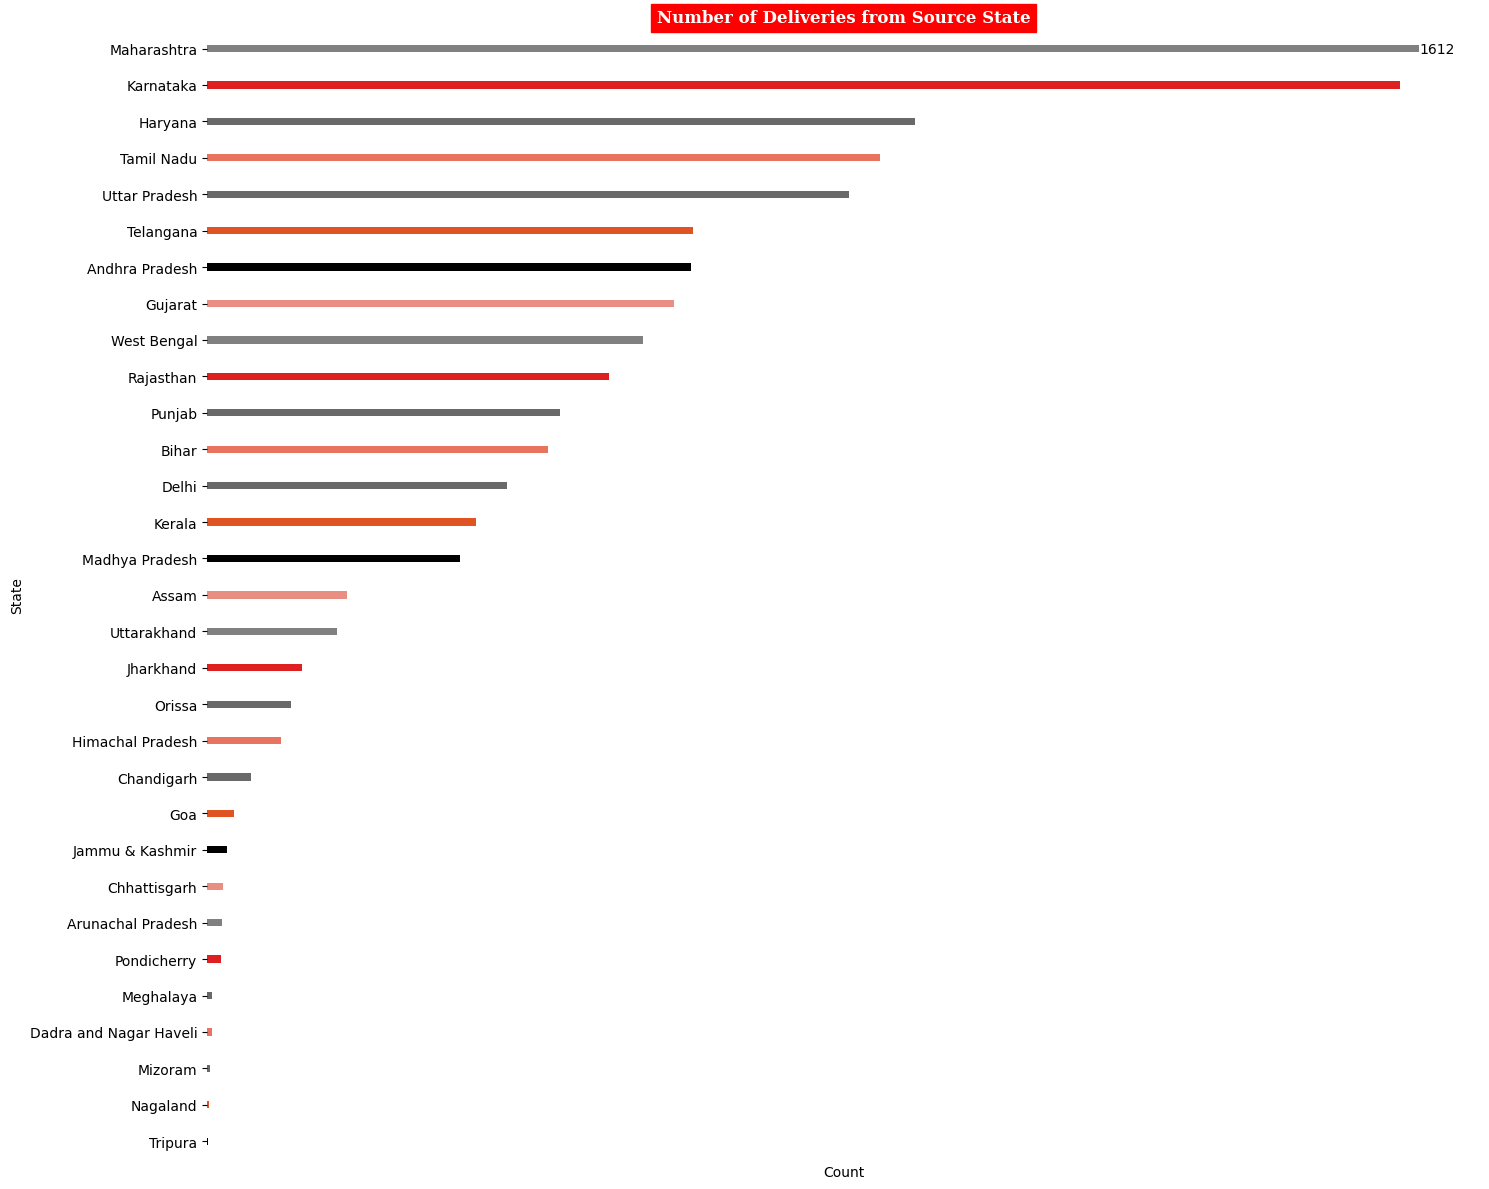

In [105]:
state_counts = de['source_state'].value_counts().to_frame().reset_index()
state_counts.columns = ['State', 'Count']

plt.figure(figsize=(15,12))
a = sns.barplot(y='State', x='Count', data=state_counts,palette=cp,width=0.2)
a.bar_label(a.containers[0], label_type='edge')
plt.xticks([])
plt.ylabel('State')
plt.xlabel('Count')
plt.title('Number of Deliveries from Source State',fontsize=12,fontfamily='serif',fontweight='bold',backgroundcolor='r',color='w')
plt.tight_layout()
sns.despine(bottom=True,left=True)
plt.show()

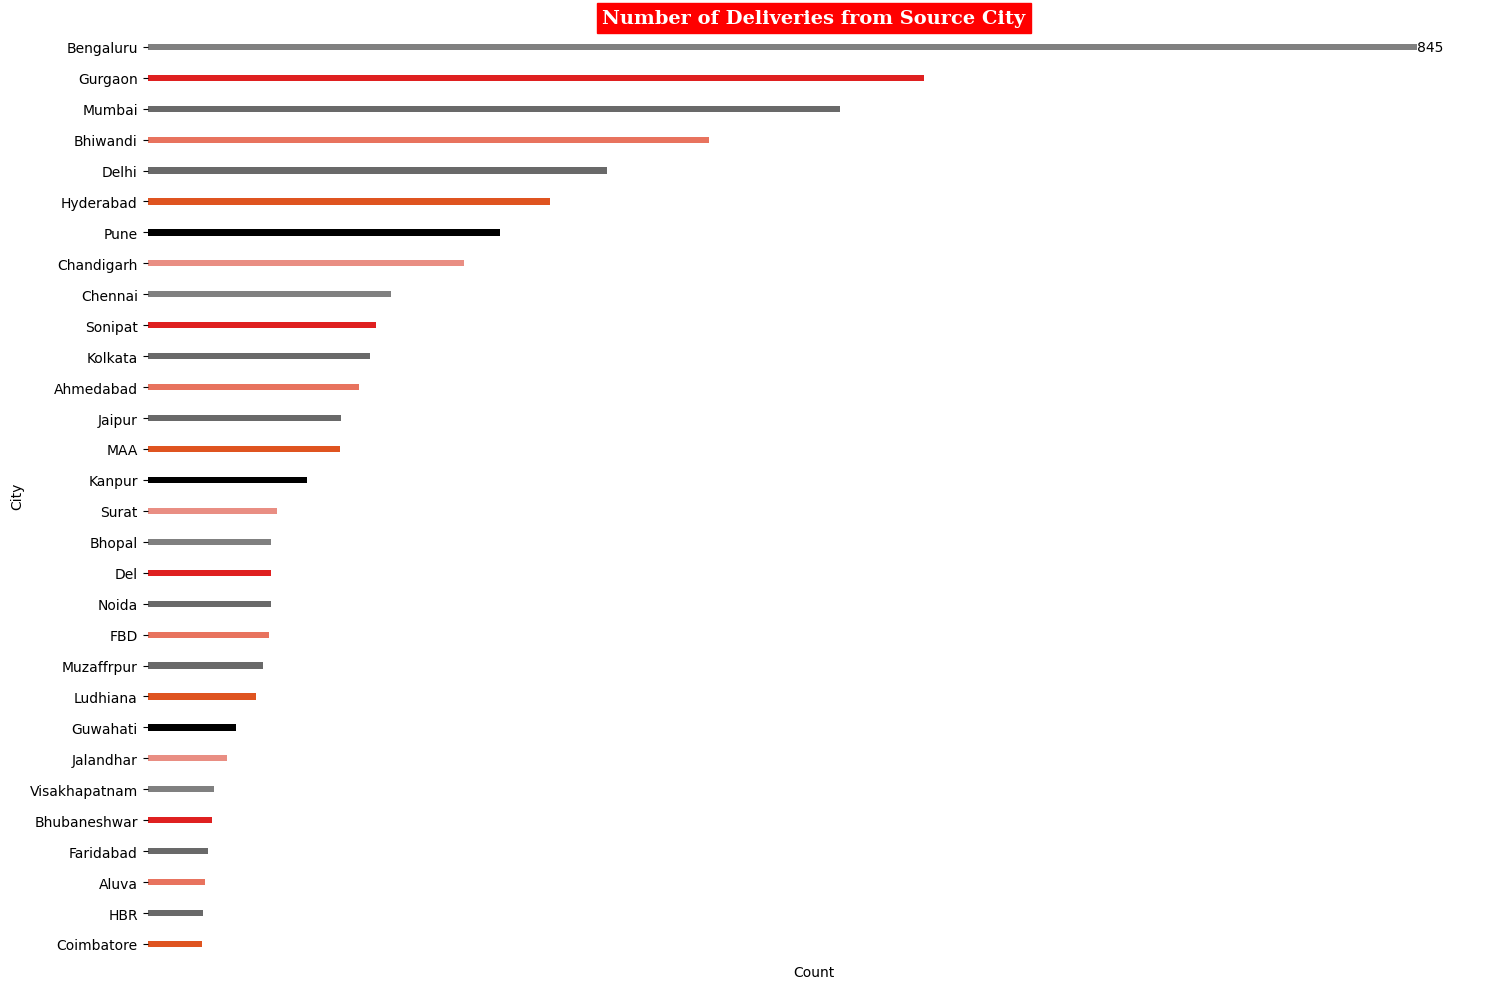

In [106]:
city_counts = de['source_city'].value_counts().to_frame().reset_index()[:30]
city_counts.columns = ['City', 'Count']

plt.figure(figsize=(15,10))
a = sns.barplot(y='City', x='Count', data=city_counts,palette=cp,width=0.2)
a.bar_label(a.containers[0], label_type='edge')
plt.xticks([])
plt.ylabel('City')
plt.xlabel('Count')
plt.title('Number of Deliveries from Source City',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='r',color='w')
plt.tight_layout()
sns.despine(bottom=True,left=True)
plt.show()

##Insights:
**Source State contributors**

- Maharashtra, Karnataka ,Tamil Nadu, Haryana, and Uttar Pradesh are the top contributors where maximum bookings are recorded in this month indicating significant engagement.

**Source City contributors**

- Cities like Bengaluru, Gurgaon, Mumbai, Bhiwandi, Delhi, Hyderabad where the major no.of booking are recorded.

In [107]:
de.describe().T

,count,mean,min,25%,50%,75%,max,std
trip_creation_time,11825,2018-09-22 12:11:40.598120960,2018-09-12 00:05:40.333071,2018-09-17 02:34:17.063773952,2018-09-22 01:57:30.163540992,2018-09-27 19:08:42.276193024,2018-10-03 23:59:42.701692,NaN
od_start_time,11825,2018-09-22 16:02:15.316135680,2018-09-12 00:05:40.333071,2018-09-17 06:15:35.408922112,2018-09-22 05:39:49.930206976,2018-09-27 22:10:21.209164032,2018-10-06 00:08:33.866586,NaN
od_end_time,11825,2018-09-22 21:00:51.149106688,2018-09-12 00:50:10.814399,2018-09-17 11:15:54.588134912,2018-09-22 10:24:51.003270912,2018-09-28 02:15:20.030569984,2018-10-06 19:46:59.723686,NaN
start_scan_to_end_scan,11825.0,297.975739,20.0,90.0,153.0,311.0,4535.0,433.11499
actual_distance_to_destination,11825.0,92.792709,9.003577,21.677084,35.242565,65.73407,1927.447754,206.866745
actual_time,11825.0,200.696823,9.0,51.0,84.0,171.0,4532.0,379.023407
osrm_time,11825.0,91.038986,6.0,25.0,39.0,73.0,1686.0,182.983994
osrm_distance,11825.0,115.265846,9.0729,27.7304,43.738899,86.1399,2326.199219,251.00206
segment_actual_time,11825.0,198.864441,9.0,50.0,84.0,169.0,4504.0,375.508667
segment_osrm_time,11825.0,101.919067,6.0,25.0,42.0,81.0,1938.0,212.381927


In [108]:
de.describe(include='object').T

,count,unique,top,freq
segment_key,11825,11825,trip-153861118270144424+IND583201AAA+IND583119AAA,1
trip_uuid,11825,6681,trip-153710494321650505,8
source_name,11825,1371,Gurgaon_Bilaspur_HB (Haryana),485
destination_name,11825,1330,Gurgaon_Bilaspur_HB (Haryana),452
source_city,11825,1150,Bengaluru,845
source_place,11825,1145,Bilaspur_HB,485
source_state,11825,31,Maharashtra,1612
destination_city,11825,1144,Bengaluru,799
destination_place,11825,1109,Bilaspur_HB,452
destination_state,11825,32,Karnataka,1595


In [109]:
de['destination_city'].unique()

array(['Surat', 'Delhi', 'Faridabad', 'Sindagi', 'Gulbarga', 'Indi',
       'Aland', 'Gadarwara', 'Bareli', 'Sivasagar', 'Medchal',
       'Hyderabad', 'Oddnchtram', 'Batlagundu', 'Vadipatti', 'Kodaikanal',
       'Palani', 'Nakodar', 'Kapurthala', 'Jalandhar', 'Gurgaon',
       'Palwal', 'FBD', 'Chandigarh', 'Puttur', 'Bengaluru', 'Kadaba',
       'Ahmedabad', 'Kadi', 'MAA', 'Barjora', 'Bishnupur', 'Bankura',
       'Silvassa', 'Junagadh', 'Bhanvad', 'Porbandar', 'Dhoraji',
       'Upleta', 'Jetpur', 'Choutuppal', 'Suryapet', 'Vijayawada',
       'Nalgonda', 'Miryalguda', 'Khammam', 'Vadnagar', 'Palanpur',
       'Deesa', 'Mehsana', 'Kodinar', 'Talala', 'Una', 'Unjha', 'Bhabhar',
       'Radhanpur', 'Rajamundry', 'Visakhapatnam', 'Sawantwadi',
       'Kankavali', 'Pune', 'Bhopal', 'Kanpur', 'Allahabad', 'Sonipat',
       'Sasaram', 'Ranchi', 'Cuddalore', 'Chidambaram', 'Sirkazhi',
       'Karaikal', 'Nagapttinm', 'Pondicherry', 'Thiruvarur', 'GZB',
       'Chennai', 'Noida', 'Umreth',

In [110]:
de['destination_place'].unique()

array(['Central_I_4', 'Central_D_3', 'Bhogal', 'Faridabad', 'KalyanNg_D',
       'Nehrugnj_I', 'SindgiRD_D', 'RazaviRd_D', 'MPward_D', 'SourvDPP_D',
       'Babupaty_D', 'MROoffce_D', 'Alwal_I', 'Palani_D', 'RTOofice_D',
       'lalaNGR_D', 'Athithnr_DC', 'RjndraRd_D', 'ChowkDPP_D', 'DC',
       'DPC', 'Bilaspur_HB', 'Palwal', 'Balabhgarh_DPC', 'Mehmdpur_H',
       'Darbe_DC', 'Nelmngla_H', 'AnugrDPP_D', 'East_H_1', 'KaranNGR_D',
       'Poonamallee_HB', 'Central_DPP_1', 'StnRdDPP_D', 'BhowmDPP_D',
       'Samrvrni_D', 'Mainroad_D', 'JmnvadRd_DC', 'AdrshSt_DC',
       'Nagaram_D', 'Krishna_D', 'Shamshbd_H', 'Rynapadu_H', 'HydRoad_DC',
       'Ragvendr_D', 'NSTRoad_I', 'BsstdDPP_D', 'HawaiPlr_DC',
       'Panchot_IP', 'KGAirprt_HB', 'keshod_DC', 'NCplxDPP_D',
       'SsnRdDPP_D', 'Mamlatdr_DC', 'TirupDPP_D', 'Santalpr_D',
       'AtoNgrRd_I', 'Gajuwaka_IP', 'LaxmiNgr_D', 'NrdawDPP_D',
       'Tathawde_H', 'Trnsport_H', 'Central_H_6', 'Central_H_1',
       'Kundli_H', 'Central_I_2', 'Hub

In [111]:
de['destination_state'].unique()

array(['Gujarat', 'Delhi', 'Haryana', 'Karnataka', 'Madhya Pradesh',
       'Assam', 'Telangana', 'Tamil Nadu', 'Punjab', 'West Bengal',
       'Dadra and Nagar Haveli', 'Andhra Pradesh', 'Maharashtra',
       'Uttar Pradesh', 'Bihar', 'Jharkhand', 'Pondicherry', 'Orissa',
       'Goa', 'Chandigarh', 'Himachal Pradesh', 'Rajasthan',
       'Arunachal Pradesh', 'Uttarakhand', 'Kerala', 'Chhattisgarh',
       'Jammu & Kashmir', 'Nagaland', 'Meghalaya', 'Tripura', 'Mizoram',
       'Daman & Diu'], dtype=object)

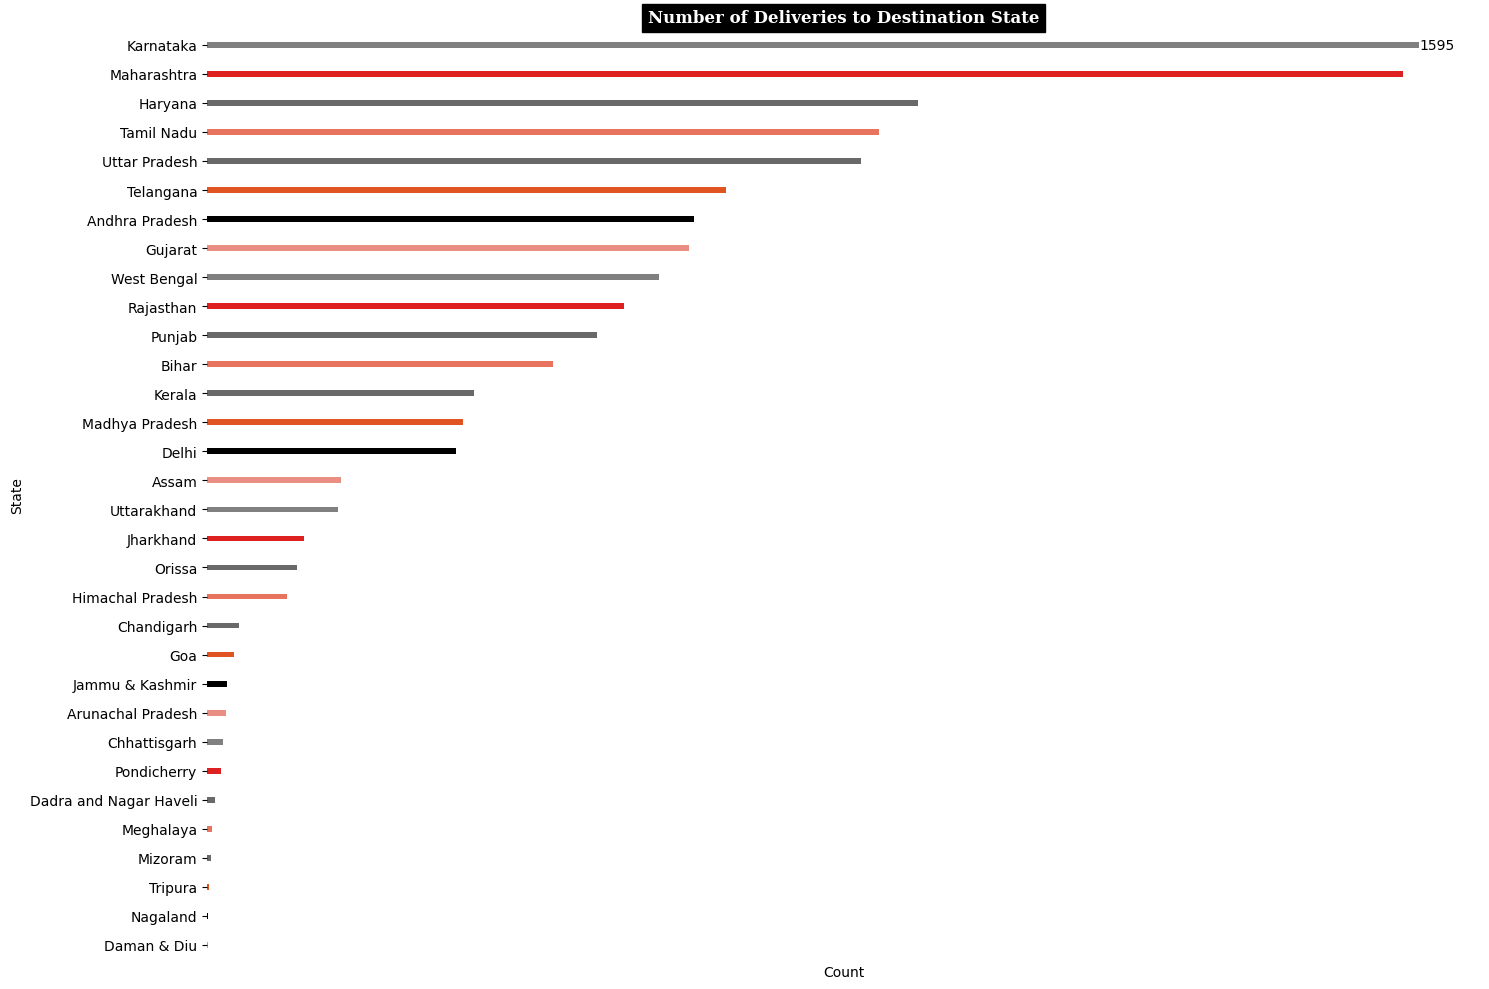

In [112]:
state_counts = de['destination_state'].value_counts().to_frame().reset_index()
state_counts.columns = ['State', 'Count']

plt.figure(figsize=(15,10))
a = sns.barplot(y='State', x='Count', data=state_counts,palette=cp,width=0.2)
a.bar_label(a.containers[0], label_type='edge')
plt.xticks([])
plt.ylabel('State')
plt.xlabel('Count')
plt.title('Number of Deliveries to Destination State',fontsize=12,fontfamily='serif',fontweight='bold',backgroundcolor='k',color='w')
plt.tight_layout()
sns.despine(bottom=True,left=True)
plt.show()

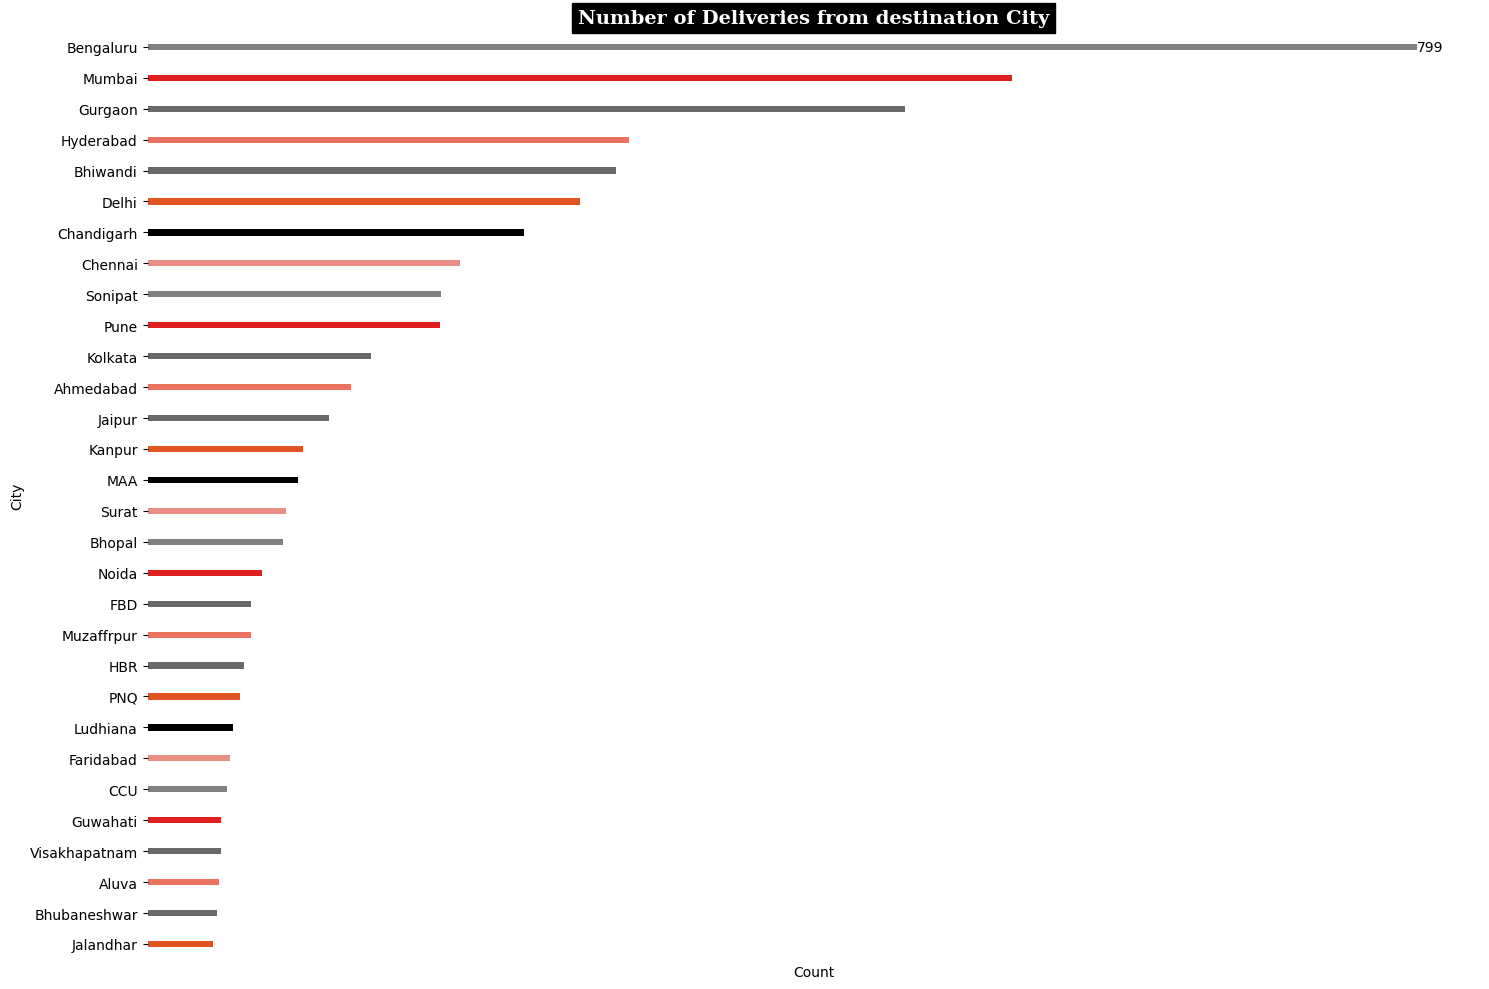

In [113]:
city_counts = de['destination_city'].value_counts().to_frame().reset_index()[:30]
city_counts.columns = ['City', 'Count']

plt.figure(figsize=(15,10))
a = sns.barplot(y='City', x='Count', data=city_counts,palette=cp,width=0.2)
a.bar_label(a.containers[0], label_type='edge')
plt.xticks([])
plt.ylabel('City')
plt.xlabel('Count')
plt.title('Number of Deliveries from destination City',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='k',color='w')
plt.tight_layout()
sns.despine(bottom=True,left=True)
plt.show()

##Insights:
**Destination State**

- States like Karnataka, Maharashtra, Tamil Nadu, Haryana, and Uttar Pradesh where maximum packages are received in this month indicating significant engagement.

**Destination City**

- Cities like Bengaluru, Mumbai, Gurgaon, Bhiwandi, Hyderabad, Delhi where the major no.of booking are received.

In [114]:
np.set_printoptions(threshold=np.inf)

In [115]:
de['corridor'] = de['source_name'] +' <---> '+ de['destination_name']
de['corridor'].value_counts()

,count
corridor,
Bangalore_Nelmngla_H (Karnataka) <---> Bengaluru_Bomsndra_HB (Karnataka),64
Pune_Tathawde_H (Maharashtra) <---> Bhiwandi_Mankoli_HB (Maharashtra),62
Bangalore_Nelmngla_H (Karnataka) <---> Bengaluru_KGAirprt_HB (Karnataka),62
Bhiwandi_Mankoli_HB (Maharashtra) <---> Mumbai Hub (Maharashtra),54
Delhi_Gateway_HB (Delhi) <---> Gurgaon_Bilaspur_HB (Haryana),50
...,...
Giridih_Shivalya_D (Jharkhand) <---> Madhupur_Sitarmrd_D (Jharkhand),1
Anandnagar_LohiaDPP_D (Uttar Pradesh) <---> Gorakhpur_Matriprm_IP (Uttar Pradesh),1
Gorakhpur_Matriprm_IP (Uttar Pradesh) <---> Nichlaul_Wardno13_D (Uttar Pradesh),1


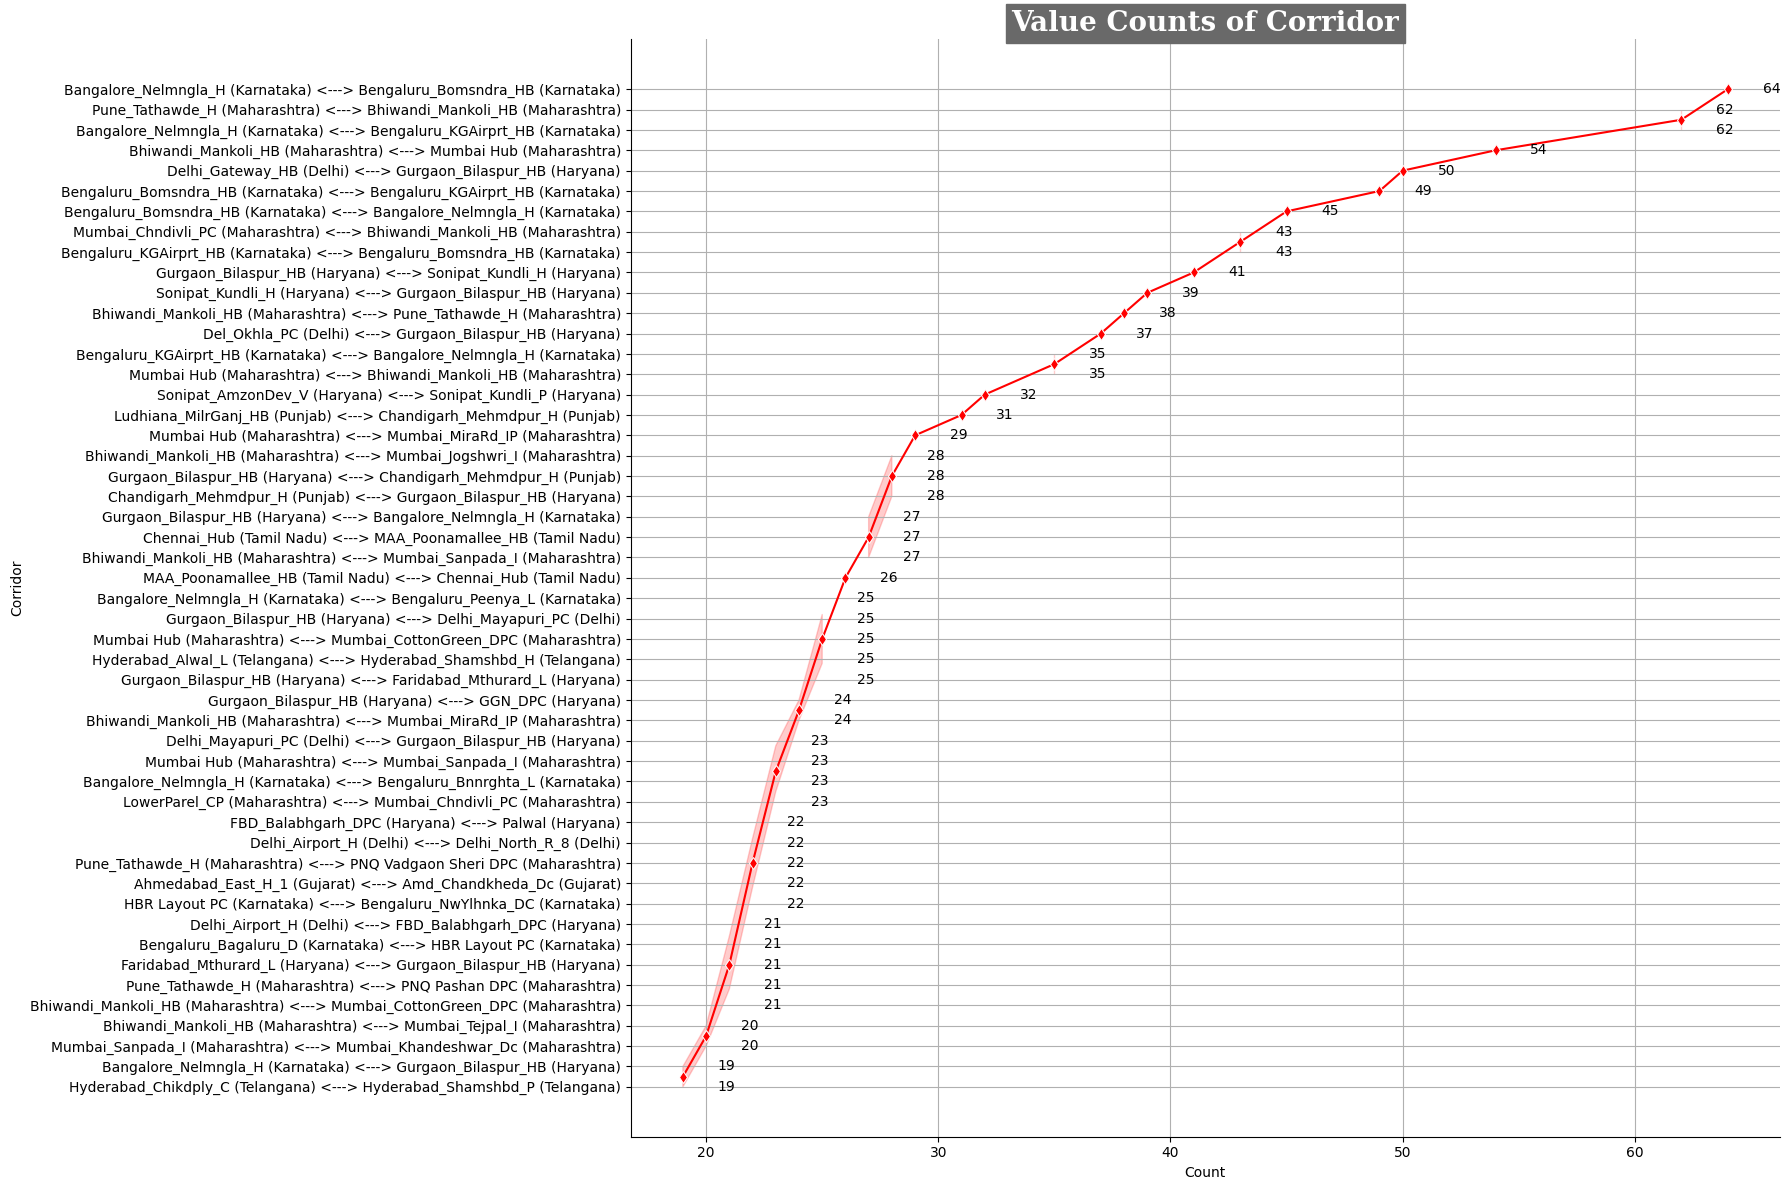

In [116]:
corridor_counts = de['corridor'].value_counts()[:50]

plt.figure(figsize=(18,12))
#corridor_counts.plot(kind='line', marker='d', color='r')
sns.lineplot(y=corridor_counts.index, x=corridor_counts.values, marker='d', color='r')
plt.title('Value Counts of Corridor',fontsize=20,fontfamily='serif',fontweight='bold',backgroundcolor='dimgrey',color='w')
plt.ylabel('Corridor')
plt.xlabel('Count')
plt.tight_layout()
sns.despine()
plt.grid(True)

for i, count in enumerate(corridor_counts.values):
    plt.text(count+1.5, corridor_counts.index[i], str(count), ha='left', va='center')

plt.show()

##Insights:
- The route between Bangalore_Nelamangala_H to Bengaluru_KGAirport_HB, Bengaluru_Bomsndra_HB sees the highest package volume, with 151 and 127 packages sent respectively.
- Bengaluru_Bommasandra_HB to Bengaluru_KGAirport_HB is also popular, with 121 packages sent.
- Bengaluru_KGAirport_HB to Bangalore_Nelamangala_H has moderate activity, with 108 packages sent.
- The data indicates Bengaluru's importance as a transportation hub Corridor within Karnataka, handling significant package traffic.

In [117]:
de['state_corridor'] = de['source_state']+'--'+de['source_city'] +' <---> '+ de['destination_state']+'--'+de['destination_city']
de['state_corridor'].value_counts()

,count
state_corridor,
Karnataka--Bengaluru <---> Karnataka--Bengaluru,609
Maharashtra--Mumbai <---> Maharashtra--Mumbai,272
Maharashtra--Bhiwandi <---> Maharashtra--Mumbai,224
Maharashtra--Mumbai <---> Maharashtra--Bhiwandi,158
Telangana--Hyderabad <---> Telangana--Hyderabad,153
...,...
Orissa--Balasore <---> Orissa--Basta,1
Tamil Nadu--Uthangarai <---> Tamil Nadu--Ambur,1
West Bengal--Bankura <---> West Bengal--Durgapur,1


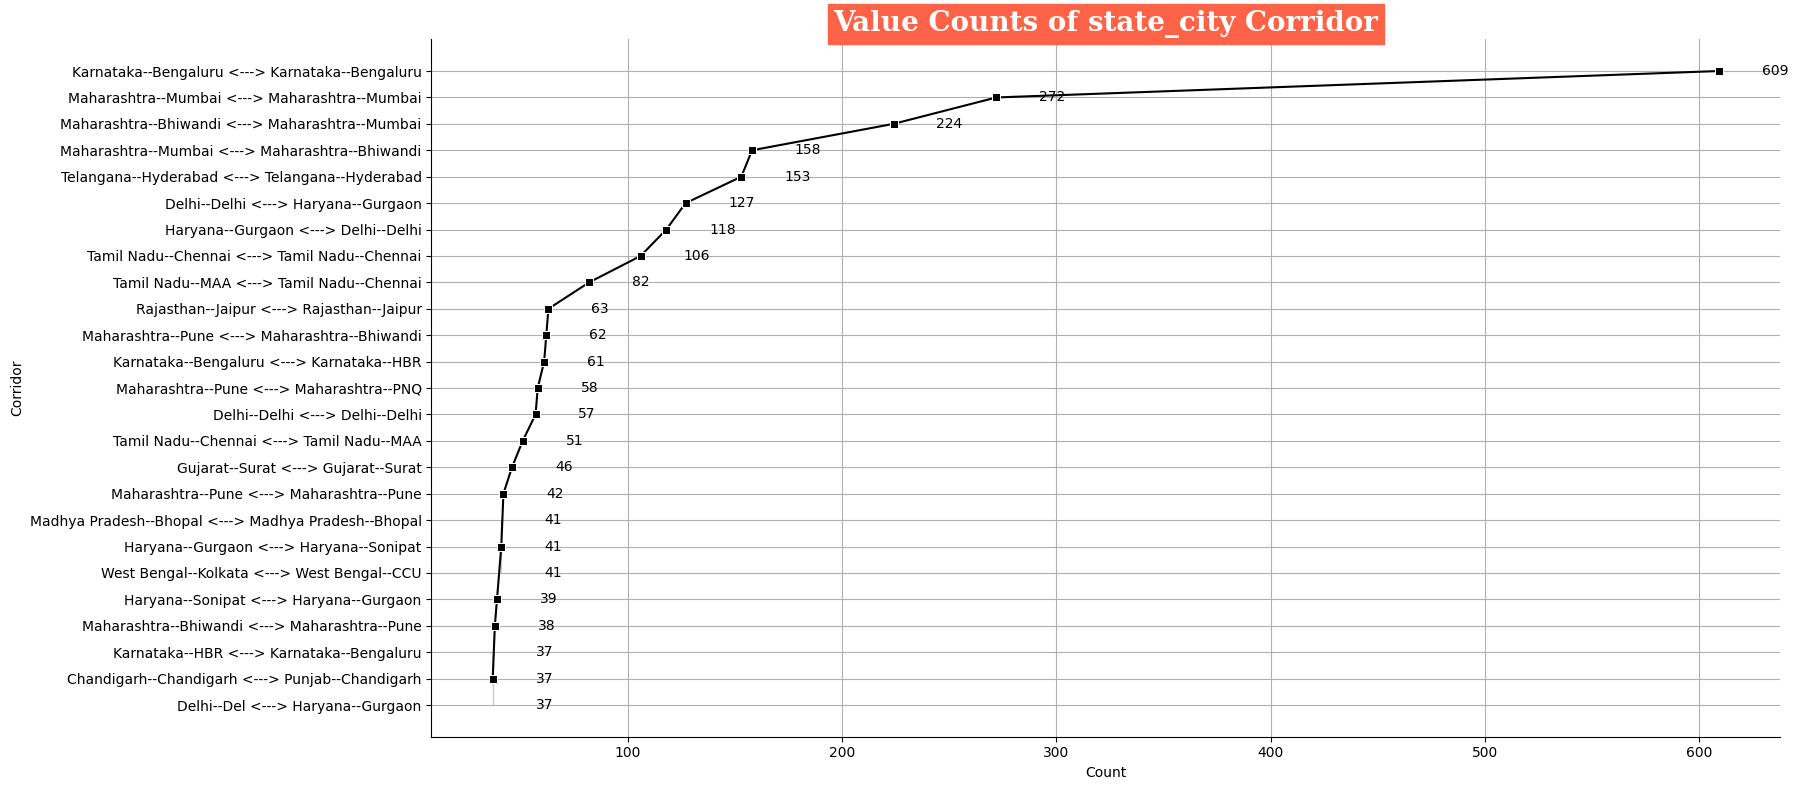

In [118]:
state_corridor_counts = de['state_corridor'].value_counts()[:25]

plt.figure(figsize=(18,8))
sns.lineplot(y=state_corridor_counts.index, x=state_corridor_counts.values, marker='s', color='k')
plt.title('Value Counts of state_city Corridor',fontsize=20,fontfamily='serif',fontweight='bold',backgroundcolor='tomato',color='w')
plt.ylabel('Corridor')
plt.xlabel('Count')
plt.tight_layout()
sns.despine()
plt.grid(True)

for i, count in enumerate(state_corridor_counts.values):
    plt.text(count+20, state_corridor_counts.index[i], str(count), ha='left', va='center')

plt.show()

In [119]:
de['city_corridor'] = de['source_city']+'--'+de['source_place'] +' <---> '+ de['destination_city']+'--'+de['destination_place']
display(de['city_corridor'].value_counts())

,count
city_corridor,
Bengaluru--Nelmngla_H <---> Bengaluru--Bomsndra_HB,64
Pune--Tathawde_H <---> Bhiwandi--Mankoli_HB,62
Bengaluru--Nelmngla_H <---> Bengaluru--KGAirprt_HB,62
Bhiwandi--Mankoli_HB <---> Mumbai--Hub,54
Delhi--Gateway_HB <---> Gurgaon--Bilaspur_HB,50
...,...
Giridih--Shivalya_D <---> Madhupur--Sitarmrd_D,1
Anandnagar--LohiaDPP_D <---> Gorakhpur--Matriprm_IP,1
Gorakhpur--Matriprm_IP <---> Nichlaul--Wardno13_D,1


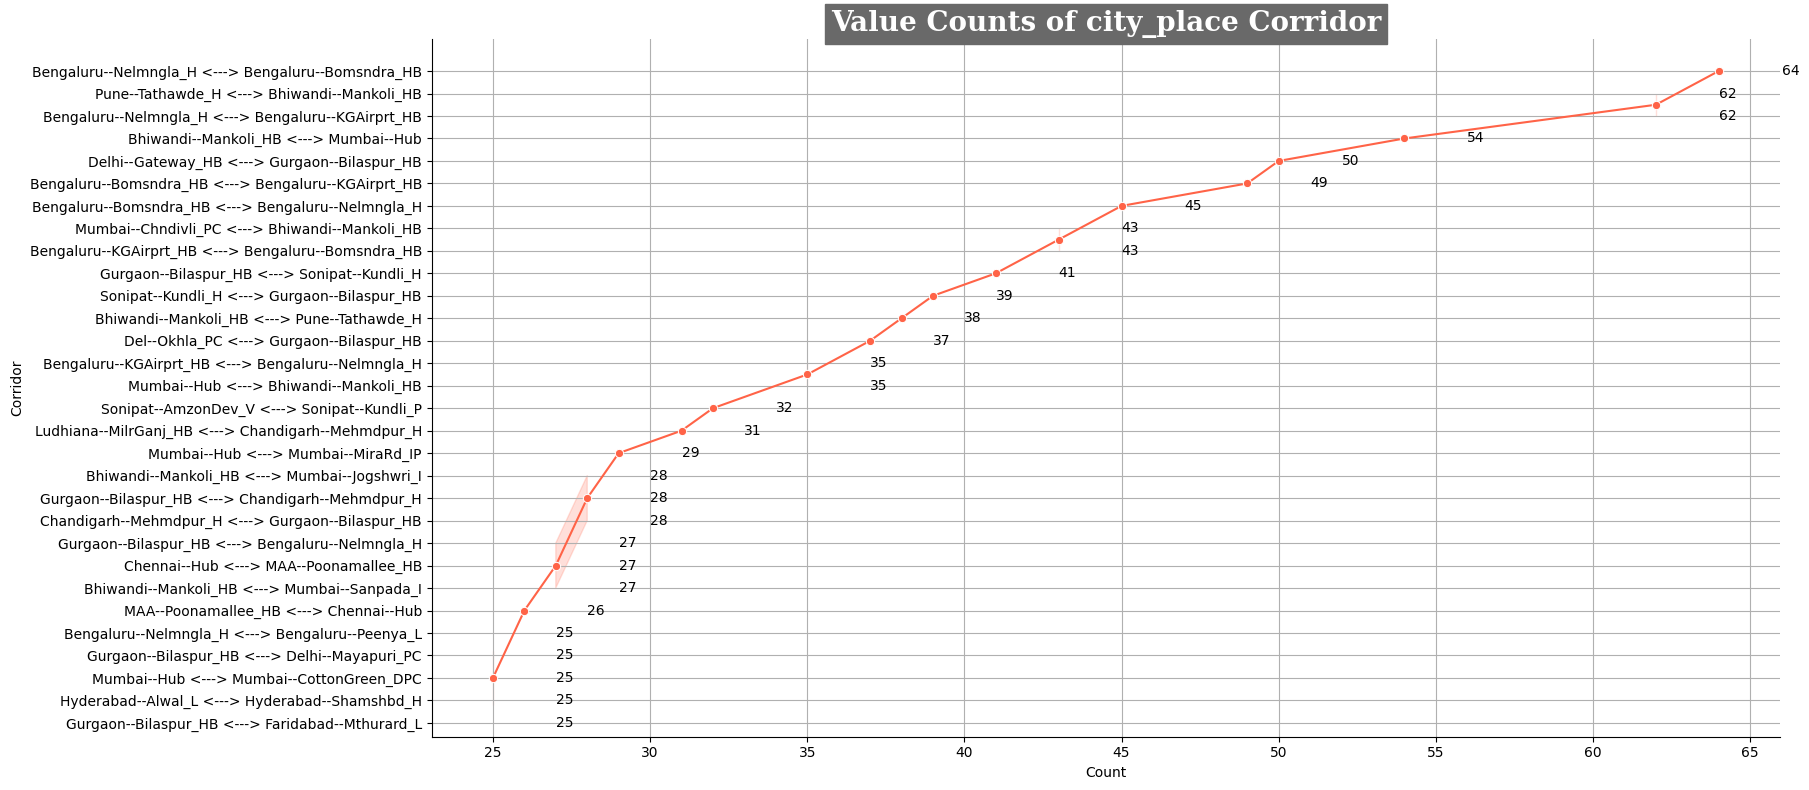

In [120]:
city_corridor_counts = de['city_corridor'].value_counts()[:30]

plt.figure(figsize=(18,8))
sns.lineplot(y=city_corridor_counts.index, x=city_corridor_counts.values, marker='o', color='tomato')
plt.title('Value Counts of city_place Corridor',fontsize=20,fontfamily='serif',fontweight='bold',backgroundcolor='dimgray',color='w')
plt.ylabel('Corridor')
plt.xlabel('Count')
plt.tight_layout()
sns.despine()
plt.grid(True)

for i, count in enumerate(city_corridor_counts.values):
    plt.text(count+2, city_corridor_counts.index[i], str(count), ha='left', va='center')

plt.show()

## Insights:
- Maharashtra, Karnataka, Haryana, and Tamil Nadu serve as key starting and ending locations for delivery services.
- Mumbai, Gurgaon, Delhi, and Bengaluru are major metropolitan centers from where many deliveries originate.
- A large proportion of nationwide deliveries are destined for Mumbai, Bengaluru, Gurgaon, and Delhi.

In [121]:
# 4. Extracting features like month, year, day, etc. from Trip_creation_time
de['trip_creation_month'] = de['trip_creation_time'].dt.month
de['trip_creation_year'] = de['trip_creation_time'].dt.year
de['trip_creation_day'] = de['trip_creation_time'].dt.day
de['trip_creation_hour'] = de['trip_creation_time'].dt.hour
de['trip_creation_weekday'] = de['trip_creation_time'].dt.weekday
de['trip_creation_week'] = de['trip_creation_time'].dt.isocalendar().week
de

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_total_time,od_time_diff_hour,source_city,source_place,source_state,destination_city,destination_place,destination_state,corridor,state_corridor,city_corridor,trip_creation_month,trip_creation_year,trip_creation_day,trip_creation_hour,trip_creation_weekday,trip_creation_week
0,trip-153671074033284934+IND395009AAA+IND395023AAD,trip-153671074033284934,training,Carting,2018-09-12 00:05:40.333071,Surat_Central_D_12 (Gujarat),Surat_Central_I_4 (Gujarat),2018-09-12 02:31:39.246238,2018-09-12 05:16:28.581141,164.0,12.264924,128.0,16.0,17.022499,128.0,16.0,17.022499,128.0,16.0,17.022499,0 days 02:44:49.334903,2.747037,Surat,Central_D_12,Gujarat,Surat,Central_I_4,Gujarat,Surat_Central_D_12 (Gujarat) <---> Surat_Centr...,Gujarat--Surat <---> Gujarat--Surat,Surat--Central_D_12 <---> Surat--Central_I_4,9,2018,12,0,2,37
1,trip-153671074033284934+IND395023AAD+IND395004AAB,trip-153671074033284934,training,Carting,2018-09-12 00:05:40.333071,Surat_Central_I_4 (Gujarat),Surat_Central_D_3 (Gujarat),2018-09-12 00:05:40.333071,2018-09-12 02:01:41.638015,116.0,13.189923,33.0,13.0,13.913400,33.0,13.0,13.913300,33.0,13.0,13.913300,0 days 01:56:01.304944,1.933696,Surat,Central_I_4,Gujarat,Surat,Central_D_3,Gujarat,Surat_Central_I_4 (Gujarat) <---> Surat_Centra...,Gujarat--Surat <---> Gujarat--Surat,Surat--Central_I_4 <---> Surat--Central_D_3,9,2018,12,0,2,37
2,trip-153671079956500691+IND110024AAA+IND110014AAA,trip-153671079956500691,training,Carting,2018-09-12 00:06:39.565253,Delhi_Lajpat_IP (Delhi),Delhi_Bhogal (Delhi),2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999,0 days 00:49:20.003392,0.822223,Delhi,Lajpat_IP,Delhi,Delhi,Bhogal,Delhi,Delhi_Lajpat_IP (Delhi) <---> Delhi_Bhogal (De...,Delhi--Delhi <---> Delhi--Delhi,Delhi--Lajpat_IP <---> Delhi--Bhogal,9,2018,12,0,2,37
3,trip-153671110078355292+IND121004AAB+IND121001AAA,trip-153671110078355292,training,Carting,2018-09-12 00:11:40.783923,FBD_Balabhgarh_DPC (Haryana),Faridabad (Haryana),2018-09-12 00:11:40.783923,2018-09-12 00:50:10.814399,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900,0 days 00:38:30.030476,0.641675,FBD,Balabhgarh_DPC,Haryana,Faridabad,Faridabad,Haryana,FBD_Balabhgarh_DPC (Haryana) <---> Faridabad (...,Haryana--FBD <---> Haryana--Faridabad,FBD--Balabhgarh_DPC <---> Faridabad--Faridabad,9,2018,12,0,2,37
4,trip-153671127071609610+IND585104AAA+IND586128AAA,trip-153671127071609610,training,Carting,2018-09-12 00:14:30.716368,Gulbarga_Nehrugnj_I (Karnataka),Sindagi_KalyanNg_D (Karnataka),2018-09-12 00:14:30.716368,2018-09-12 03:21:35.028141,187.0,78.450333,148.0,73.0,92.522400,147.0,78.0,97.721992,147.0,78.0,97.721992,0 days 03:07:04.311773,3.117864,Gulbarga,Nehrugnj_I,Karnataka,Sindagi,KalyanNg_D,Karnataka,Gulbarga_Nehrugnj_I (Karnataka) <---> Sindagi_...,Karnataka--Gulbarga <---> Karnataka--Sindagi,Gulbarga--Nehrugnj_I <---> Sindagi--KalyanNg_D,9,2018,12,0,2,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11820,trip-153861095625827784+IND160102AAD+IND160002AAC,trip-153861095625827784,test,Carting,2018-10-03 23:55:56.258533,Chandigarh_Raiprkln_C (Chandigarh),Chandigarh_Mehmdpur_H (Punjab),2018-10-04 04:56:10.943956,2018-10-04 06:41:25.409035,105.0,31.261599,49.0,34.0,44.563900,49.0,34.0,35.956001,49.0,34.0,35.956001,0 days 01:45:14.465079,1.754018,Chandigarh,Raiprkln_C,Chandigarh,Chandigarh,Mehmdpur_H,Punjab,Chandigarh_Raiprkln_C (Chandigarh) <---> Chand...,Chandigarh--Chandigarh <---> Punjab--Chandigarh,Chandigarh--Raiprkln_C <---> Chandigarh--Mehmd..

#In-depth analysis

In [122]:
new_df = de.copy()

In [123]:
new_df.columns

Index(['segment_key', 'trip_uuid', 'data', 'route_type', 'trip_creation_time',
       'source_name', 'destination_name', 'od_start_time', 'od_end_time',
       'start_scan_to_end_scan', 'actual_distance_to_destination',
       'actual_time', 'osrm_time', 'osrm_distance', 'segment_actual_time',
       'segment_osrm_time', 'segment_osrm_distance', 'segment_actual_time_sum',
       'segment_osrm_time_sum', 'segment_osrm_distance_sum', 'od_total_time',
       'od_time_diff_hour', 'source_city', 'source_place', 'source_state',
       'destination_city', 'destination_place', 'destination_state',
       'corridor', 'state_corridor', 'city_corridor', 'trip_creation_month',
       'trip_creation_year', 'trip_creation_day', 'trip_creation_hour',
       'trip_creation_weekday', 'trip_creation_week'],
      dtype='object')

In [124]:
new_df.sample(2)

,segment_key,trip_uuid,data,route_type,trip_creation_time,source_name,destination_name,od_start_time,od_end_time,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,od_total_time,od_time_diff_hour,source_city,source_place,source_state,destination_city,destination_place,destination_state,corridor,state_corridor,city_corridor,trip_creation_month,trip_creation_year,trip_creation_day,trip_creation_hour,trip_creation_weekday,trip_creation_week
4284,trip-153736515614896455+IND577401AAA+IND577201AAA,trip-153736515614896455,training,FTL,2018-09-19 13:52:36.149199,Sagara_Vardhard_D (Karnataka),Shimoga_DC (Karnataka),2018-09-20 02:36:27.193185,2018-09-20 05:12:56.298090,156.0,65.557899,108.0,87.0,84.285103,106.0,109.0,74.785995,106.0,109.0,74.785995,0 days 02:36:29.104905,2.608085,Sagara,Vardhard_D,Karnataka,Shimoga,DC,Karnataka,Sagara_Vardhard_D (Karnataka) <---> Shimoga_DC...,Karnataka--Sagara <---> Karnataka--Shimoga,Sagara--Vardhard_D <---> Shimoga--DC,9,2018,19,13,2,38
8274,trip-153797930071860378+IND683511AAA+IND000000ADM,trip-153797930071860378,training,Carting,2018-09-26 16:28:20.718846,Aluva_Peedika_H (Kerala),Cochin_Kdvantra_D (Kerala),2018-09-26 16:28:20.718846,2018-09-27 01:41:37.263043,553.0,18.484652,43.0,24.0,21.260500,42.0,23.0,21.260500,42.0,23.0,21.260500,0 days 09:13:16.544197,9.221262,Aluva,Peedika_H,Kerala,Cochin,Kdvantra_D,Kerala,Aluva_Peedika_H (Kerala) <---> Cochin_Kdvantra...,Kerala--Aluva <---> Kerala--Cochin,Aluva--Peedika_H <---> Cochin--Kdvantra_D,9,2018,26,16,2,39


In [125]:
create_trip_dict={
  'data' : 'first',
  'route_type' : 'first',
  'od_start_time':'first',
  'od_end_time':'last',
  'od_time_diff_hour' : 'sum',
  'trip_creation_time' : 'first',
  'trip_creation_month' : 'first',
  'trip_creation_year' : 'first',
  'trip_creation_day' : 'first',
  'trip_creation_hour' : 'first',
  'trip_creation_weekday' : 'first',
  'trip_creation_week' : 'first',
  'start_scan_to_end_scan' : 'sum',
  'actual_distance_to_destination' : 'sum',
  'actual_time' : 'sum',
  'osrm_time' : 'sum',
  'osrm_distance' : 'sum',
  'segment_actual_time': 'sum',
  'segment_osrm_time': 'sum',
  'segment_osrm_distance': 'sum',
  'segment_actual_time_sum': 'sum',
  'segment_osrm_time_sum': 'sum',
  'segment_osrm_distance_sum': 'sum',
  'source_name': 'first',
  'source_city':'first',
  'source_state':'first',
  'source_place':'first',
  'destination_name': 'first',
  'destination_city':'first',
  'destination_state':'first',
  'destination_place':'first',
  'corridor':'first',
  'state_corridor':'first',
  'city_corridor':'first'
  }

trip_agg_df = new_df.groupby('trip_uuid').agg(create_trip_dict).reset_index()
trip_agg_df

,trip_uuid,data,route_type,od_start_time,od_end_time,od_time_diff_hour,trip_creation_time,trip_creation_month,trip_creation_year,trip_creation_day,trip_creation_hour,trip_creation_weekday,trip_creation_week,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,source_name,source_city,source_state,source_place,destination_name,destination_city,destination_state,destination_place,corridor,state_corridor,city_corridor
0,trip-153671074033284934,training,Carting,2018-09-12 02:31:39.246238,2018-09-12 02:01:41.638015,4.680733,2018-09-12 00:05:40.333071,9,2018,12,0,2,37,280.0,25.454847,161.0,29.0,30.935898,161.0,29.0,30.935799,161.0,29.0,30.935799,Surat_Central_D_12 (Gujarat),Surat,Gujarat,Central_D_12,Surat_Central_I_4 (Gujarat),Surat,Gujarat,Central_I_4,Surat_Central_D_12 (Gujarat) <---> Surat_Centr...,Gujarat--Surat <---> Gujarat--Surat,Surat--Central_D_12 <---> Surat--Central_I_4
1,trip-153671079956500691,training,Carting,2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,0.822223,2018-09-12 00:06:39.565253,9,2018,12,0,2,37,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999,Delhi_Lajpat_IP (Delhi),Delhi,Delhi,Lajpat_IP,Delhi_Bhogal (Delhi),Delhi,Delhi,Bhogal,Delhi_Lajpat_IP (Delhi) <---> Delhi_Bhogal (De...,Delhi--Delhi <---> Delhi--Delhi,Delhi--Lajpat_IP <---> Delhi--Bhogal
2,trip-153671110078355292,training,Carting,2018-09-12 00:11:40.783923,2018-09-12 00:50:10.814399,0.641675,2018-09-12 00:11:40.783923,9,2018,12,0,2,37,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900,FBD_Balabhgarh_DPC (Haryana),FBD,Haryana,Balabhgarh_DPC,Faridabad (Haryana),Faridabad,Haryana,Faridabad,FBD_Balabhgarh_DPC (Haryana) <---> Faridabad (...,Haryana--FBD <---> Haryana--Faridabad,FBD--Balabhgarh_DPC <---> Faridabad--Faridabad
3,trip-153671127071609610,training,Carting,2018-09-12 00:14:30.716368,2018-09-12 07:54:13.838441,15.511243,2018-09-12 00:14:30.716368,9,2018,12,0,2,37,928.0,230.413864,561.0,253.0,284.458191,554.0,258.0,293.844696,554.0,258.0,293.844696,Gulbarga_Nehrugnj_I (Karnataka),Gulbarga,Karnataka,Nehrugnj_I,Sindagi_KalyanNg_D (Karnataka),Sindagi,Karnataka,KalyanNg_D,Gulbarga_Nehrugnj_I (Karnataka) <---> Sindagi_...,Karnataka--Gulbarga <---> Karnataka--Sindagi,Gulbarga--Nehrugnj_I <---> Sindagi--KalyanNg_D
4,trip-153671191949943656,training,FTL,2018-09-12 04:33:09.726898,2018-09-12 09:23:49.463096,4.844371,2018-09-12 00:25:19.499696,9,2018,12,0,2,37,290.0,99.975594,253.0,105.0,124.506302,252.0,132.0,140.562302,252.0,132.0,140.562302,Narsinghpur_KndliDPP_D (Madhya Pradesh),Narsinghpur,Madhya Pradesh,KndliDPP_D,Gadarwara_MPward_D (Madhya Pradesh),Gadarwara,Madhya Pradesh,MPward_D,Narsinghpur_KndliDPP_D (Madhya Pradesh) <---> ...,Madhya Pradesh--Narsinghpur <---> Madhya Prade...,Narsinghpur--KndliDPP_D <---> Gadarwara--MPward_D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6676,trip-153861089559302126,test,Carting,2018-10-03 23:54:55.593290,2018-10-04 03:46:15.195842,3.126754,2018-10-03 23:54:55.593290,10,2018,3,23,2,40,186.0,28.114090,86.0,30.0,34.922401,86.0,30.0,34.922298,86.0,30.0,34.922298,Mumbai_East_I_21 (Maharashtra),Mumbai,Maharashtra,East_I_21,Mumbai_Ulhasngr_DC (Maharashtra),Mumbai,Maharashtra,Ulhasngr_DC,Mumbai_East_I_21 (Maharashtra) <---> Mumbai_Ul...,Maharashtra--Mumbai <---> Maharashtra--Mumbai,Mumbai--East_I_21 <---> Mumbai--Ulhasngr_DC
6677,trip-153861089872028474,test,Carting,2018-10-03 23:54:58.720536,2018-10-04 02:57:23.720337,3.040278,2018-10-03 23:54:58.720536,10,2018,3,23,2,40,181.0,27.010925,62.0,28.0,38.286697,61.0,33.0,33.639999,61.0,33.0,33.639999,Chennai_Porur_DPC (Tamil Nadu),Chennai,Tamil Nadu,Porur_DPC,Chennai_Vepmpttu_DC (Tamil Nadu),Chennai,Tamil Nadu,Vepmpttu_DC,Chennai_Porur_DPC (Tamil Nadu) <---> Chenn

In [126]:
numerical_columns = trip_agg_df.select_dtypes(include=[np.float32, np.float64])
numerical_columns

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,4.680733,280.0,25.454847,161.0,29.0,30.935898,161.0,29.0,30.935799,161.0,29.0,30.935799
1,0.822223,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999
2,0.641675,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900
3,15.511243,928.0,230.413864,561.0,253.0,284.458191,554.0,258.0,293.844696,554.0,258.0,293.844696
4,4.844371,290.0,99.975594,253.0,105.0,124.506302,252.0,132.0,140.562302,252.0,132.0,140.562302
...,...,...,...,...,...,...,...,...,...,...,...,...
6676,3.126754,186.0,28.114090,86.0,30.0,34.922401,86.0,30.0,34.922298,86.0,30.0,34.922298
6677,3.040278,181.0,27.010925,62.0,28.0,38.286697,61.0,33.0,33.639999,61.0,33.0,33.639999
6678,4.300482,257.0,57.762333,83.0,62.0,73.462997,82.0,62.0,64.855103,82.0,62.0,64.855103
6679,7.035331,421.0,38.684837,282.0,48.0,58.903702,281.0,88.0,104.886597,281.0,88.0,104.886597


In [127]:
numerical_columns.describe().T

,count,mean,std,min,25%,50%,75%,max
od_time_diff_hour,6681.0,8.808342,10.917330,0.463311,2.512328,4.725590,10.482100,124.315659
start_scan_to_end_scan,6681.0,527.400513,654.172180,27.000000,150.000000,283.000000,627.000000,7458.000000
actual_distance_to_destination,6681.0,164.237976,303.202942,9.003577,23.065063,48.713085,161.357483,2185.480225
actual_time,6681.0,355.222260,558.235168,9.000000,68.000000,150.000000,364.000000,6265.000000
osrm_time,6681.0,161.133957,269.826721,6.000000,30.000000,60.000000,167.000000,2032.000000
osrm_distance,6681.0,204.014145,368.380951,9.072900,30.955502,65.985100,204.741394,2839.660156
segment_actual_time,6681.0,351.979034,553.138428,9.000000,67.000000,148.000000,361.000000,6230.000000
segment_osrm_time,6681.0,180.391113,311.022125,6.000000,31.000000,65.000000,184.000000,2494.000000
segment_osrm_distance,6681.0,222.448029,412.019104,9.072900,32.950199,71.223404,215.281693,3418.182861
segment_actual_time_sum,6681.0,351.979034,553.138428,9.000000,67.000000,148.000000,361.000000,6230.000000


In [128]:
trip_agg_df.describe(include = object).T

,count,unique,top,freq
trip_uuid,6681,6681,trip-153861118270144424,1
source_name,6681,742,Gurgaon_Bilaspur_HB (Haryana),485
source_city,6681,561,Bengaluru,730
source_state,6681,29,Maharashtra,1241
source_place,6681,639,Bilaspur_HB,485
destination_name,6681,840,Gurgaon_Bilaspur_HB (Haryana),368
destination_city,6681,689,Bengaluru,698
destination_state,6681,32,Maharashtra,1180
destination_place,6681,704,Bilaspur_HB,368
corridor,6681,1335,Pune_Tathawde_H (Maharashtra) <---> Bhiwandi_M...,62


In [129]:
trip_df = trip_agg_df.copy()

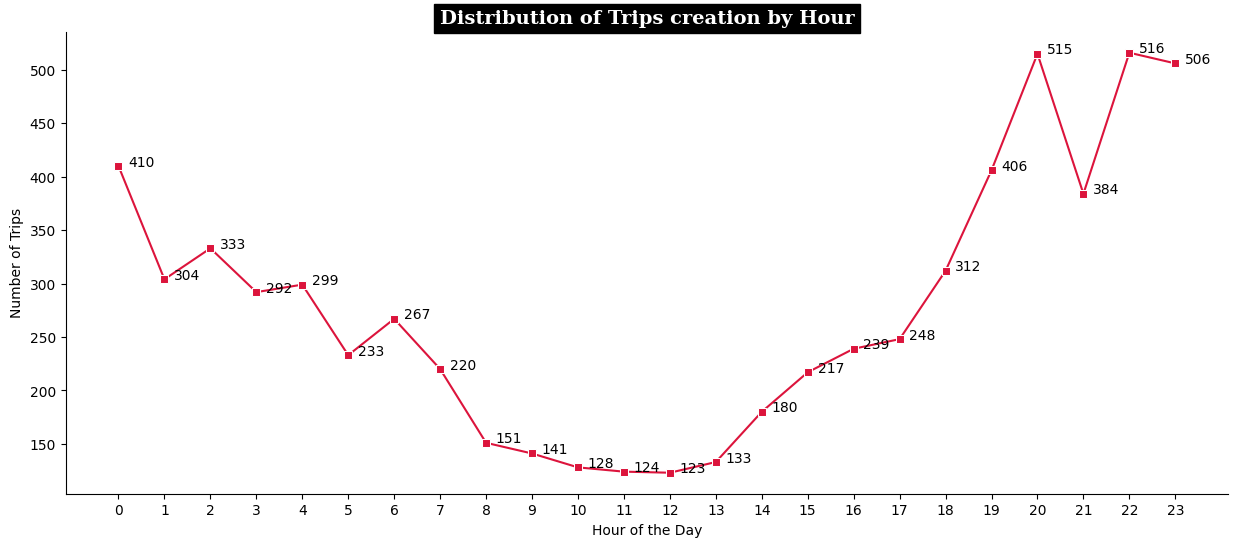

In [131]:
trip_creation_by_hour = trip_df.groupby(by='trip_creation_hour')['trip_uuid'].count().reset_index()

plt.figure(figsize=(15,6))
sns.lineplot(data=trip_creation_by_hour, x='trip_creation_hour', y='trip_uuid', marker='s', color='crimson')
plt.xticks(np.arange(0, 24))

for i, count in enumerate(trip_creation_by_hour['trip_uuid']):
    plt.text(trip_creation_by_hour['trip_creation_hour'][i]+0.5, count, count, ha='center')

plt.title('Distribution of Trips creation by Hour',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='k',color='w')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
sns.despine()
plt.show()

In [132]:
trip_df.sample()

,trip_uuid,data,route_type,od_start_time,od_end_time,od_time_diff_hour,trip_creation_time,trip_creation_month,trip_creation_year,trip_creation_day,trip_creation_hour,trip_creation_weekday,trip_creation_week,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,source_name,source_city,source_state,source_place,destination_name,destination_city,destination_state,destination_place,corridor,state_corridor,city_corridor
6615,trip-153859936712332299,test,Carting,2018-10-03 20:42:47.123593,2018-10-04 04:01:02.073160,9.214738,2018-10-03 20:42:47.123593,10,2018,3,20,2,40,552.0,138.242264,368.0,169.0,188.281708,364.0,169.0,174.838898,364.0,169.0,174.838898,Coimbatore_Karayam_H (Tamil Nadu),Coimbatore,Tamil Nadu,Karayam_H,Udumalpet_Artclgrd_D (Tamil Nadu),Udumalpet,Tamil Nadu,Artclgrd_D,Coimbatore_Karayam_H (Tamil Nadu) <---> Udumal...,Tamil Nadu--Coimbatore <---> Tamil Nadu--Uduma...,Coimbatore--Karayam_H <---> Udumalpet--Artclgrd_D


In [133]:
trip_df.trip_creation_year.value_counts()

,count
trip_creation_year,
2018,6681


In [134]:
trip_df.trip_creation_month.value_counts()

,count
trip_creation_month,
9,5884
10,797


In [135]:
trip_df['trip_creation_month'].value_counts(normalize = True) * 100

,proportion
trip_creation_month,
9,88.070648
10,11.929352


In [136]:
trip_df.trip_creation_week.value_counts()

,count
trip_creation_week,
38,2264
39,1970
37,1650
40,797


In [137]:
trip_df.trip_creation_weekday.value_counts(ascending=True)

,count
trip_creation_weekday,
6,783
0,906
1,925
3,947
5,950
4,983
2,1187


In [138]:
trip_df['trip_creation_day_week'] = trip_df['trip_creation_time'].dt.day_name()

In [139]:
trip_df.trip_creation_day.value_counts()

,count
trip_creation_day,
18,370
21,367
15,358
13,343
14,341
17,331
12,324
22,323
25,322


In [140]:
trip_df.sample()

,trip_uuid,data,route_type,od_start_time,od_end_time,od_time_diff_hour,trip_creation_time,trip_creation_month,trip_creation_year,trip_creation_day,trip_creation_hour,trip_creation_weekday,trip_creation_week,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,source_name,source_city,source_state,source_place,destination_name,destination_city,destination_state,destination_place,corridor,state_corridor,city_corridor,trip_creation_day_week
4106,trip-153781739343259695,training,FTL,2018-09-25 02:20:27.377294,2018-09-25 02:20:27.377294,9.345462,2018-09-24 19:29:53.432970,9,2018,24,19,0,39,560.0,140.353806,273.0,171.0,209.703598,270.0,197.0,215.427292,270.0,197.0,215.427292,Deoghar_Barmasia_D (Jharkhand),Deoghar,Jharkhand,Barmasia_D,Godda_Central_D_2 (Jharkhand),Godda,Jharkhand,Central_D_2,Deoghar_Barmasia_D (Jharkhand) <---> Godda_Cen...,Jharkhand--Deoghar <---> Jharkhand--Godda,Deoghar--Barmasia_D <---> Godda--Central_D_2,Monday


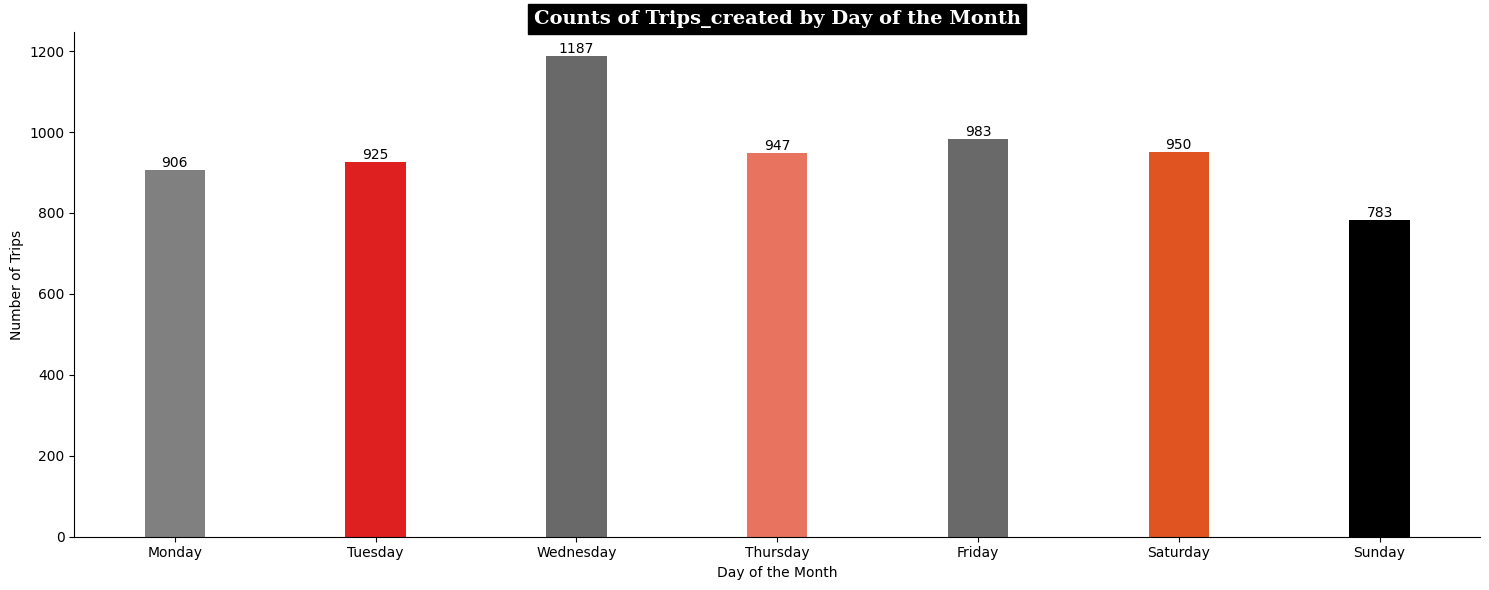

In [141]:
plt.figure(figsize=(15,6))

weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = trip_df['trip_creation_day_week'].value_counts().reindex(weekday_order)

sns.barplot(x=day_counts.index, y=day_counts.values, palette=cp,width=0.3)
for i, count in enumerate(day_counts.values):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.title('Counts of Trips_created by Day of the Month',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='k',color='w')
plt.xlabel('Day of the Month')
plt.ylabel('Number of Trips')
plt.tight_layout()
sns.despine()
plt.show()

In [142]:
trip_df['trip_creation_dayofdate'] = trip_df['trip_creation_time'].dt.day

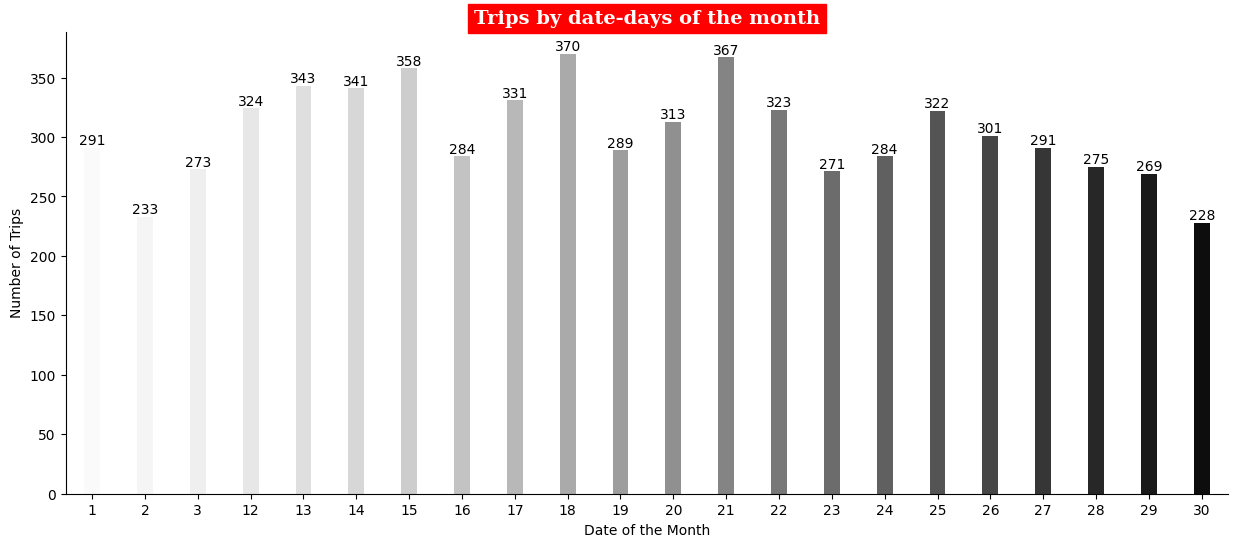

In [143]:
trips_by_dateday = trip_df.groupby(by = 'trip_creation_dayofdate')['trip_uuid'].count().to_frame().reset_index()

plt.figure(figsize = (15, 6))
sns.barplot(data =trip_df,x = trips_by_dateday['trip_creation_dayofdate'],y = trips_by_dateday['trip_uuid'], palette='Greys',width=0.3)
for i, count in enumerate(trips_by_dateday['trip_uuid']):
    plt.text(i, count, str(count), ha='center', va='bottom')
plt.title('Trips by date-days of the month',fontsize=14,fontfamily='serif',fontweight='bold',backgroundcolor='r',color='w')
plt.xlabel('Date of the Month')
plt.ylabel('Number of Trips')
sns.despine()
plt.show()

# Outlier treatment

In [144]:
numerical_columns

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,4.680733,280.0,25.454847,161.0,29.0,30.935898,161.0,29.0,30.935799,161.0,29.0,30.935799
1,0.822223,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999
2,0.641675,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900
3,15.511243,928.0,230.413864,561.0,253.0,284.458191,554.0,258.0,293.844696,554.0,258.0,293.844696
4,4.844371,290.0,99.975594,253.0,105.0,124.506302,252.0,132.0,140.562302,252.0,132.0,140.562302
...,...,...,...,...,...,...,...,...,...,...,...,...
6676,3.126754,186.0,28.114090,86.0,30.0,34.922401,86.0,30.0,34.922298,86.0,30.0,34.922298
6677,3.040278,181.0,27.010925,62.0,28.0,38.286697,61.0,33.0,33.639999,61.0,33.0,33.639999
6678,4.300482,257.0,57.762333,83.0,62.0,73.462997,82.0,62.0,64.855103,82.0,62.0,64.855103
6679,7.035331,421.0,38.684837,282.0,48.0,58.903702,281.0,88.0,104.886597,281.0,88.0,104.886597


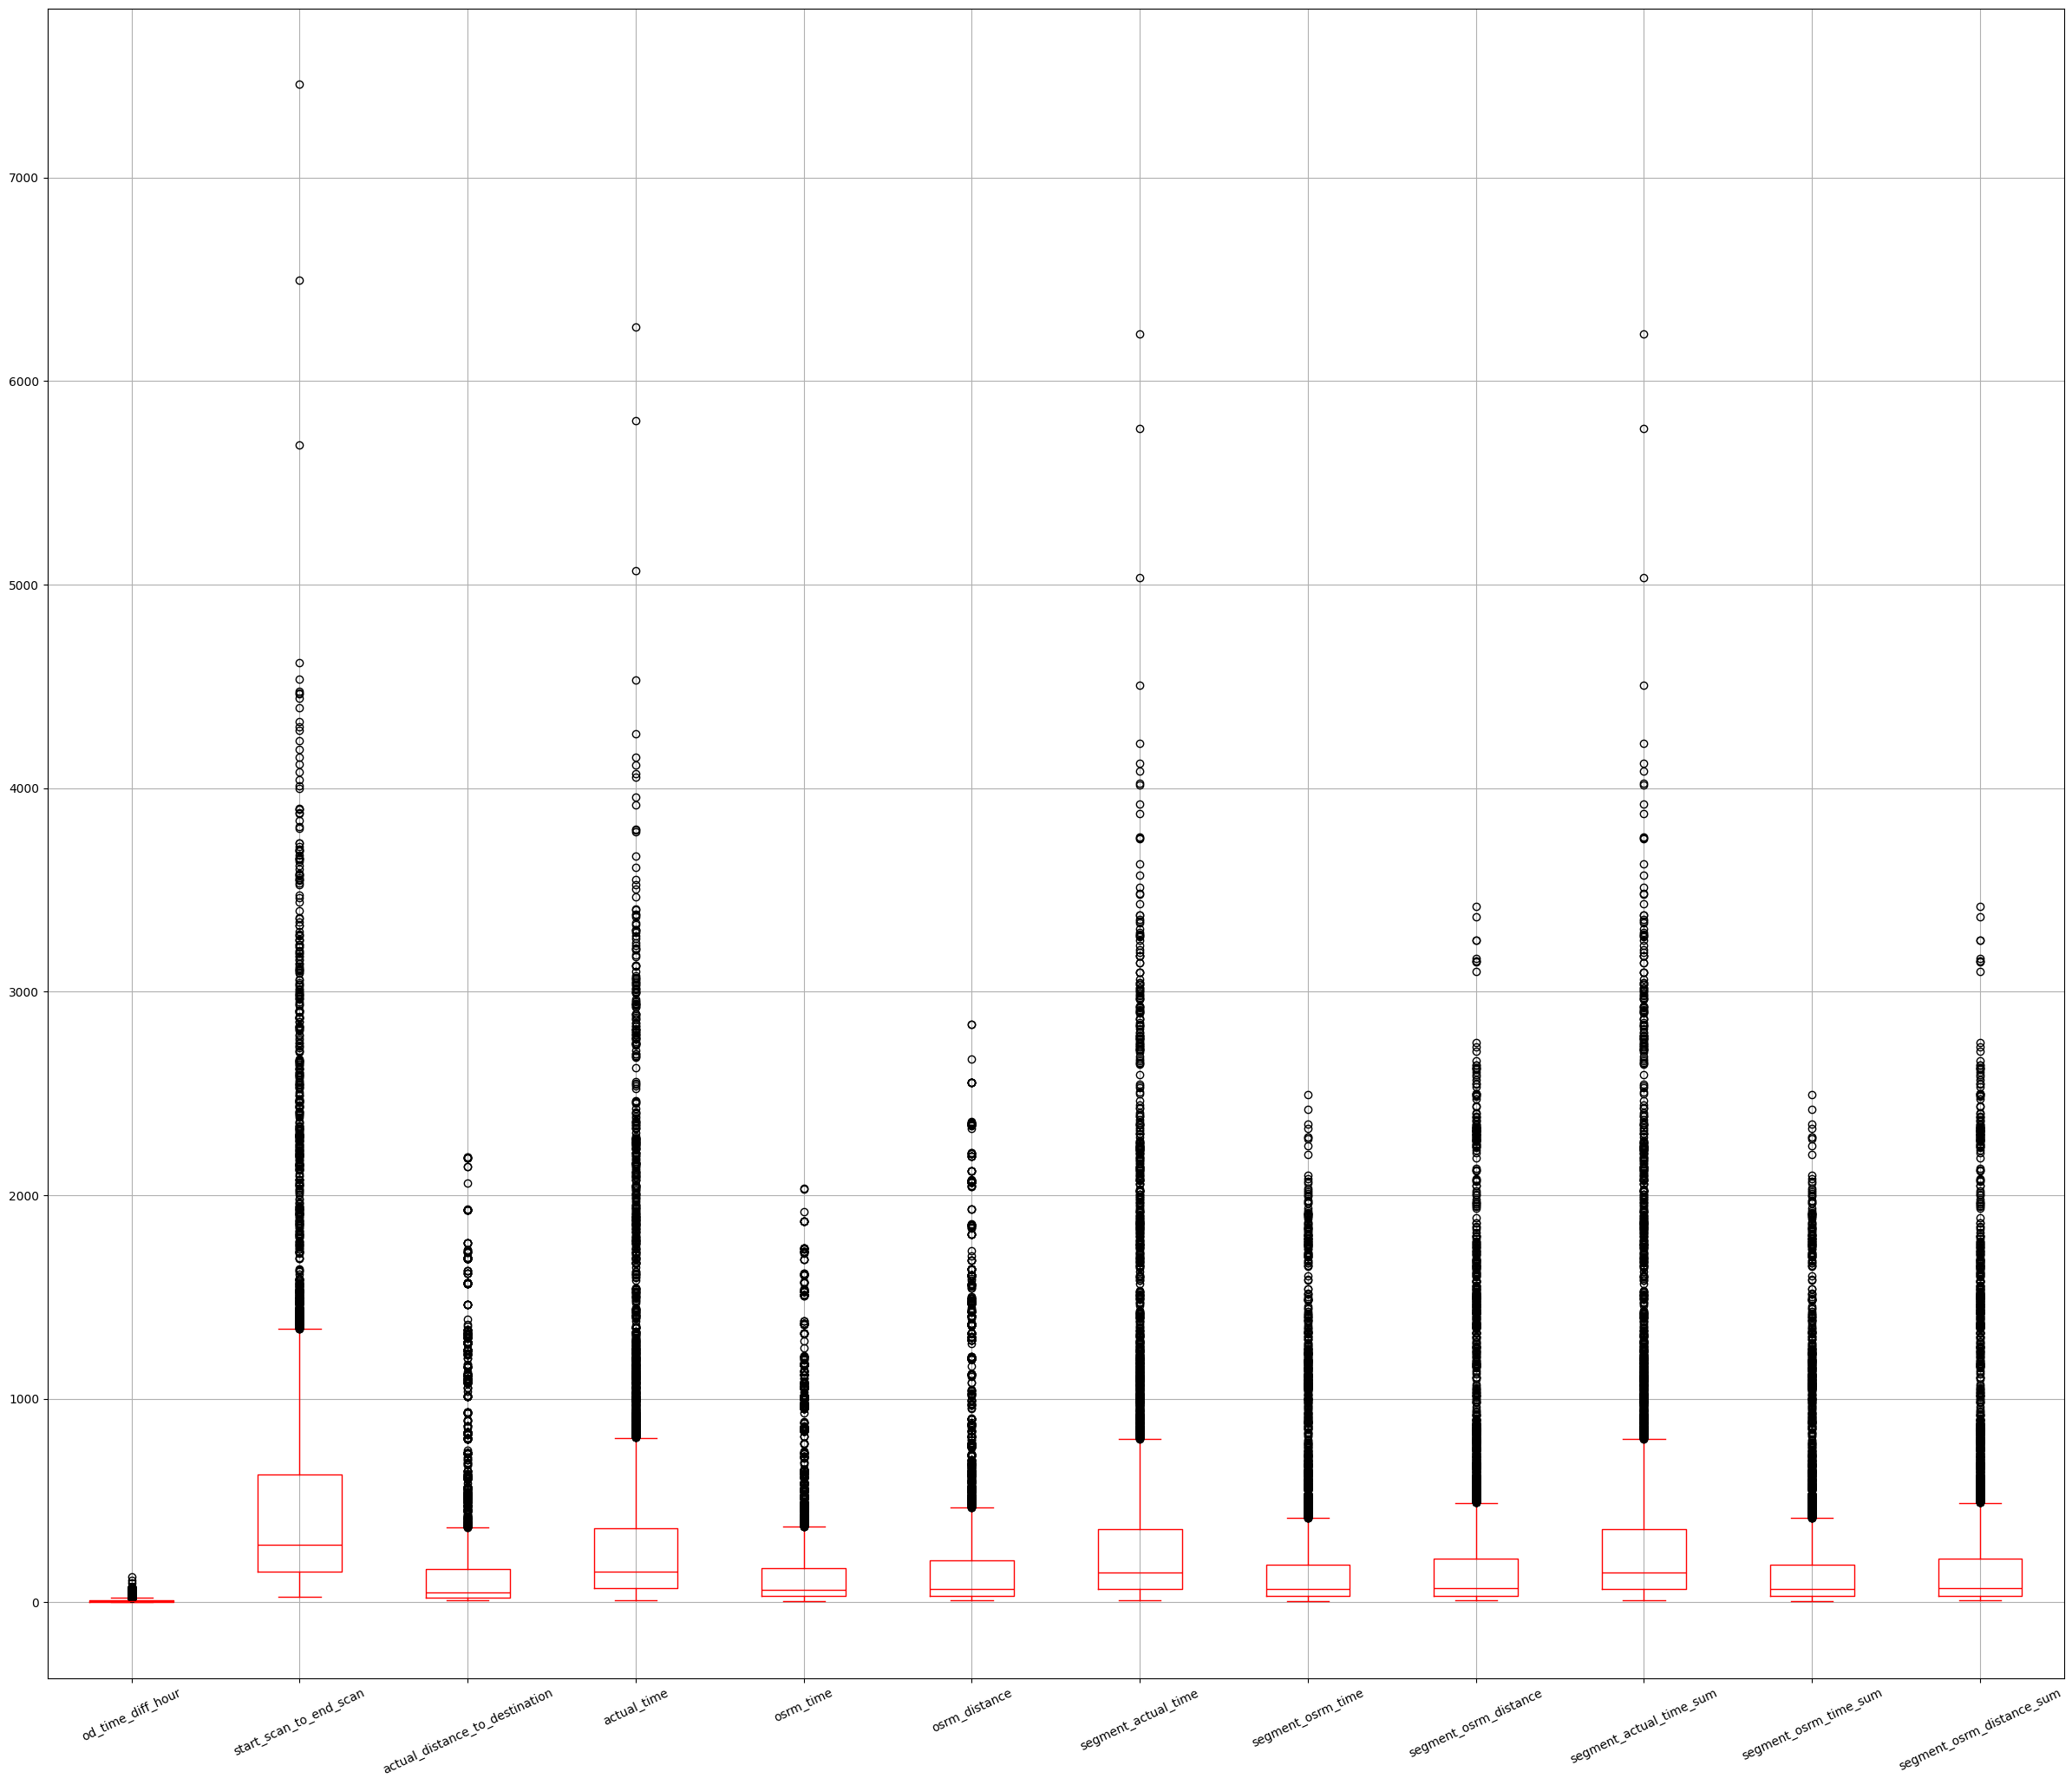

In [145]:
plt.figure(figsize=(30, 25))
numerical_columns.boxplot(rot=25, figsize=(35,20), color = 'r')
plt.grid('off')
plt.show()

In [146]:
numerical_columns.columns

Index(['od_time_diff_hour', 'start_scan_to_end_scan',
       'actual_distance_to_destination', 'actual_time', 'osrm_time',
       'osrm_distance', 'segment_actual_time', 'segment_osrm_time',
       'segment_osrm_distance', 'segment_actual_time_sum',
       'segment_osrm_time_sum', 'segment_osrm_distance_sum'],
      dtype='object')

In [147]:
num_cols = numerical_columns.columns.tolist()
num_cols

['od_time_diff_hour',
 'start_scan_to_end_scan',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_actual_time_sum',
 'segment_osrm_time_sum',
 'segment_osrm_distance_sum']

In [148]:
# obtain the first quartile
Q1 = numerical_columns.quantile(0.25)

# obtain the third quartile
Q3 = numerical_columns.quantile(0.75)

# obtain the IQR
IQR = Q3 - Q1

# print the IQR
print(IQR)

od_time_diff_hour                   7.969772
start_scan_to_end_scan            477.000000
actual_distance_to_destination    138.292419
actual_time                       296.000000
osrm_time                         137.000000
osrm_distance                     173.785892
segment_actual_time               294.000000
segment_osrm_time                 153.000000
segment_osrm_distance             182.331493
segment_actual_time_sum           294.000000
segment_osrm_time_sum             153.000000
segment_osrm_distance_sum         182.331493
dtype: float64


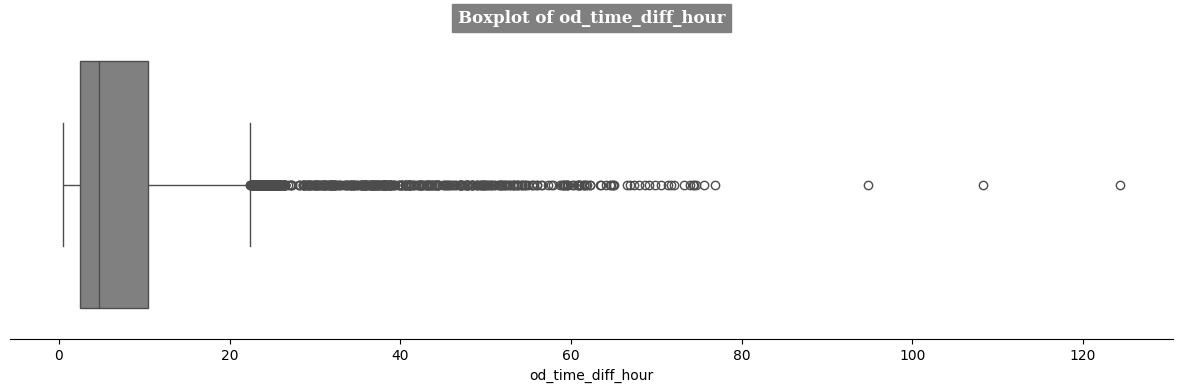

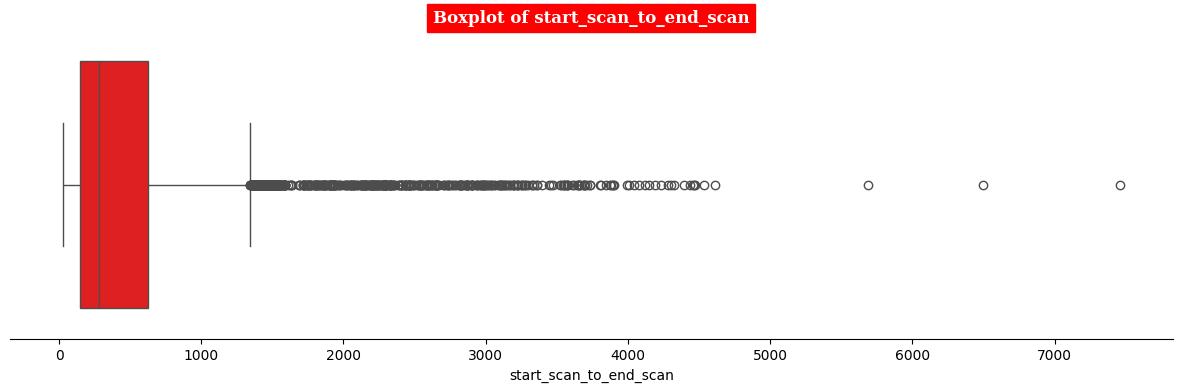

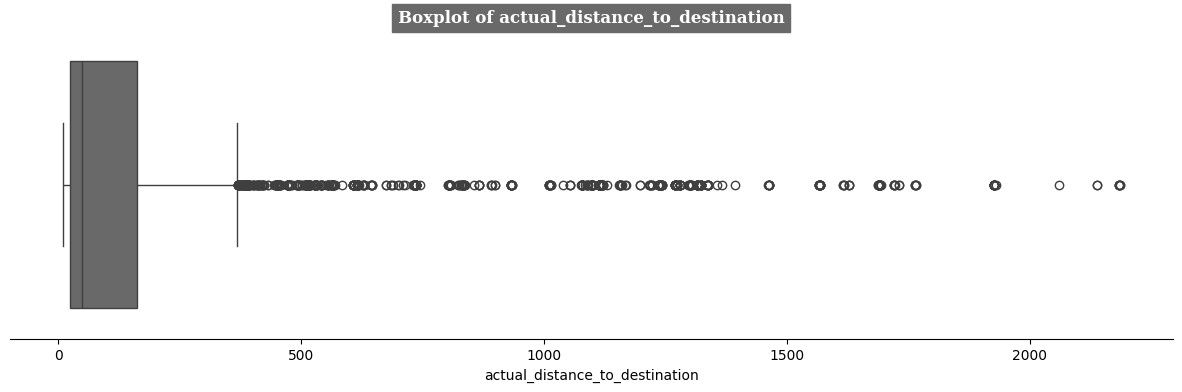

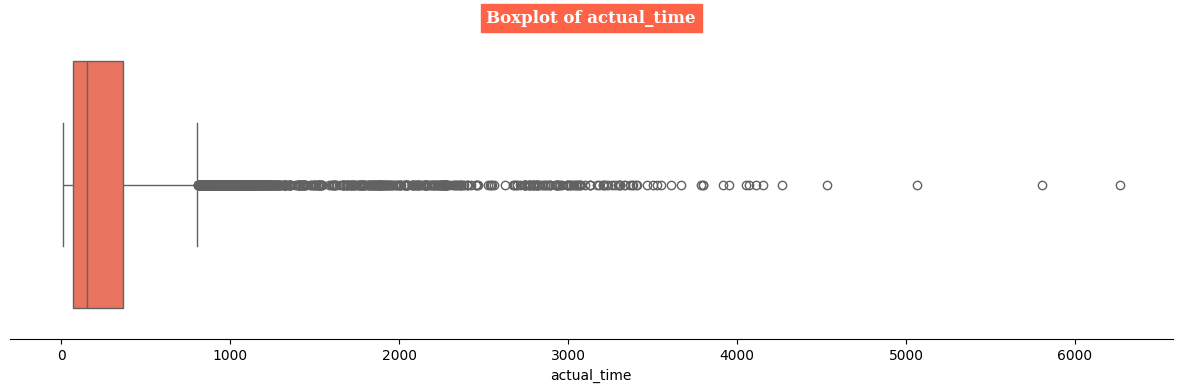

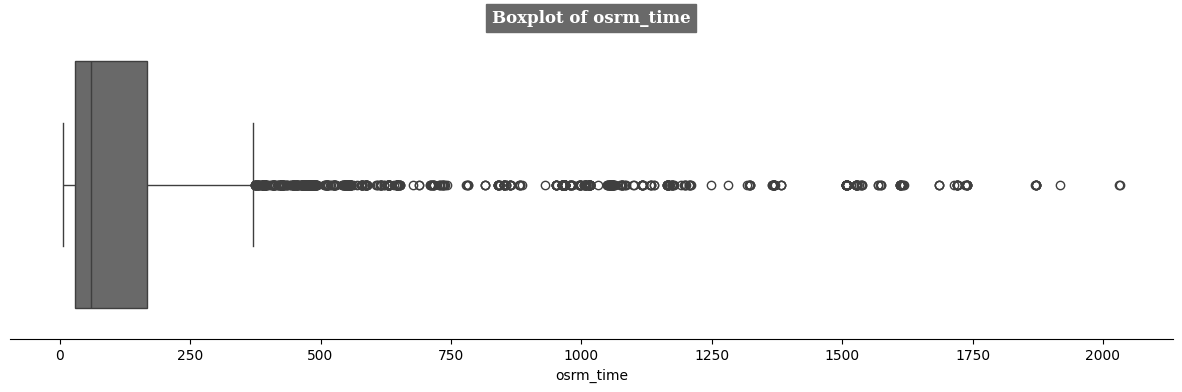

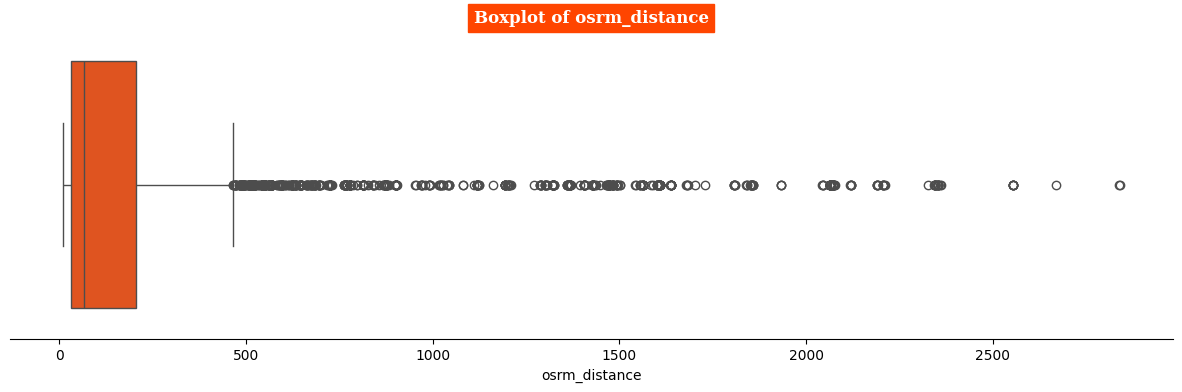

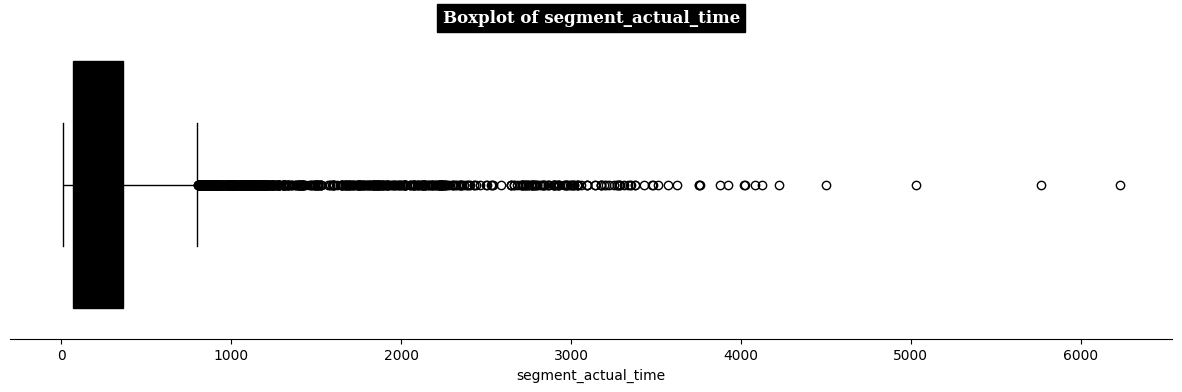

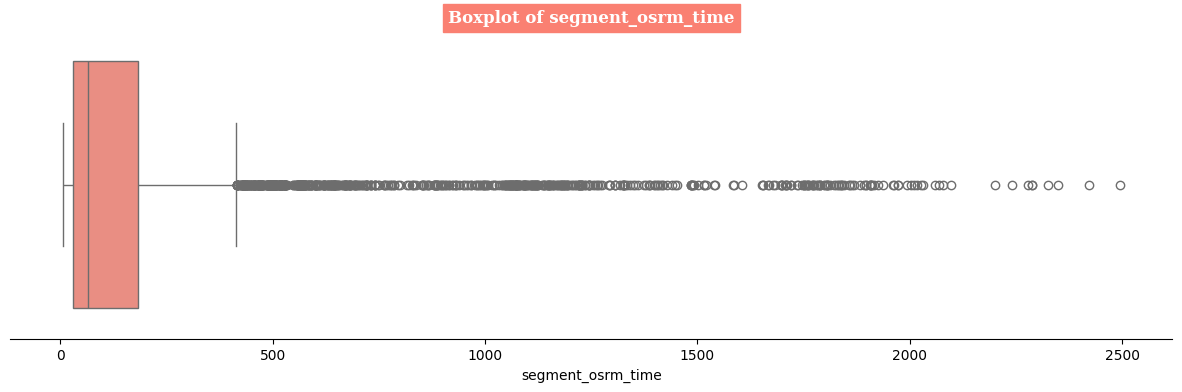

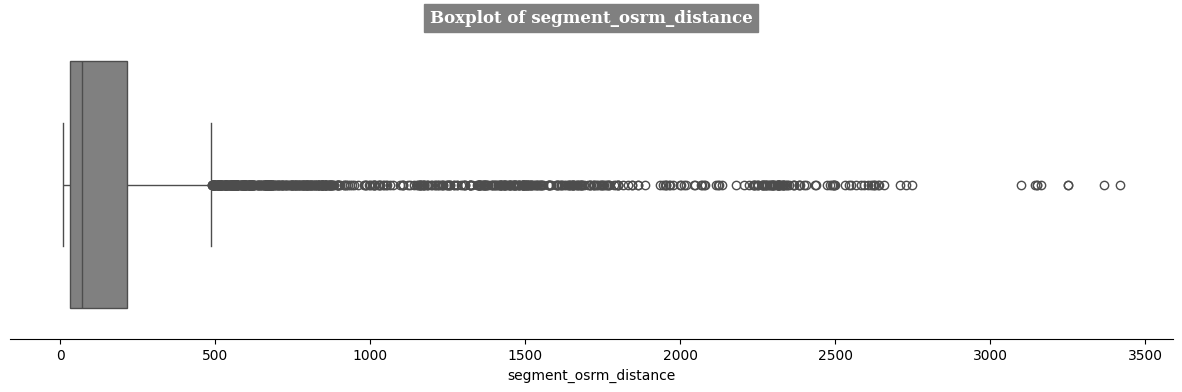

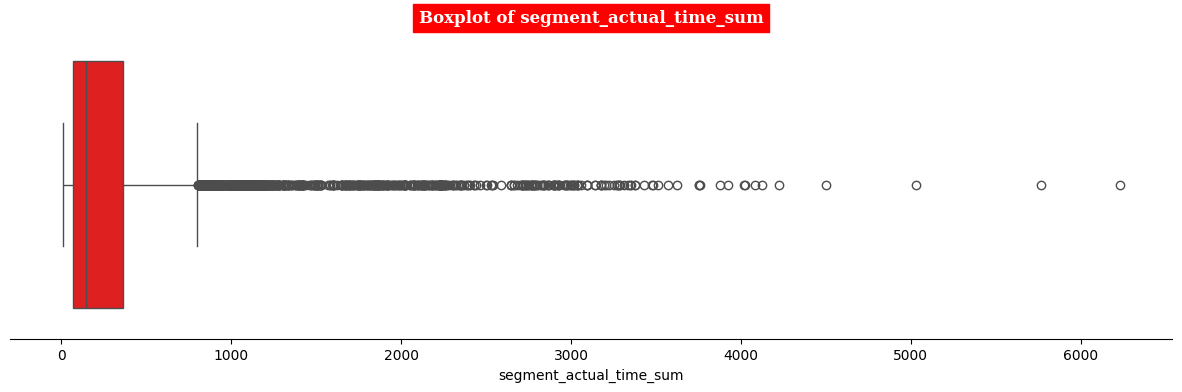

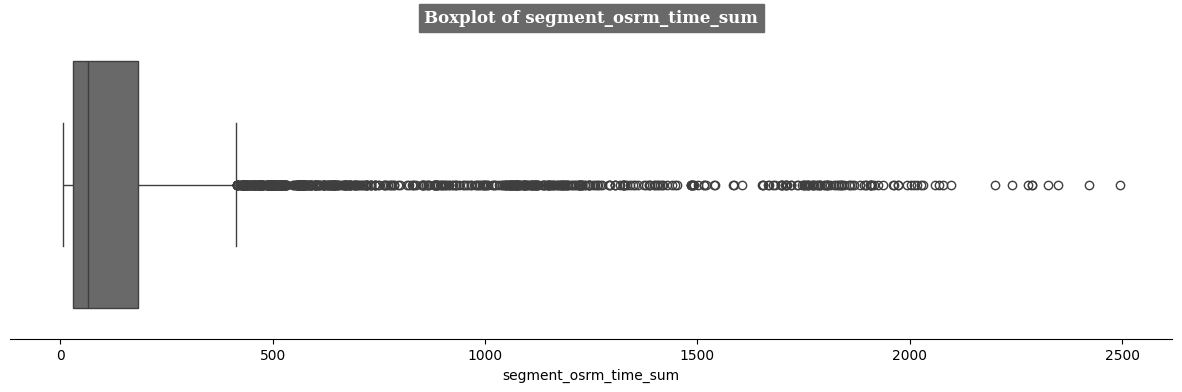

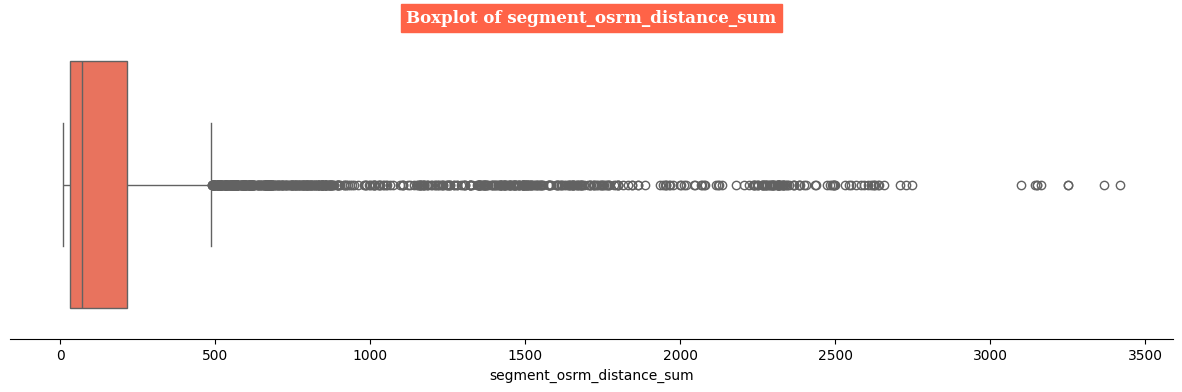

In [149]:
for i,col in enumerate(numerical_columns):
    plt.figure(figsize=(15,4))
    sns.boxplot(x=col, data=numerical_columns,color=cp[i])
    sns.despine(left=True)
    plt.yticks([])
    plt.title(f'Boxplot of {col}',fontfamily='serif',fontweight='bold',fontsize=12,backgroundcolor=cp[i],color='w')
    plt.show()

# Outlier removal

,od_time_diff_hour
0,4.680733
1,0.822223
2,0.641675
3,15.511243
4,4.844371
...,...
6676,3.126754
6677,3.040278
6678,4.300482
6679,7.035331


Clipped data of od_time_diff_hour


,od_time_diff_hour
0,4.680733
1,0.822223
2,0.641675
3,15.511243
4,4.844371
...,...
6676,3.126754
6677,3.040278
6678,4.300482
6679,7.035331



Filtered data of od_time_diff_hour


,od_time_diff_hour
0,4.680733
1,0.822223
2,0.641675
3,15.511243
4,4.844371
...,...
6676,3.126754
6677,3.040278
6678,4.300482
6679,7.035331


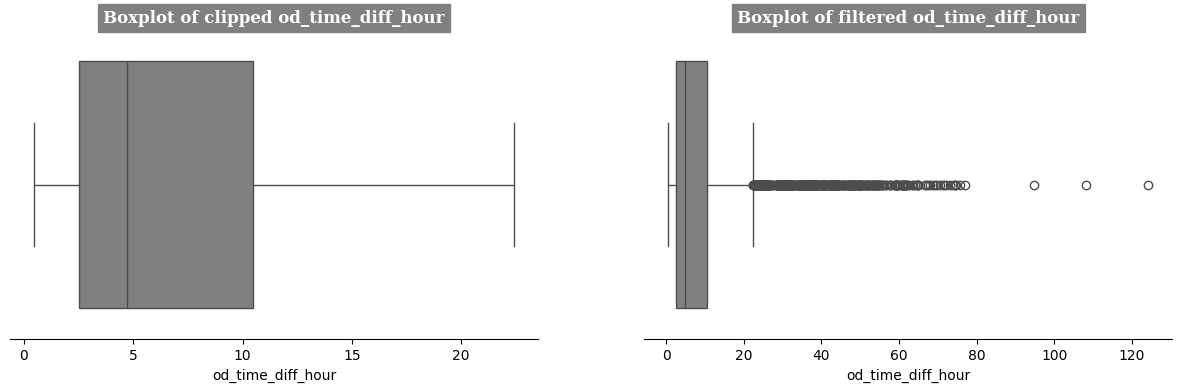

,start_scan_to_end_scan
0,280.0
1,49.0
2,38.0
3,928.0
4,290.0
...,...
6676,186.0
6677,181.0
6678,257.0
6679,421.0


Clipped data of start_scan_to_end_scan


,start_scan_to_end_scan
0,280.0
1,49.0
2,38.0
3,928.0
4,290.0
...,...
6676,186.0
6677,181.0
6678,257.0
6679,421.0



Filtered data of start_scan_to_end_scan


,start_scan_to_end_scan
0,280.0
1,49.0
2,38.0
3,928.0
4,290.0
...,...
6676,186.0
6677,181.0
6678,257.0
6679,421.0


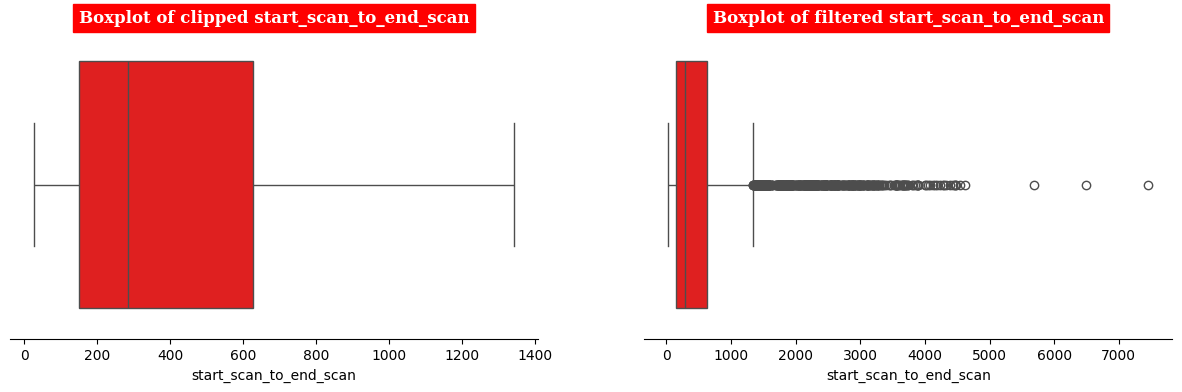

,actual_distance_to_destination
0,25.454847
1,9.872146
2,9.396525
3,230.413864
4,99.975594
...,...
6676,28.114090
6677,27.010925
6678,57.762333
6679,38.684837


Clipped data of actual_distance_to_destination


,actual_distance_to_destination
0,25.454847
1,9.872146
2,9.396525
3,230.413864
4,99.975594
...,...
6676,28.114090
6677,27.010925
6678,57.762333
6679,38.684837



Filtered data of actual_distance_to_destination


,actual_distance_to_destination
0,25.454847
1,9.872146
2,9.396525
3,230.413864
4,99.975594
...,...
6676,28.114090
6677,27.010925
6678,57.762333
6679,38.684837


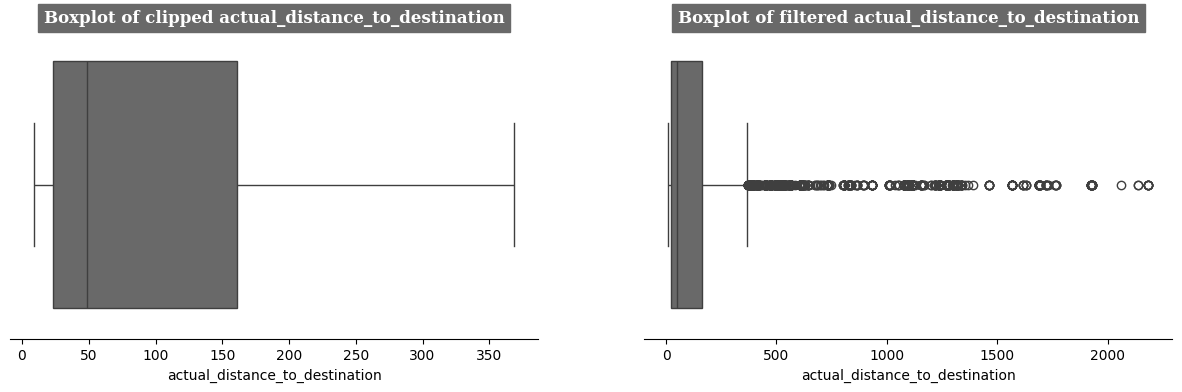

,actual_time
0,161.0
1,23.0
2,17.0
3,561.0
4,253.0
...,...
6676,86.0
6677,62.0
6678,83.0
6679,282.0


Clipped data of actual_time


,actual_time
0,161.0
1,23.0
2,17.0
3,561.0
4,253.0
...,...
6676,86.0
6677,62.0
6678,83.0
6679,282.0



Filtered data of actual_time


,actual_time
0,161.0
1,23.0
2,17.0
3,561.0
4,253.0
...,...
6676,86.0
6677,62.0
6678,83.0
6679,282.0


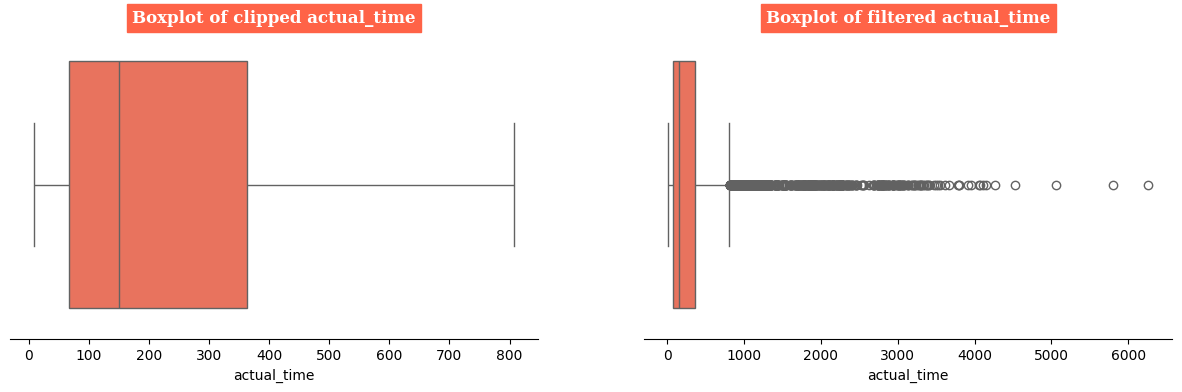

,osrm_time
0,29.0
1,8.0
2,9.0
3,253.0
4,105.0
...,...
6676,30.0
6677,28.0
6678,62.0
6679,48.0


Clipped data of osrm_time


,osrm_time
0,29.0
1,8.0
2,9.0
3,253.0
4,105.0
...,...
6676,30.0
6677,28.0
6678,62.0
6679,48.0



Filtered data of osrm_time


,osrm_time
0,29.0
1,8.0
2,9.0
3,253.0
4,105.0
...,...
6676,30.0
6677,28.0
6678,62.0
6679,48.0


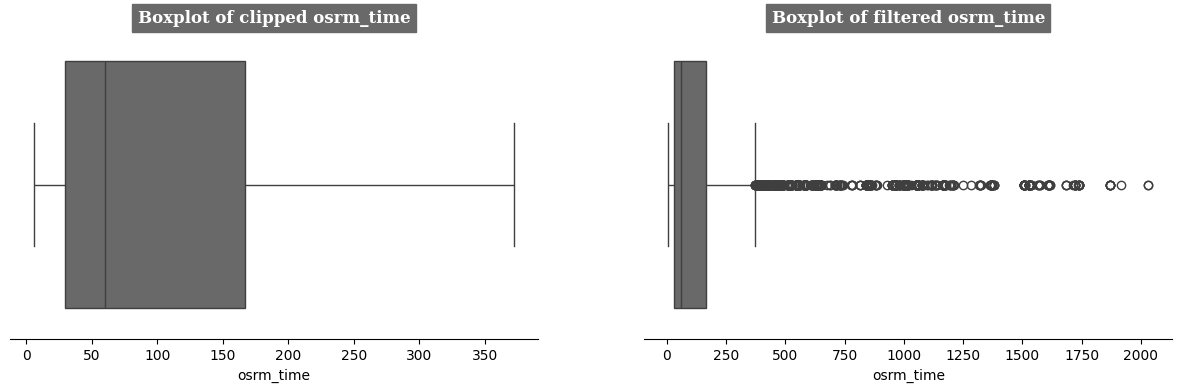

,osrm_distance
0,30.935898
1,9.956600
2,10.815900
3,284.458191
4,124.506302
...,...
6676,34.922401
6677,38.286697
6678,73.462997
6679,58.903702


Clipped data of osrm_distance


,osrm_distance
0,30.935898
1,9.956600
2,10.815900
3,284.458191
4,124.506302
...,...
6676,34.922401
6677,38.286697
6678,73.462997
6679,58.903702



Filtered data of osrm_distance


,osrm_distance
0,30.935898
1,9.956600
2,10.815900
3,284.458191
4,124.506302
...,...
6676,34.922401
6677,38.286697
6678,73.462997
6679,58.903702


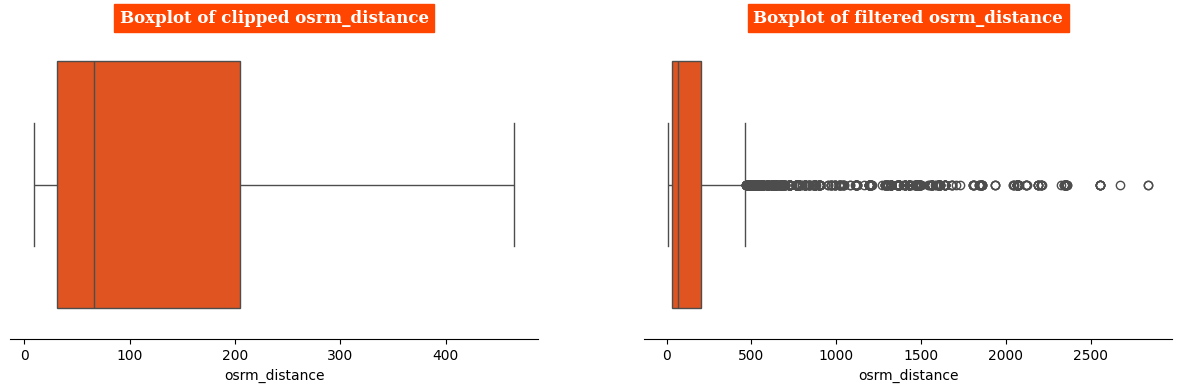

,segment_actual_time
0,161.0
1,23.0
2,17.0
3,554.0
4,252.0
...,...
6676,86.0
6677,61.0
6678,82.0
6679,281.0


Clipped data of segment_actual_time


,segment_actual_time
0,161.0
1,23.0
2,17.0
3,554.0
4,252.0
...,...
6676,86.0
6677,61.0
6678,82.0
6679,281.0



Filtered data of segment_actual_time


,segment_actual_time
0,161.0
1,23.0
2,17.0
3,554.0
4,252.0
...,...
6676,86.0
6677,61.0
6678,82.0
6679,281.0


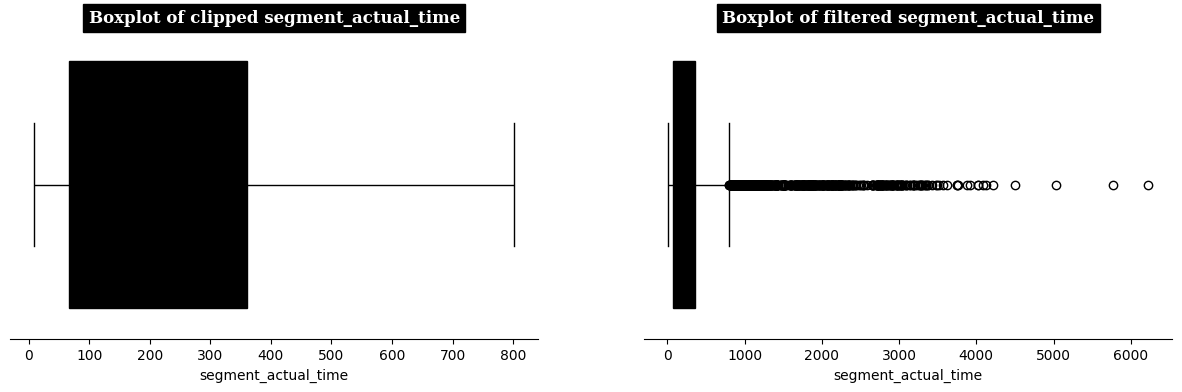

,segment_osrm_time
0,29.0
1,14.0
2,9.0
3,258.0
4,132.0
...,...
6676,30.0
6677,33.0
6678,62.0
6679,88.0


Clipped data of segment_osrm_time


,segment_osrm_time
0,29.0
1,14.0
2,9.0
3,258.0
4,132.0
...,...
6676,30.0
6677,33.0
6678,62.0
6679,88.0



Filtered data of segment_osrm_time


,segment_osrm_time
0,29.0
1,14.0
2,9.0
3,258.0
4,132.0
...,...
6676,30.0
6677,33.0
6678,62.0
6679,88.0


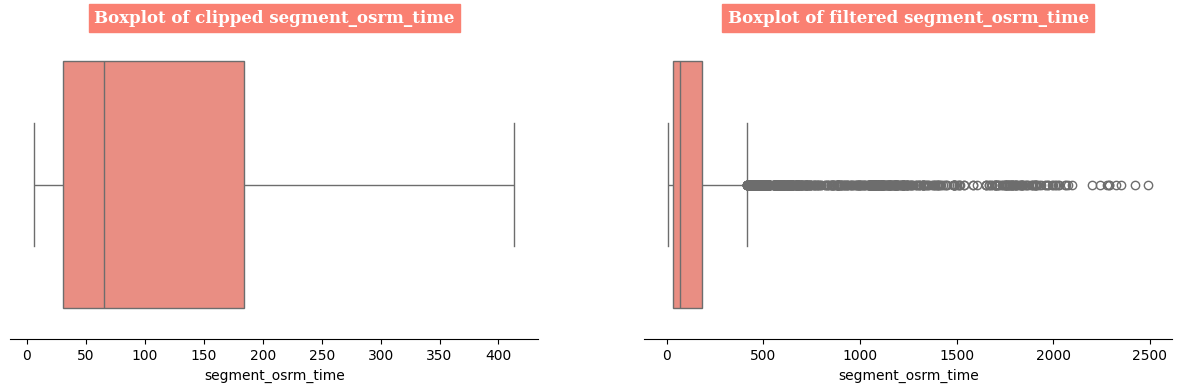

,segment_osrm_distance
0,30.935799
1,16.085999
2,10.815900
3,293.844696
4,140.562302
...,...
6676,34.922298
6677,33.639999
6678,64.855103
6679,104.886597


Clipped data of segment_osrm_distance


,segment_osrm_distance
0,30.935799
1,16.085999
2,10.815900
3,293.844696
4,140.562302
...,...
6676,34.922298
6677,33.639999
6678,64.855103
6679,104.886597



Filtered data of segment_osrm_distance


,segment_osrm_distance
0,30.935799
1,16.085999
2,10.815900
3,293.844696
4,140.562302
...,...
6676,34.922298
6677,33.639999
6678,64.855103
6679,104.886597


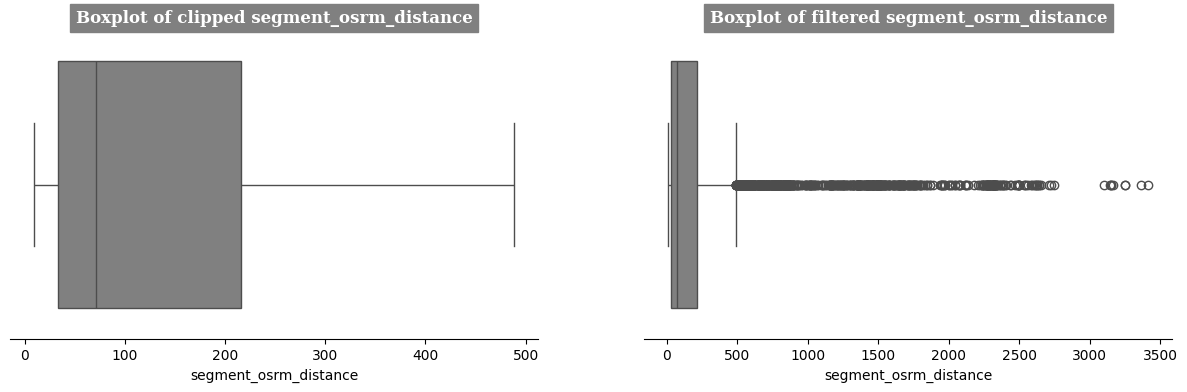

,segment_actual_time_sum
0,161.0
1,23.0
2,17.0
3,554.0
4,252.0
...,...
6676,86.0
6677,61.0
6678,82.0
6679,281.0


Clipped data of segment_actual_time_sum


,segment_actual_time_sum
0,161.0
1,23.0
2,17.0
3,554.0
4,252.0
...,...
6676,86.0
6677,61.0
6678,82.0
6679,281.0



Filtered data of segment_actual_time_sum


,segment_actual_time_sum
0,161.0
1,23.0
2,17.0
3,554.0
4,252.0
...,...
6676,86.0
6677,61.0
6678,82.0
6679,281.0


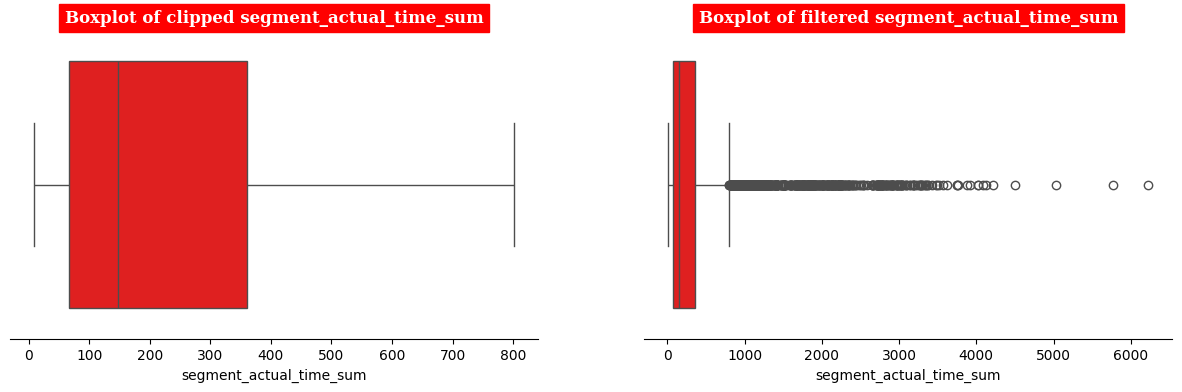

,segment_osrm_time_sum
0,29.0
1,14.0
2,9.0
3,258.0
4,132.0
...,...
6676,30.0
6677,33.0
6678,62.0
6679,88.0


Clipped data of segment_osrm_time_sum


,segment_osrm_time_sum
0,29.0
1,14.0
2,9.0
3,258.0
4,132.0
...,...
6676,30.0
6677,33.0
6678,62.0
6679,88.0



Filtered data of segment_osrm_time_sum


,segment_osrm_time_sum
0,29.0
1,14.0
2,9.0
3,258.0
4,132.0
...,...
6676,30.0
6677,33.0
6678,62.0
6679,88.0


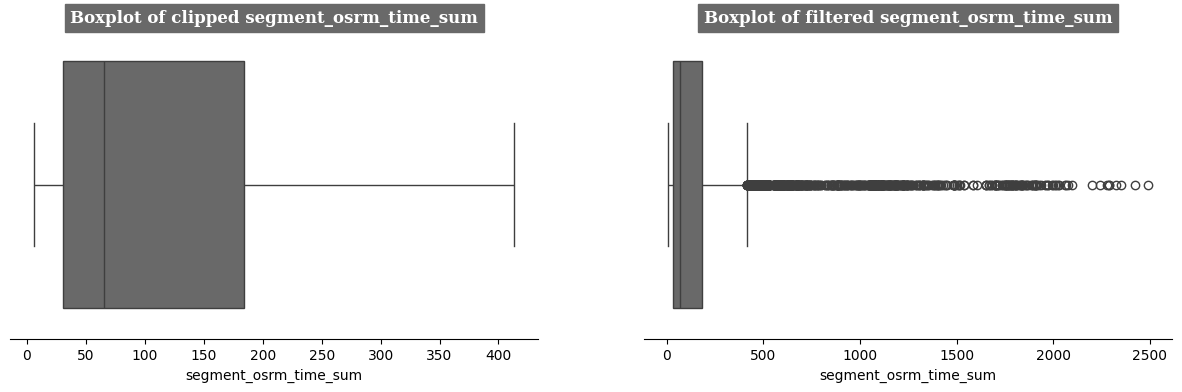

,segment_osrm_distance_sum
0,30.935799
1,16.085999
2,10.815900
3,293.844696
4,140.562302
...,...
6676,34.922298
6677,33.639999
6678,64.855103
6679,104.886597


Clipped data of segment_osrm_distance_sum


,segment_osrm_distance_sum
0,30.935799
1,16.085999
2,10.815900
3,293.844696
4,140.562302
...,...
6676,34.922298
6677,33.639999
6678,64.855103
6679,104.886597



Filtered data of segment_osrm_distance_sum


,segment_osrm_distance_sum
0,30.935799
1,16.085999
2,10.815900
3,293.844696
4,140.562302
...,...
6676,34.922298
6677,33.639999
6678,64.855103
6679,104.886597


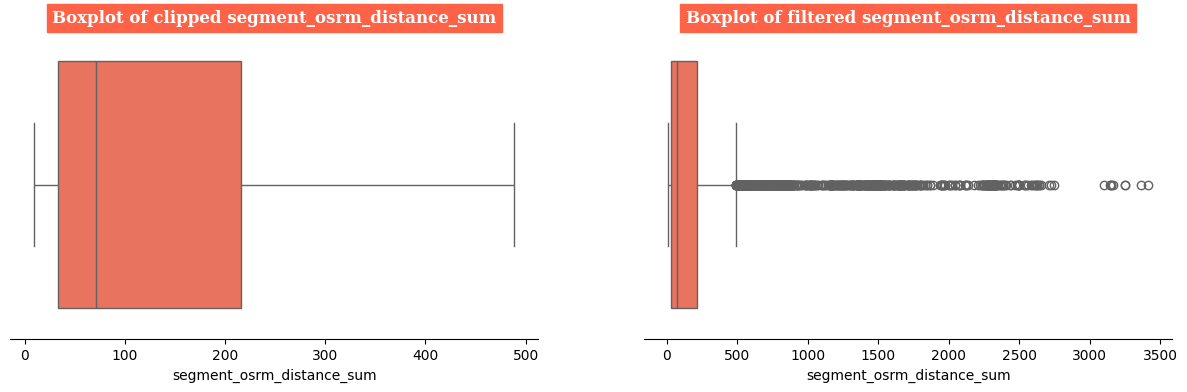

In [150]:
for i, col in enumerate(numerical_columns):

    data = trip_df[col]
    display(data.to_frame())


    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1


    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    clipped_data = np.clip(data, lower_bound, upper_bound)
    print(f'Clipped data of {col}')
    display(clipped_data.to_frame())
    print()

    # Plot boxplot of the clipped data
    plt.figure(figsize=(15, 4))
    plt.subplot(121)
    sns.boxplot(x=clipped_data, color=cp[i])
    sns.despine(left=True)
    plt.yticks([])
    plt.title(f'Boxplot of clipped {col}', fontfamily='serif', fontweight='bold', fontsize=12, backgroundcolor=cp[i], color='w')

    filtered_data = data.loc[(data >= lower_bound) | (data <= upper_bound)]
    print(f'Filtered data of {col}')
    display(filtered_data.to_frame())
    print()

    plt.subplot(122)
    sns.boxplot(x=filtered_data, color=cp[i])
    sns.despine(left=True)
    plt.yticks([])
    plt.title(f'Boxplot of filtered {col}', fontfamily='serif', fontweight='bold', fontsize=12, backgroundcolor=cp[i], color='w')

    plt.show()

#Understanding:
- Here we see that the data after removing outliers has outliers. It has to be understood that q1 and q3 dont have to be always 25th percentile and 75th percentile. Try changing q1 and q3 to 10th percentile to 90th percentile and plot and see...
- Clipped data replaces the outlier values with specified values.
- Here, I have proceeded with both clipped and filtered data(with reduced outliers) for further analysis.

In [151]:
num_df = numerical_columns.copy()
num_df

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,4.680733,280.0,25.454847,161.0,29.0,30.935898,161.0,29.0,30.935799,161.0,29.0,30.935799
1,0.822223,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999
2,0.641675,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900
3,15.511243,928.0,230.413864,561.0,253.0,284.458191,554.0,258.0,293.844696,554.0,258.0,293.844696
4,4.844371,290.0,99.975594,253.0,105.0,124.506302,252.0,132.0,140.562302,252.0,132.0,140.562302
...,...,...,...,...,...,...,...,...,...,...,...,...
6676,3.126754,186.0,28.114090,86.0,30.0,34.922401,86.0,30.0,34.922298,86.0,30.0,34.922298
6677,3.040278,181.0,27.010925,62.0,28.0,38.286697,61.0,33.0,33.639999,61.0,33.0,33.639999
6678,4.300482,257.0,57.762333,83.0,62.0,73.462997,82.0,62.0,64.855103,82.0,62.0,64.855103
6679,7.035331,421.0,38.684837,282.0,48.0,58.903702,281.0,88.0,104.886597,281.0,88.0,104.886597


In [152]:
num_cols

['od_time_diff_hour',
 'start_scan_to_end_scan',
 'actual_distance_to_destination',
 'actual_time',
 'osrm_time',
 'osrm_distance',
 'segment_actual_time',
 'segment_osrm_time',
 'segment_osrm_distance',
 'segment_actual_time_sum',
 'segment_osrm_time_sum',
 'segment_osrm_distance_sum']

In [153]:
Q1 = np.percentile(num_df[num_cols], 25)
Q3 = np.percentile(num_df[num_cols], 75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

clipped_num_df = np.clip(num_df[num_cols], lower_bound, upper_bound)
display(clipped_num_df)

filtered_num_df = num_df[num_cols][(num_df[num_cols] >= lower_bound) | (num_df[num_cols] <= upper_bound)]
display(filtered_num_df)

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,4.680733,280.000000,25.454847,161.000000,29.0,30.935898,161.000000,29.0,30.935799,161.000000,29.0,30.935799
1,0.822223,49.000000,9.872146,23.000000,8.0,9.956600,23.000000,14.0,16.085999,23.000000,14.0,16.085999
2,0.641675,38.000000,9.396525,17.000000,9.0,10.815900,17.000000,9.0,10.815900,17.000000,9.0,10.815900
3,15.511243,543.225452,230.413864,543.225452,253.0,284.458191,543.225452,258.0,293.844696,543.225452,258.0,293.844696
4,4.844371,290.000000,99.975594,253.000000,105.0,124.506302,252.000000,132.0,140.562302,252.000000,132.0,140.562302
...,...,...,...,...,...,...,...,...,...,...,...,...
6676,3.126754,186.000000,28.114090,86.000000,30.0,34.922401,86.000000,30.0,34.922298,86.000000,30.0,34.922298
6677,3.040278,181.000000,27.010925,62.000000,28.0,38.286697,61.000000,33.0,33.639999,61.000000,33.0,33.639999
6678,4.300482,257.000000,57.762333,83.000000,62.0,73.462997,82.000000,62.0,64.855103,82.000000,62.0,64.855103
6679,7.035331,421.000000,38.684837,282.000000,48.0,58.903702,281.000000,88.0,104.886597,281.000000,88.0,104.886597


,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,4.680733,280.0,25.454847,161.0,29.0,30.935898,161.0,29.0,30.935799,161.0,29.0,30.935799
1,0.822223,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999
2,0.641675,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900
3,15.511243,928.0,230.413864,561.0,253.0,284.458191,554.0,258.0,293.844696,554.0,258.0,293.844696
4,4.844371,290.0,99.975594,253.0,105.0,124.506302,252.0,132.0,140.562302,252.0,132.0,140.562302
...,...,...,...,...,...,...,...,...,...,...,...,...
6676,3.126754,186.0,28.114090,86.0,30.0,34.922401,86.0,30.0,34.922298,86.0,30.0,34.922298
6677,3.040278,181.0,27.010925,62.0,28.0,38.286697,61.0,33.0,33.639999,61.0,33.0,33.639999
6678,4.300482,257.0,57.762333,83.0,62.0,73.462997,82.0,62.0,64.855103,82.0,62.0,64.855103
6679,7.035331,421.0,38.684837,282.0,48.0,58.903702,281.0,88.0,104.886597,281.0,88.0,104.886597


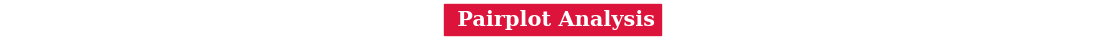

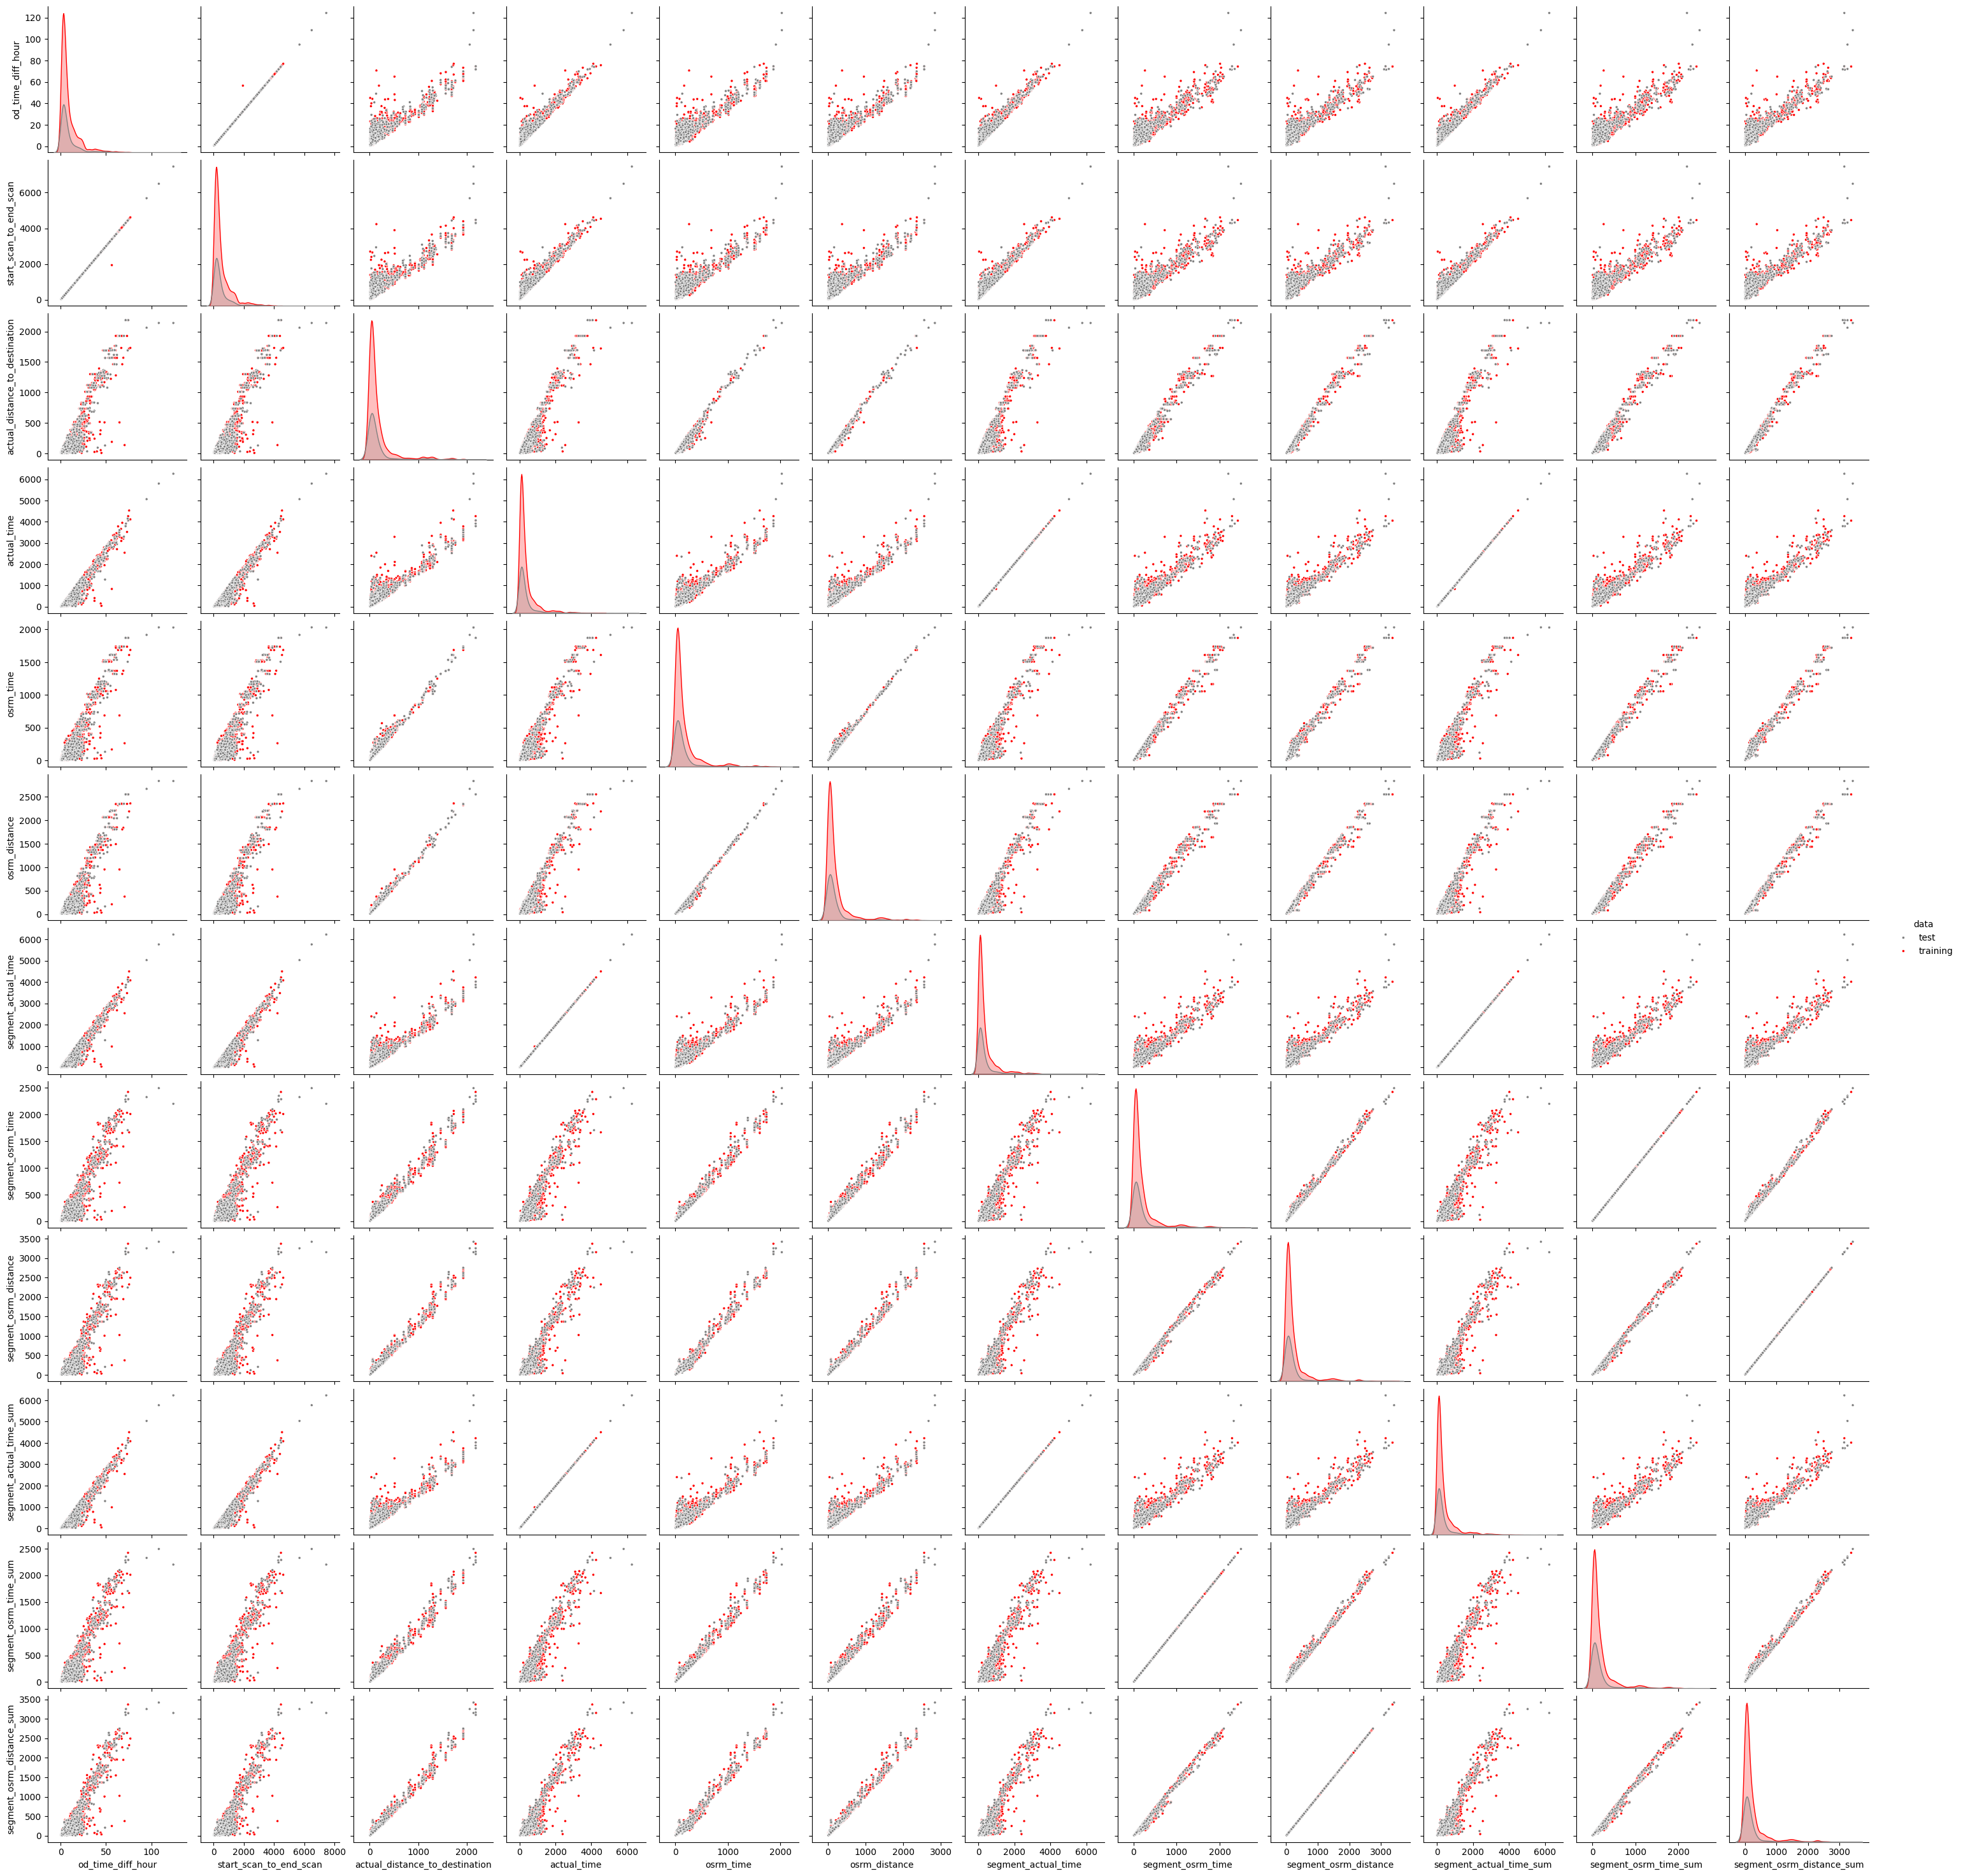

In [154]:
plt.figure(figsize=(14,0.05))
plt.axis('off')
plt.title(f' Pairplot Analysis',fontfamily='serif',fontweight='bold',fontsize=15,backgroundcolor='crimson',color='w')
sns.pairplot(data = trip_df,vars = num_cols,hue='data',markers = '.',palette=cp)
plt.show()

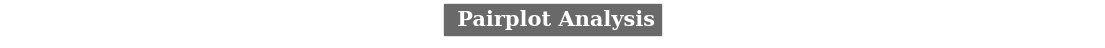

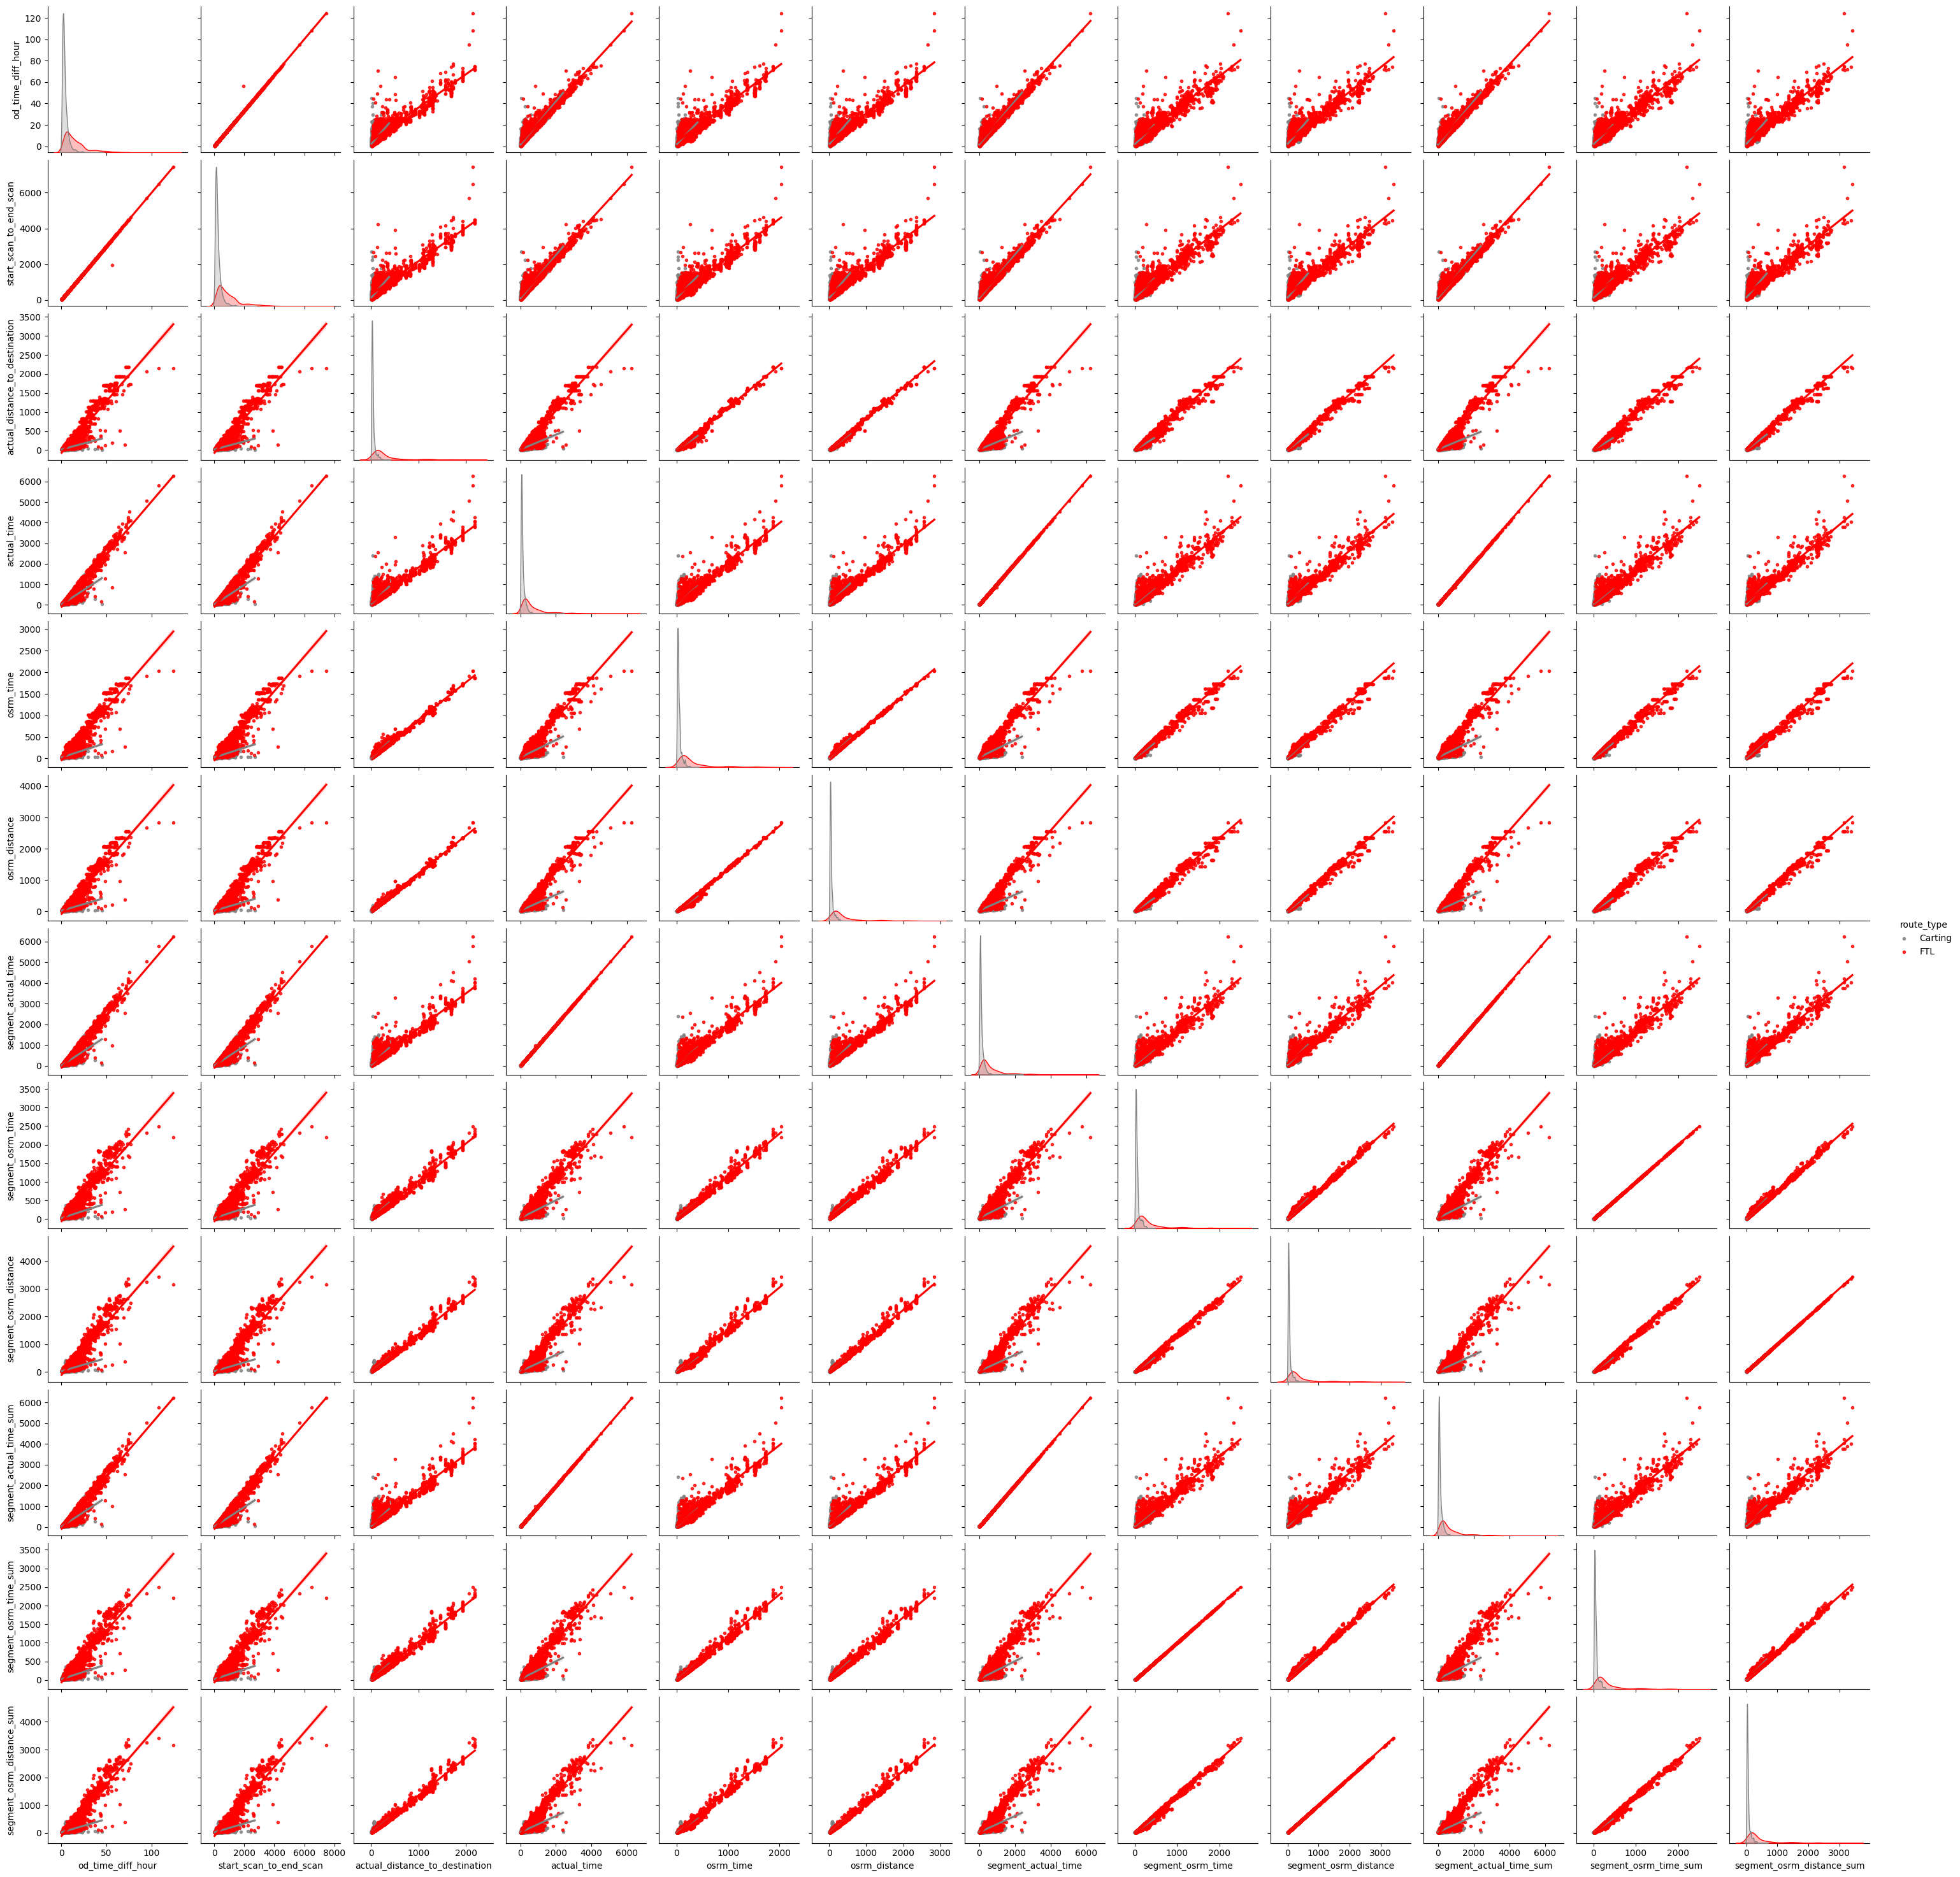

In [155]:
plt.figure(figsize=(14,0.05))
plt.axis('off')
plt.title(f' Pairplot Analysis',fontfamily='serif',fontweight='bold',fontsize=15,backgroundcolor='dimgrey',color='w')
sns.pairplot(data = trip_df,vars=num_cols,kind = 'reg',hue='route_type',markers ='.',palette=cp)
plt.show()

In [156]:
clipped_df_corr = clipped_num_df.corr()
clipped_df_corr

filtered_df_corr = filtered_num_df.corr()
filtered_df_corr

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
od_time_diff_hour,1.000000,0.999635,0.921515,0.961722,0.930250,0.927370,0.961859,0.921964,0.922661,0.961859,0.921964,0.922661
start_scan_to_end_scan,0.999635,1.000000,0.922566,0.962528,0.931298,0.928443,0.962570,0.923016,0.923726,0.962570,0.923016,0.923726
actual_distance_to_destination,0.921515,0.922566,1.000000,0.956089,0.993721,0.997402,0.955163,0.987437,0.993424,0.955163,0.987437,0.993424
actual_time,0.961722,0.962528,0.956089,1.000000,0.960683,0.961420,0.999986,0.955589,0.959261,0.999986,0.955589,0.959261
osrm_time,0.930250,0.931298,0.993721,0.960683,1.000000,0.997538,0.959862,0.993152,0.991861,0.959862,0.993152,0.991861
osrm_distance,0.927370,0.928443,0.997402,0.961420,0.997538,1.000000,0.960566,0.991602,0.994871,0.960566,0.991602,0.994871
segment_actual_time,0.961859,0.962570,0.955163,0.999986,0.959862,0.960566,1.000000,0.954762,0.958410,1.000000,0.954762,0.958410
segment_osrm_time,0.921964,0.923016,0.987437,0.955589,0.993152,0.991602,0.954762,1.000000,0.995939,0.954762,1.000000,0.995939
segment_osrm_distance,0.922661,0.923726,0.993424,0.959261,0.991861,0.994871,0.958410,0.995939,1.000000,0.958410,0.995939,1.000000
segment_actual_time_sum,0.961859,0.962570,0.955163,0.999986,0.959862,0.960566,1.000000,0.954762,0.958410,1.000000,0.954762,0.958410


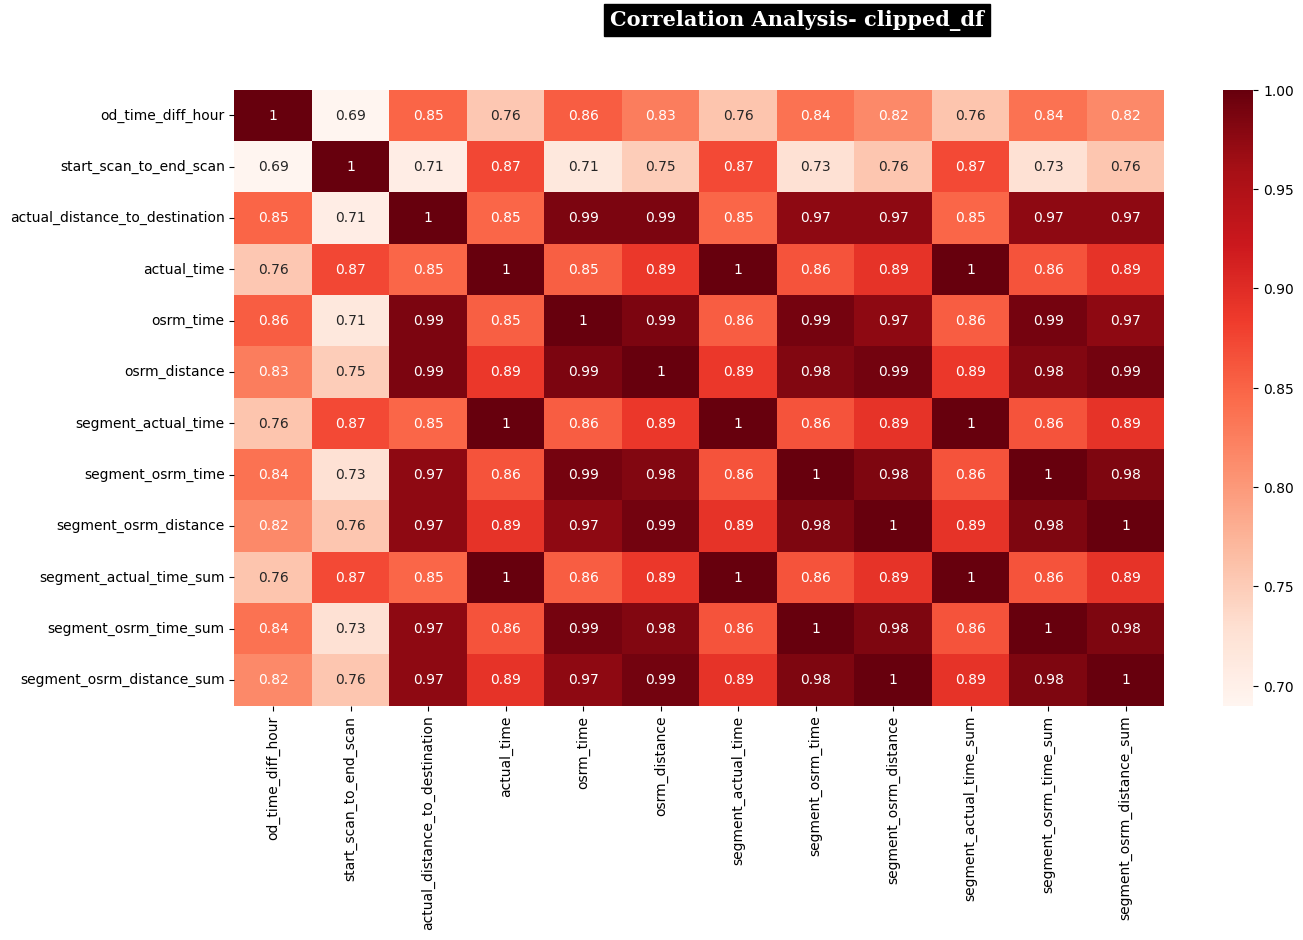

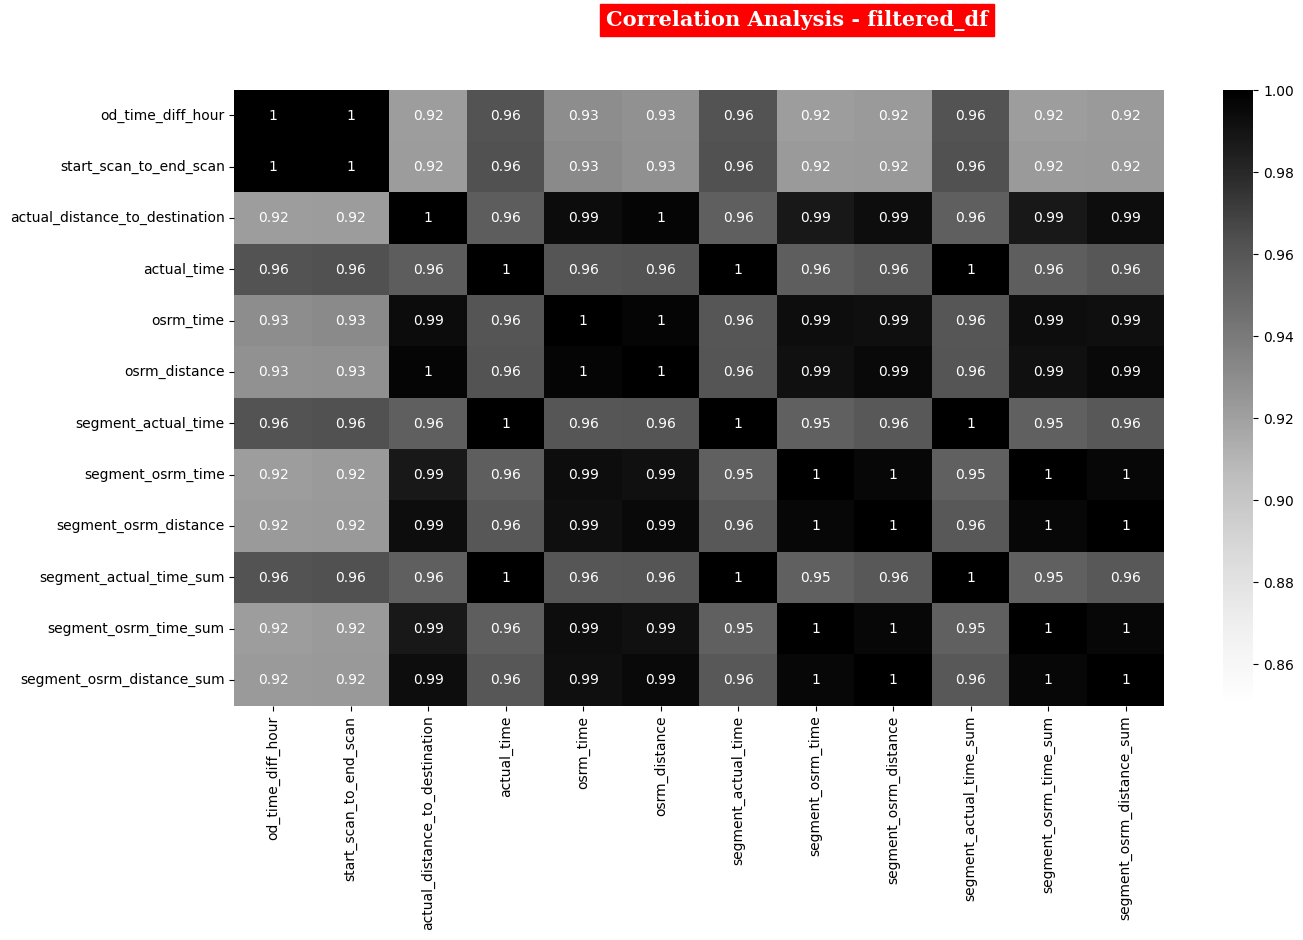

In [157]:
plt.figure(figsize = (15,8))
plt.suptitle(f'Correlation Analysis- clipped_df',fontfamily='serif',fontweight='bold',fontsize=15,backgroundcolor='k',color='w')
sns.heatmap(data = clipped_df_corr,vmin=0.69, annot = True, cmap='Reds')
plt.show()

plt.figure(figsize = (15,8))
plt.suptitle(f'Correlation Analysis - filtered_df',fontfamily='serif',fontweight='bold',fontsize=15,backgroundcolor='r',color='w')
sns.heatmap(data = filtered_df_corr,vmin=0.85, annot = True, cmap='Greys')
plt.show()

##Insights:
- Very High Correlation exists between all the numerical columns.

In [158]:
trip_df.skew(numeric_only = True)

,0
od_time_diff_hour,2.90201
trip_creation_month,2.349599
trip_creation_year,0.0
trip_creation_day,-0.693101
trip_creation_hour,-0.226291
trip_creation_weekday,0.052435
trip_creation_week,0.19133
start_scan_to_end_scan,2.903368
actual_distance_to_destination,3.524578
actual_time,3.440755


##Insights:
- We can see that Many of the data is Right-Skewed.

#One-hot encoding

In [159]:
trip_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6681 entries, 0 to 6680
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   trip_uuid                       6681 non-null   object        
 1   data                            6681 non-null   category      
 2   route_type                      6681 non-null   category      
 3   od_start_time                   6681 non-null   datetime64[ns]
 4   od_end_time                     6681 non-null   datetime64[ns]
 5   od_time_diff_hour               6681 non-null   float64       
 6   trip_creation_time              6681 non-null   datetime64[ns]
 7   trip_creation_month             6681 non-null   int32         
 8   trip_creation_year              6681 non-null   int32         
 9   trip_creation_day               6681 non-null   int32         
 10  trip_creation_hour              6681 non-null   int32         
 11  trip

In [160]:
categorical_cols = ['data','route_type']

In [163]:
# one hot encoding the categorical features
ohe = OneHotEncoder(sparse_output=False)
encoded_cat_cols = ohe.fit_transform(trip_df[categorical_cols])

categorical_encoded_df = pd.DataFrame(encoded_cat_cols, columns=ohe.get_feature_names_out(categorical_cols))
display(categorical_encoded_df)

encoded_df = pd.concat([trip_df,categorical_encoded_df],axis=1)
encoded_df

,data_test,data_training,route_type_Carting,route_type_FTL
0,0.0,1.0,1.0,0.0
1,0.0,1.0,1.0,0.0
2,0.0,1.0,1.0,0.0
3,0.0,1.0,1.0,0.0
4,0.0,1.0,0.0,1.0
...,...,...,...,...
6676,1.0,0.0,1.0,0.0
6677,1.0,0.0,1.0,0.0
6678,1.0,0.0,1.0,0.0
6679,1.0,0.0,1.0,0.0


,trip_uuid,data,route_type,od_start_time,od_end_time,od_time_diff_hour,trip_creation_time,trip_creation_month,trip_creation_year,trip_creation_day,trip_creation_hour,trip_creation_weekday,trip_creation_week,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,source_name,source_city,source_state,source_place,destination_name,destination_city,destination_state,destination_place,corridor,state_corridor,city_corridor,trip_creation_day_week,trip_creation_dayofdate,data_test,data_training,route_type_Carting,route_type_FTL
0,trip-153671074033284934,training,Carting,2018-09-12 02:31:39.246238,2018-09-12 02:01:41.638015,4.680733,2018-09-12 00:05:40.333071,9,2018,12,0,2,37,280.0,25.454847,161.0,29.0,30.935898,161.0,29.0,30.935799,161.0,29.0,30.935799,Surat_Central_D_12 (Gujarat),Surat,Gujarat,Central_D_12,Surat_Central_I_4 (Gujarat),Surat,Gujarat,Central_I_4,Surat_Central_D_12 (Gujarat) <---> Surat_Centr...,Gujarat--Surat <---> Gujarat--Surat,Surat--Central_D_12 <---> Surat--Central_I_4,Wednesday,12,0.0,1.0,1.0,0.0
1,trip-153671079956500691,training,Carting,2018-09-12 00:06:39.565253,2018-09-12 00:55:59.568645,0.822223,2018-09-12 00:06:39.565253,9,2018,12,0,2,37,49.0,9.872146,23.0,8.0,9.956600,23.0,14.0,16.085999,23.0,14.0,16.085999,Delhi_Lajpat_IP (Delhi),Delhi,Delhi,Lajpat_IP,Delhi_Bhogal (Delhi),Delhi,Delhi,Bhogal,Delhi_Lajpat_IP (Delhi) <---> Delhi_Bhogal (De...,Delhi--Delhi <---> Delhi--Delhi,Delhi--Lajpat_IP <---> Delhi--Bhogal,Wednesday,12,0.0,1.0,1.0,0.0
2,trip-153671110078355292,training,Carting,2018-09-12 00:11:40.783923,2018-09-12 00:50:10.814399,0.641675,2018-09-12 00:11:40.783923,9,2018,12,0,2,37,38.0,9.396525,17.0,9.0,10.815900,17.0,9.0,10.815900,17.0,9.0,10.815900,FBD_Balabhgarh_DPC (Haryana),FBD,Haryana,Balabhgarh_DPC,Faridabad (Haryana),Faridabad,Haryana,Faridabad,FBD_Balabhgarh_DPC (Haryana) <---> Faridabad (...,Haryana--FBD <---> Haryana--Faridabad,FBD--Balabhgarh_DPC <---> Faridabad--Faridabad,Wednesday,12,0.0,1.0,1.0,0.0
3,trip-153671127071609610,training,Carting,2018-09-12 00:14:30.716368,2018-09-12 07:54:13.838441,15.511243,2018-09-12 00:14:30.716368,9,2018,12,0,2,37,928.0,230.413864,561.0,253.0,284.458191,554.0,258.0,293.844696,554.0,258.0,293.844696,Gulbarga_Nehrugnj_I (Karnataka),Gulbarga,Karnataka,Nehrugnj_I,Sindagi_KalyanNg_D (Karnataka),Sindagi,Karnataka,KalyanNg_D,Gulbarga_Nehrugnj_I (Karnataka) <---> Sindagi_...,Karnataka--Gulbarga <---> Karnataka--Sindagi,Gulbarga--Nehrugnj_I <---> Sindagi--KalyanNg_D,Wednesday,12,0.0,1.0,1.0,0.0
4,trip-153671191949943656,training,FTL,2018-09-12 04:33:09.726898,2018-09-12 09:23:49.463096,4.844371,2018-09-12 00:25:19.499696,9,2018,12,0,2,37,290.0,99.975594,253.0,105.0,124.506302,252.0,132.0,140.562302,252.0,132.0,140.562302,Narsinghpur_KndliDPP_D (Madhya Pradesh),Narsinghpur,Madhya Pradesh,KndliDPP_D,Gadarwara_MPward_D (Madhya Pradesh),Gadarwara,Madhya Pradesh,MPward_D,Narsinghpur_KndliDPP_D (Madhya Pradesh) <---> ...,Madhya Pradesh--Narsinghpur <---> Madhya Prade...,Narsinghpur--KndliDPP_D <---> Gadarwara--MPward_D,Wednesday,12,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6676,trip-153861089559302126,test,Carting,2018-10-03 23:54:55.593290,2018-10-04 03:46:15.195842,3.126754,2018-10-03 23:54:55.593290,10,2018,3,23,2,40,186.0,28.114090,86.0,30.0,34.922401,86.0,30.0,34.922298,86.0,30.0,34.922298,Mumbai_East_I_21 (Maharashtra),Mumbai,Maharashtra,East_I_21,Mumbai_Ulhasngr_DC (Maharashtra),Mumbai,Maharashtra,Ulhasngr_DC,Mumbai_East_I_21 (Maharashtra) <---> Mumbai_Ul...,Maharashtra--Mumbai <---> Maharashtra--Mumbai,Mumbai--East_I_21 <---> Mumbai--Ulhasngr_DC,Wednesday,3,1.0,0.0,1.0,0.0
6677,trip-153861089872028474,test,Carting,2018-10-03 23:54:58.720536,2018-10-04 02:57:23.7

#0-1 Minmax scaler
- Most appropriate since the data is not gaussian

In [164]:
# Normalizing/Standardizing the numerical features using MinMaxScaler
min_max_scaler = MinMaxScaler()
min_max_scaled_numerical = min_max_scaler.fit_transform(trip_df[num_cols])

# Converting the scaled features back to a dataframe
min_max_scaled_df = pd.DataFrame(min_max_scaled_numerical, columns=num_cols)
min_max_scaled_df

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,0.034052,0.034047,0.007559,0.024297,0.011352,0.007724,0.024433,0.009244,0.006413,0.024433,0.009244,0.006413
1,0.002898,0.002961,0.000399,0.002238,0.000987,0.000312,0.002250,0.003215,0.002057,0.002250,0.003215,0.002057
2,0.001440,0.001480,0.000181,0.001279,0.001481,0.000616,0.001286,0.001206,0.000511,0.001286,0.001206,0.000511
3,0.121499,0.121249,0.101729,0.088235,0.121915,0.097289,0.087606,0.101286,0.083533,0.087606,0.101286,0.083533
4,0.035373,0.035392,0.041798,0.039003,0.048865,0.040781,0.039061,0.050643,0.038570,0.039061,0.050643,0.038570
...,...,...,...,...,...,...,...,...,...,...,...,...
6676,0.021505,0.021397,0.008780,0.012308,0.011846,0.009132,0.012377,0.009646,0.007582,0.012377,0.009646,0.007582
6677,0.020807,0.020724,0.008274,0.008472,0.010859,0.010321,0.008359,0.010852,0.007206,0.008359,0.010852,0.007206
6678,0.030982,0.030951,0.022403,0.011829,0.027641,0.022748,0.011734,0.022508,0.016363,0.011734,0.022508,0.016363
6679,0.053063,0.053021,0.013637,0.043638,0.020731,0.017604,0.043723,0.032958,0.028105,0.043723,0.032958,0.028105


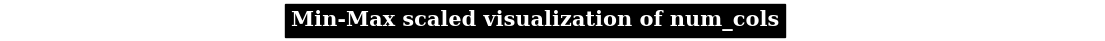

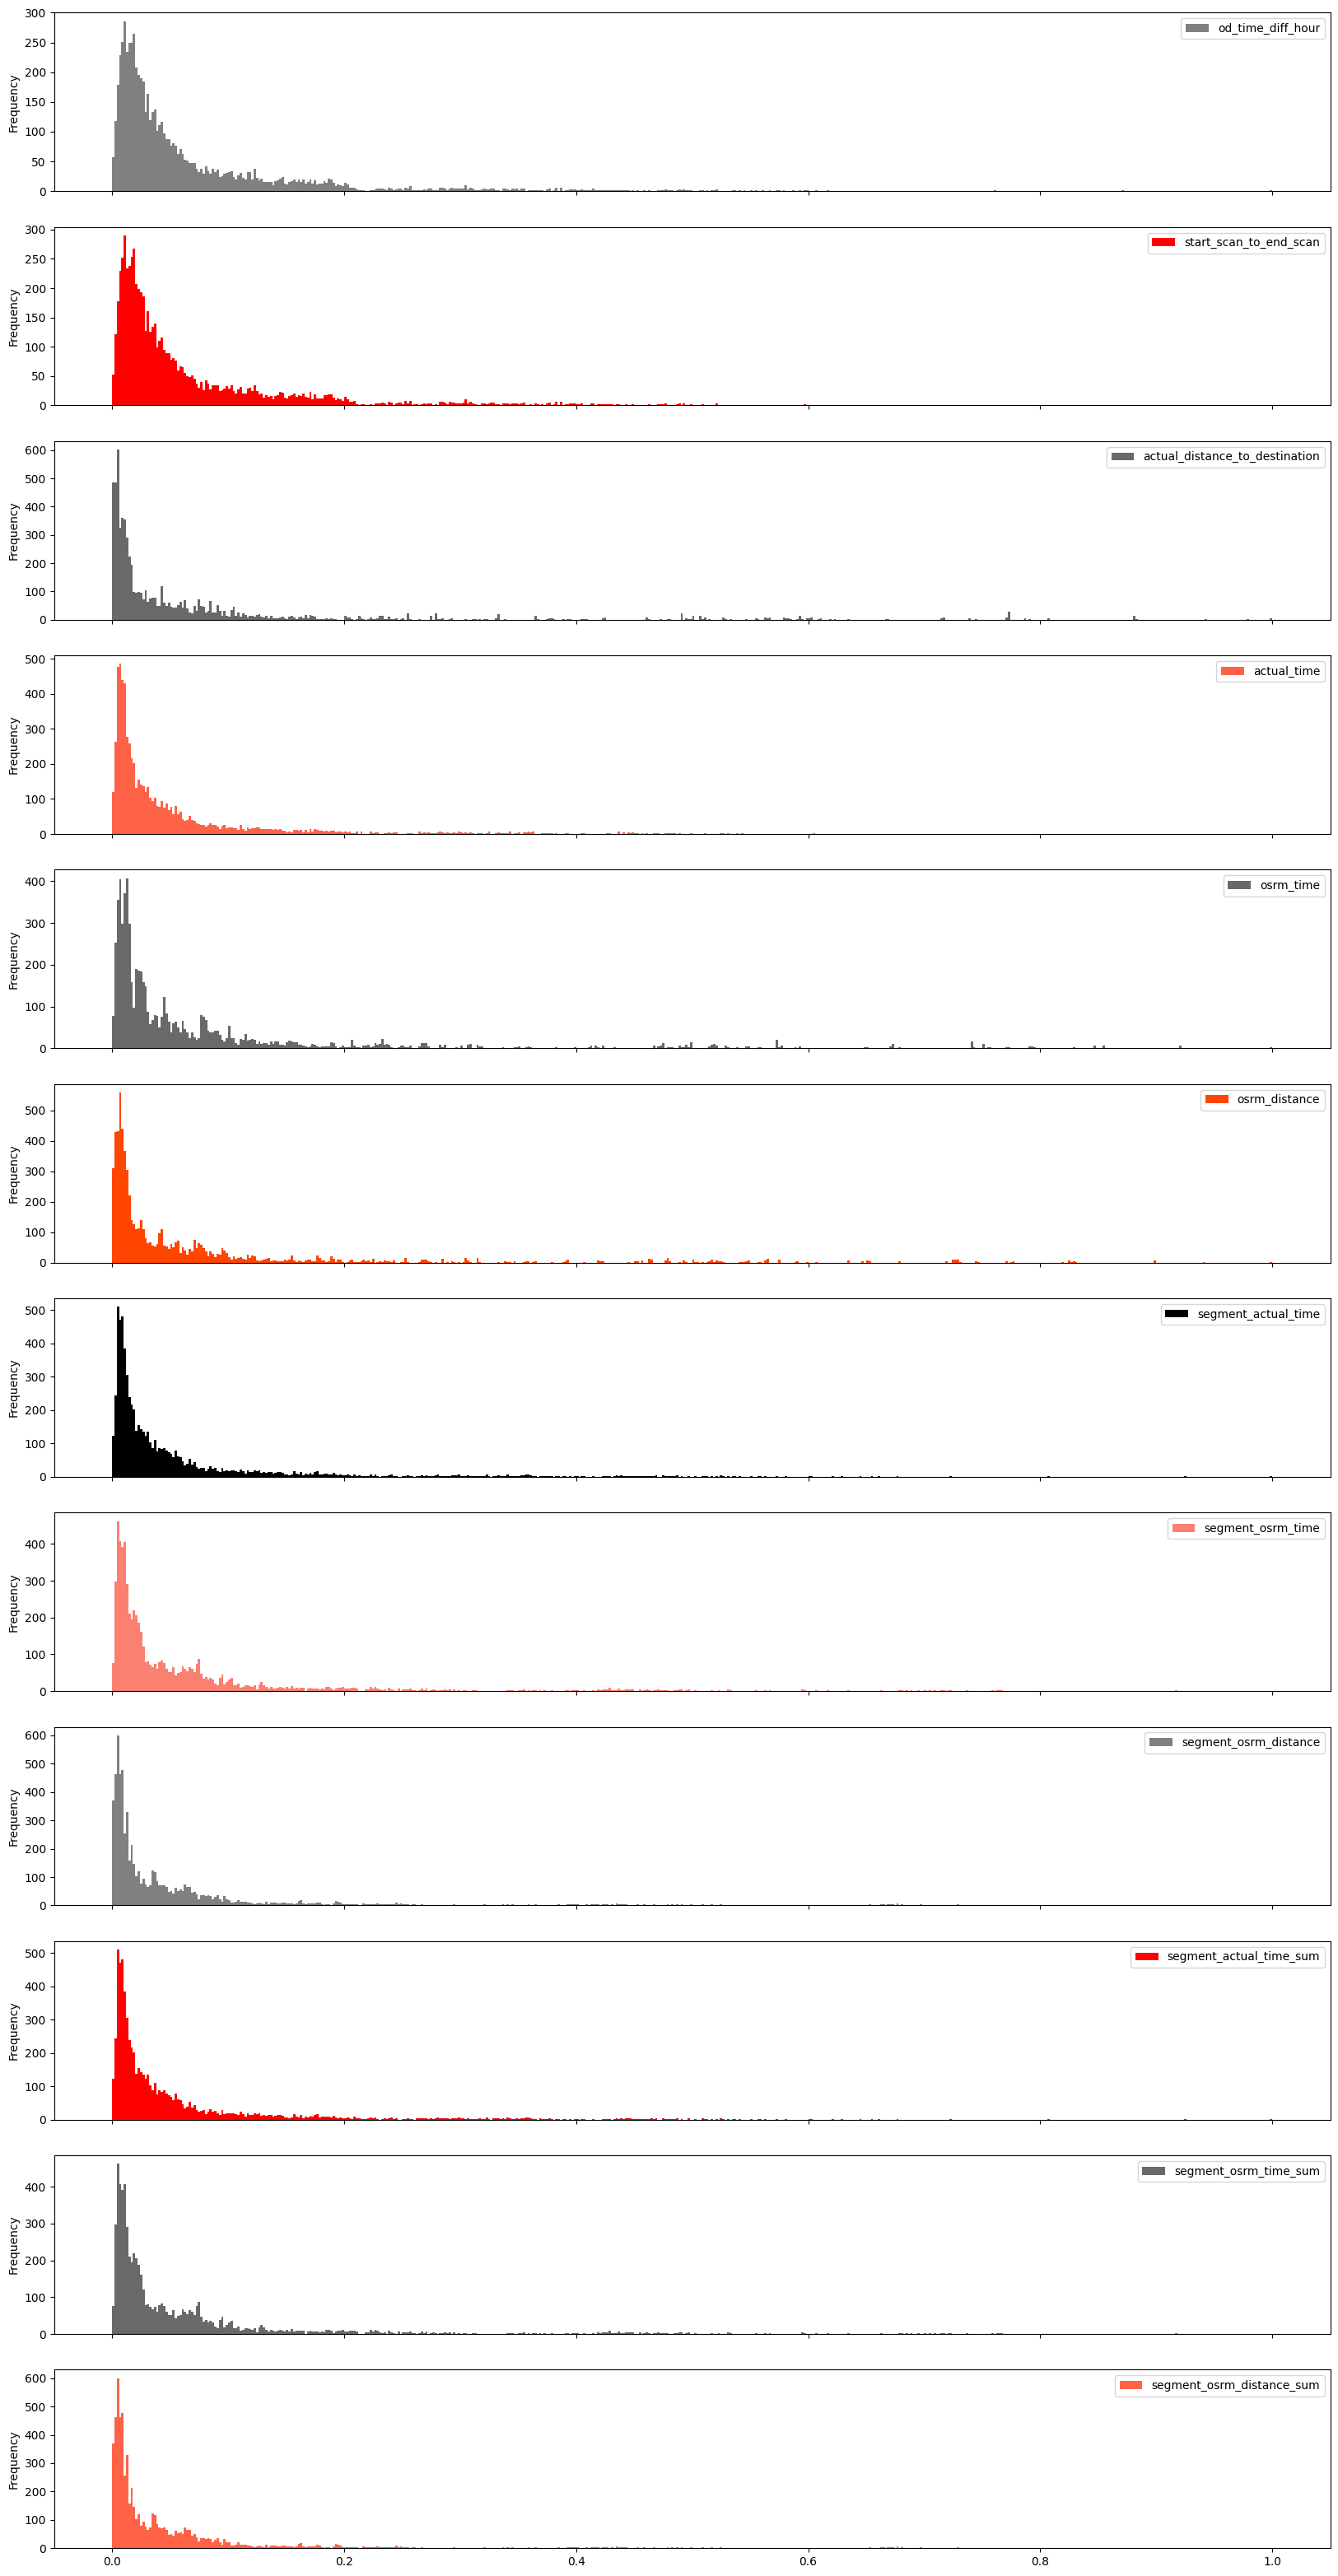

In [165]:
plt.figure(figsize=(14,0.05))
plt.axis('off')
plt.suptitle(f'Min-Max scaled visualization of num_cols',fontfamily='serif',fontweight='bold',fontsize=15,backgroundcolor='k',color='w')
min_max_scaled_df.plot(kind='hist', figsize=(20,40),subplots=True,color=cp,bins=500)
plt.show()

In [166]:
# Just so to know ... cant do this as `data is not gaussian`
# Standardization works only with data which follows normal distribution
# Standardizing the numerical features using StandardScaler
std_scaler = StandardScaler()
std_scaled = std_scaler.fit_transform(trip_df[num_cols])

# Converting the scaled features back to a dataframe
std_scaled_df = pd.DataFrame(std_scaled, columns=num_cols)
std_scaled_df

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
0,-0.378107,-0.378217,-0.457758,-0.347948,-0.489734,-0.469870,-0.345289,-0.486790,-0.464849,-0.345289,-0.486790,-0.464849
1,-0.731563,-0.731362,-0.509155,-0.595174,-0.567568,-0.526825,-0.594793,-0.535022,-0.500893,-0.594793,-0.535022,-0.500893
2,-0.748102,-0.748178,-0.510724,-0.605923,-0.563861,-0.524492,-0.605641,-0.551099,-0.513685,-0.605641,-0.551099,-0.513685
3,0.614015,0.612422,0.218272,0.368649,0.340487,0.218388,0.365253,0.249547,0.173298,0.365253,0.249547,0.173298
4,-0.363117,-0.362930,-0.211961,-0.183130,-0.208052,-0.215847,-0.180762,-0.155599,-0.198757,-0.180762,-0.155599,-0.198757
...,...,...,...,...,...,...,...,...,...,...,...,...
6676,-0.520458,-0.521921,-0.448986,-0.482310,-0.486028,-0.459048,-0.480889,-0.483575,-0.455173,-0.480889,-0.483575,-0.455173
6677,-0.528380,-0.529565,-0.452625,-0.525305,-0.493441,-0.449915,-0.526089,-0.473928,-0.458285,-0.526089,-0.473928,-0.458285
6678,-0.412940,-0.413379,-0.351196,-0.487684,-0.367425,-0.354418,-0.488121,-0.380680,-0.382518,-0.488121,-0.380680,-0.382518
6679,-0.162416,-0.162661,-0.414120,-0.131177,-0.419314,-0.393944,-0.128330,-0.297079,-0.285351,-0.128330,-0.297079,-0.285351


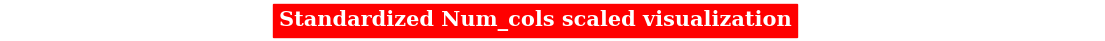

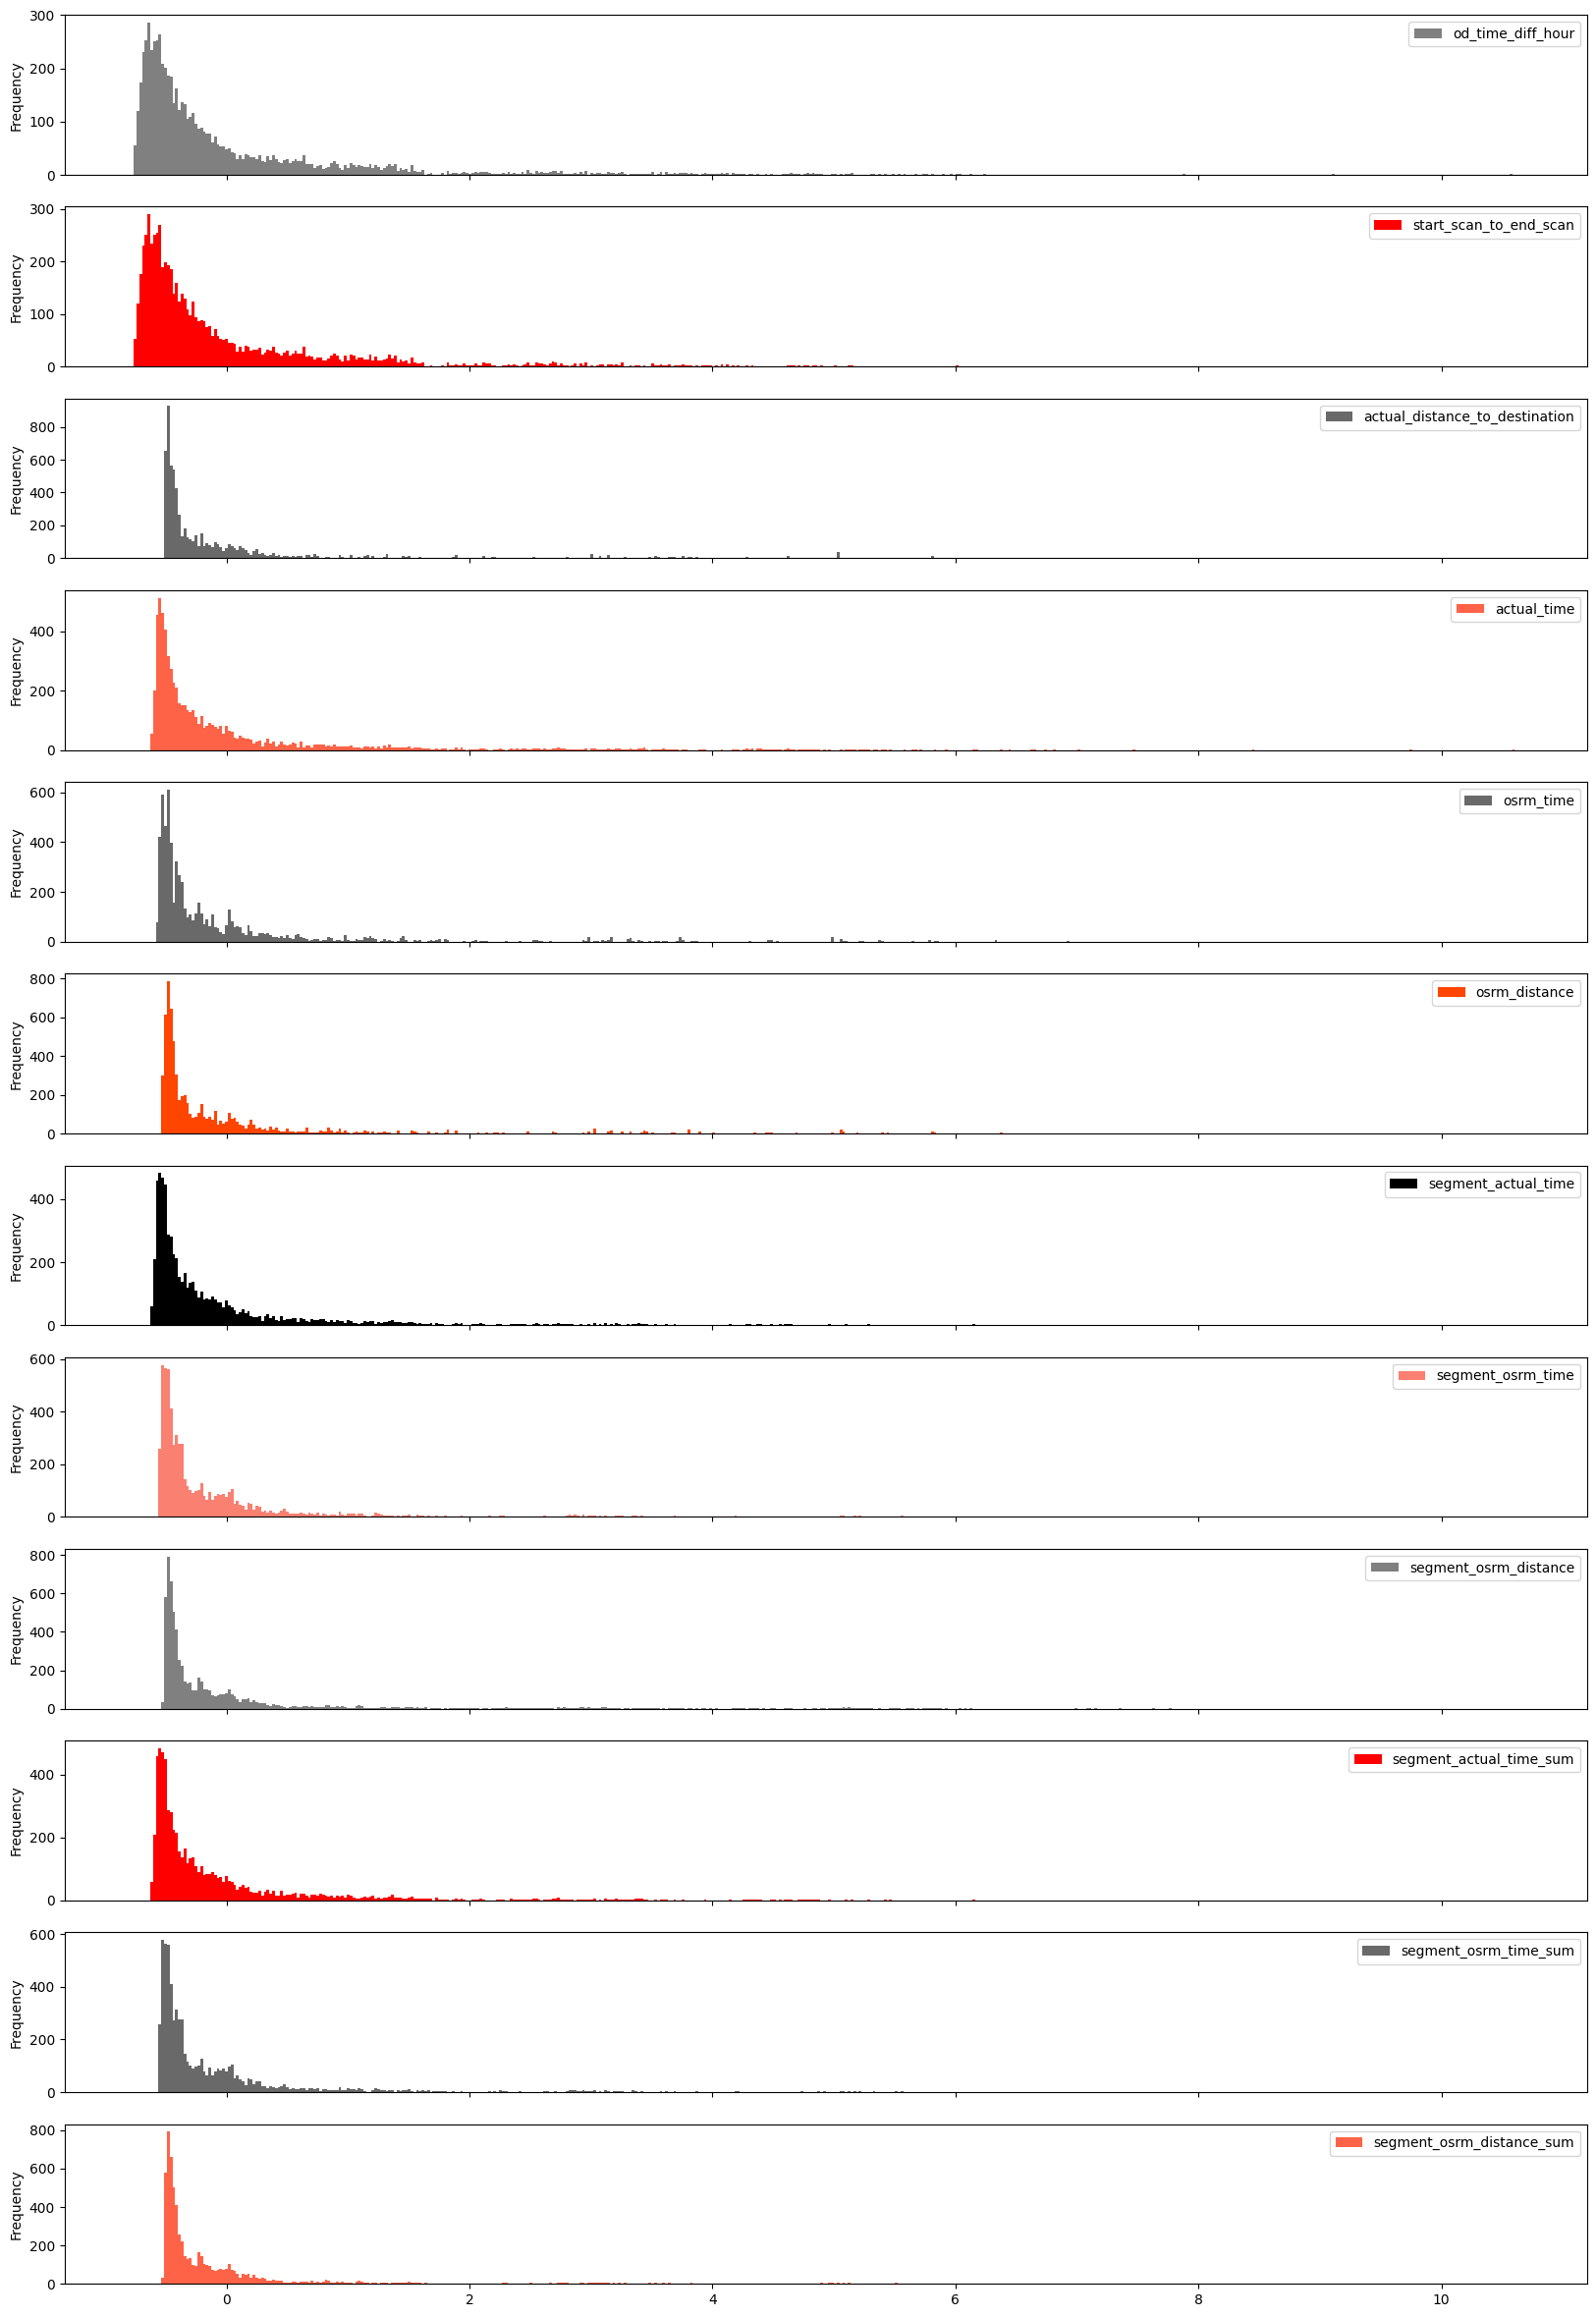

In [167]:
plt.figure(figsize=(14,0.05))
plt.axis('off')
plt.suptitle(f'Standardized Num_cols scaled visualization',fontfamily='serif',fontweight='bold',fontsize=15,backgroundcolor='r',color='w')
std_scaled_df.plot(kind='hist', figsize=(20,30),subplots=True,color=cp,bins=500)
plt.show()

#Hypothesis Testing:
- Perform hypothesis testing / visual analysis between :
⚡ actual_time aggregated value and OSRM time aggregated value.

⚡ actual_time aggregated value and segment actual time aggregated value.

⚡ OSRM distance aggregated value and segment OSRM distance aggregated value.

⚡ OSRM time aggregated value and segment OSRM time aggregated value.

- Note: Aggregated values are the values you’ll get after merging the rows on the basis of trip_uuid.

##Assumptions of T-Test
1. The sample size should be less than 30.
2. The population variance is unknown.
3. The population mean and standard deviation are finite.
4. The means of the two populations being compared should follow normal distributions.
5. If using Student's original definition of the t-test, the two populations being compared should have the same variance. If the sample sizes in the two groups being compared are equal, Student's original t-test is highly robust to the presence of unequal variances.

## STEP-1 : Set up Null Hypothesis

- Null Hypothesis ( Ho ) - There is no significant difference in the mean values between column1 and column2
- Alternate Hypothesis ( Ha ) - There is a significant difference in the mean values between column1 and column2

##STEP-2 : Checking for basic assumpitons for the hypothesis

- Distribution check using QQ Plot & prob Plot

- Confirmation by Shapiro-wilks Test

- Confirmation by Anderson-darling Test

- Homogeneity of Variances using Levene's test

*Normality checks*

##STEP-3: Define Test statistics; Distribution of T under Ho.

- We know that the test statistic while performing a T-Test follows T-distribution.

>>**for independent variables:**
>>If data follows normal distribution we go with ttest_ind
>> Else we will go with Mannwhitney_u test (Non - Parametric test)

>>**for dependent variables:** (paired T-test)
>>If data follows normal distribution we go with ttest_rel
>>Else we will go with Wilcoxon signed rank test (Non - Parametric test)

##STEP-4: Decide the kind of test.

- We will be performing Two tailed t-test

##STEP-5: Compute the p-value and fix value of alpha.

- we will be computing the t-stat value using the ttest function using scipy.stats.
- We set our alpha to be 0.05 (i.e) confidence level = 95%

##STEP-6: Compare p-value and alpha.

- Based on p-value, we will accept or reject H0.

>p-val < alpha : Reject Ho

>p-val > alpha : Accept Ho

In [168]:
class Normality_check:
    def __init__(self, name, col):
        self.name = name
        self.col = col

    def shapiro_and_anderson(self):
        print(f"Performing SHAPIRO & ANDERSON-DARLING TEST for {self.name} column")
        print()

        # Shapiro-Wilk Test
        print('Shapiro-Wilk Test')
        shapiro_stat, p_val = shapiro(self.col)
        if p_val < 0.05:
            print(f'{self.name} - Data is not Gaussian')
        else:
            print(f'{self.name} - Data is Gaussian')
        print()

        # Using Anderson-Darling Test
        print("Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test")
        result = anderson(self.col)
        if result.statistic > result.critical_values[2]:
            print(f"{self.name} - Data does not follow a normal distribution.")
        else:
            print(f"{self.name} - Data follows a normal distribution.")
        print()
        print('-'*50)

    def boxcox_transformation(self):
        print(f'Performing BOXCOX transformation on {self.name} column')
        transformed_data, best_lambda = boxcox(self.col)
        self.col = transformed_data  # Update column data with transformed data
        self.shapiro_and_anderson()  # Calling shapiro_and_anderson method after transformation

In [169]:
def levene_test(name1,name2,col1,col2):

    levene_stat, p_value = levene(col1,col2)

    print(f'Performing Levene Test for {name1} & {name2}')

    if p_value < 0.05:
        print('Does not have Homogenous (different) Variance')
    else:
        print('Have Homogenous (similar) variance')
    print()
    print('-'*50)
    print()
    return ""

In [170]:
## MannWhitney u Rank test
### Test statistics : Mann-Whitney U rank test for two independent samples

def mannwhitneyu_test(name1,name2,col1,col2):

    print(f'Performing Non-parametric Test - MannWhitneyU for {name1} & {name2}')
    test_stat, p_value = mannwhitneyu(col1,col2)

    if p_value < 0.05:
        print("Reject Null Hypothesis")
        print(f'There is a significant difference in the Mean values of {name1} and {name2}')
    else:
        print("Failed to Reject Null Hypothesis - Accept Ho")
        print(f'There is NO significant difference in the Mean values of {name1} and {name2}')

    print()
    print('-'*50)
    print()

    return ""

In [171]:
def normality_plots(name1,name2,name3,name4,col1,col2,col3,col4):

    plt.figure(figsize = (20,10))
    plt.suptitle("Normality check - Histplot & QQ(prob)plot",fontsize=16,fontweight="bold",backgroundcolor=cp[5],color='w')

    plt.subplot(241)
    sns.histplot(col1, element = 'step', color =cp[1], kde = True, label = name1)
    plt.title(f'Histplot - {name1}',fontsize=10,fontweight="bold",backgroundcolor=cp[1],color='w')
    plt.legend()

    plt.subplot(242)
    sns.histplot(col3,element = 'step', color = cp[2], kde = True, label = name3 )
    plt.title(f'Histplot - {name3}',fontsize=10,fontweight="bold",backgroundcolor=cp[2],color='w')
    plt.legend()

    plt.subplot(243)
    probplot(col1, plot = plt, dist = 'norm')
    plt.title(f'Probplot - {name1}',fontsize=10,fontweight="bold",backgroundcolor=cp[1],color='w')

    plt.subplot(244)
    probplot(col3, plot = plt, dist = 'norm')
    plt.title(f'Probplot - {name3}',fontsize=10,fontweight="bold",backgroundcolor=cp[2],color='w')

    plt.subplot(245)
    sns.histplot(col2, element = 'step', color =cp[1], kde = True, label = name2 )
    plt.title(f'Histplot - {name2}',fontsize=10,fontweight="bold",backgroundcolor=cp[1],color='w')
    plt.legend()

    plt.subplot(246)
    sns.histplot(col4,element = 'step', color = cp[2], kde = True, label = name4)
    plt.title(f'Histplot - {name4}',fontsize=10,fontweight="bold",backgroundcolor=cp[2],color='w')
    plt.legend()

    plt.subplot(247)
    probplot(col2, plot = plt, dist = 'norm')
    plt.title(f'Probplot - {name2}',fontsize=10,fontweight="bold",backgroundcolor=cp[1],color='w')

    plt.subplot(248)
    probplot(col4, plot = plt, dist = 'norm')
    plt.title(f'Probplot - {name4}',fontsize=10,fontweight="bold",backgroundcolor=cp[2],color='w')

    sns.despine()
    plt.show()

#Hypothesis testing - actual_time aggregated value and OSRM time aggregated value.

In [172]:
clipped_num_df.sample(3)

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
4538,5.482108,328.000000,16.044252,54.0,21.0,21.236401,53.0,20.0,21.236401,53.0,20.0,21.236401
2868,12.759610,543.225452,251.865570,490.0,251.0,306.390594,486.0,247.0,306.390503,486.0,247.0,306.390503
3059,3.617501,217.000000,15.710053,78.0,17.0,17.761999,78.0,18.0,24.193501,78.0,18.0,24.193501


In [173]:
clipped_num_df[['actual_time','osrm_time']].describe().T

,count,mean,std,min,25%,50%,75%,max
actual_time,6681.0,224.390136,185.341363,9.0,68.0,150.0,364.0,543.225452
osrm_time,6681.0,128.789523,151.099345,6.0,30.0,60.0,167.0,543.225452


In [174]:
filtered_num_df[['actual_time','osrm_time']].describe().T

,count,mean,std,min,25%,50%,75%,max
actual_time,6681.0,355.222260,558.235168,9.0,68.0,150.0,364.0,6265.0
osrm_time,6681.0,161.133957,269.826721,6.0,30.0,60.0,167.0,2032.0


In [175]:
actual_time = clipped_num_df['actual_time']
osrm_time = clipped_num_df['osrm_time']
fil_actual_time = filtered_num_df['actual_time']
fil_osrm_time = filtered_num_df['osrm_time']

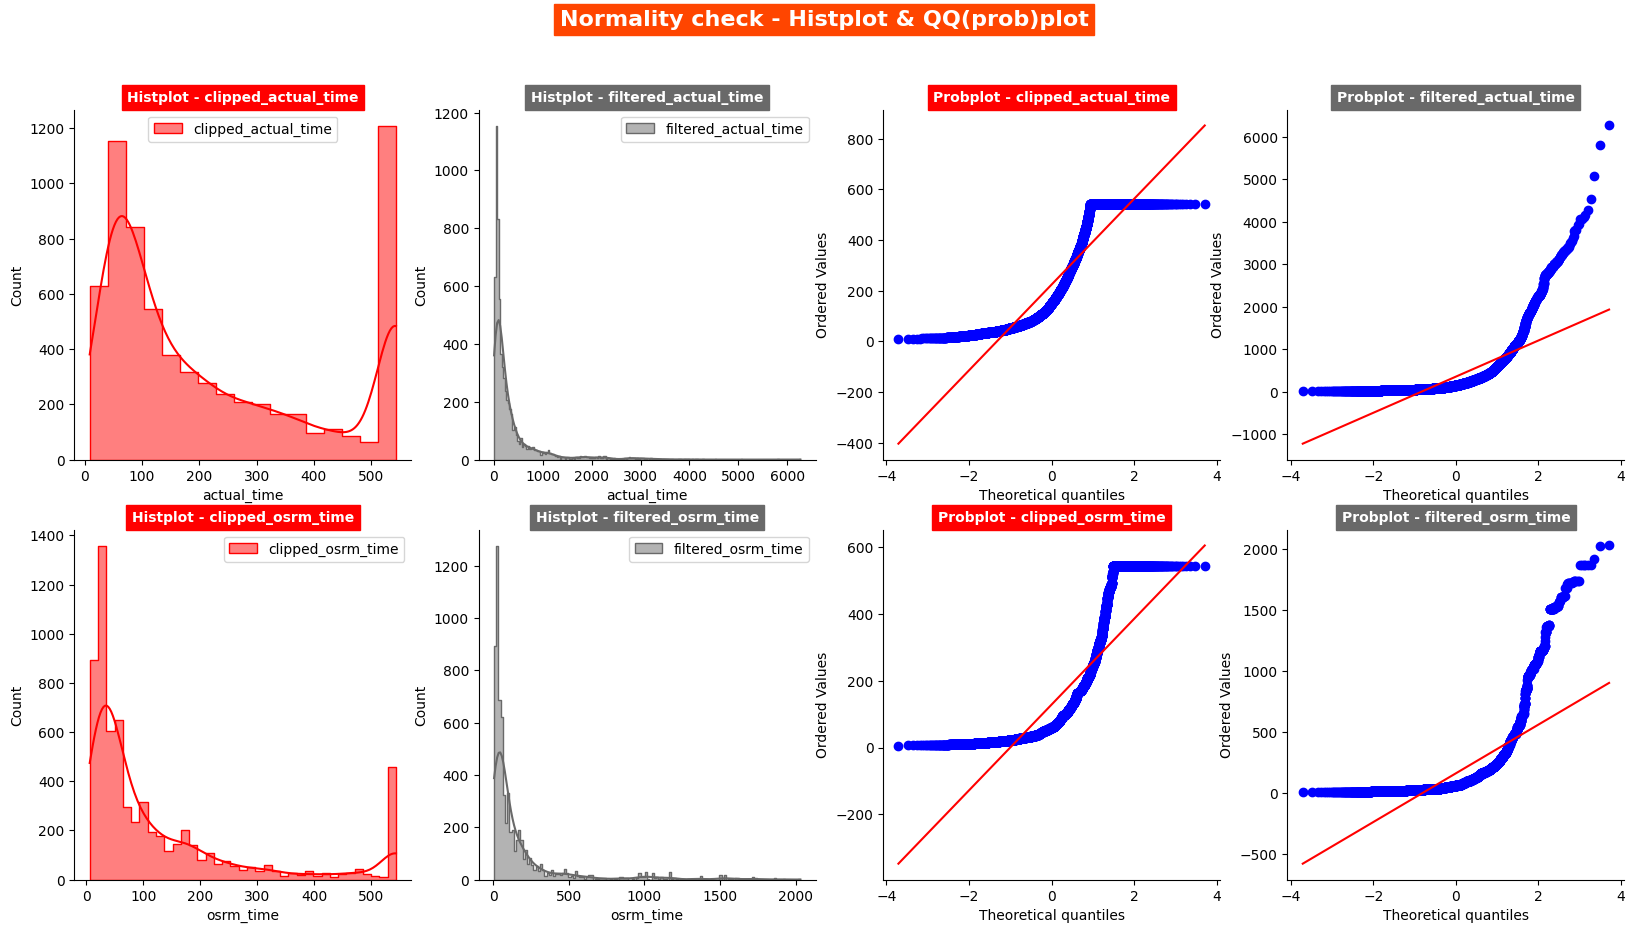

In [176]:
normality_plots('clipped_actual_time','clipped_osrm_time','filtered_actual_time','filtered_osrm_time',actual_time,osrm_time,fil_actual_time,fil_osrm_time)

In [177]:
col_names= ['clipped_actual_time','clipped_osrm_time','filtered_actual_time','filtered_osrm_time']
cols = [actual_time,osrm_time,fil_actual_time,fil_osrm_time]

for _ in zip(col_names,cols):
    normality = Normality_check(_[0],_[1])
    normality.shapiro_and_anderson()
    normality.boxcox_transformation()

Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_actual_time column

Shapiro-Wilk Test
clipped_actual_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_actual_time - Data does not follow a normal distribution.

--------------------------------------------------
Performing BOXCOX transformation on clipped_actual_time column
Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_actual_time column

Shapiro-Wilk Test
clipped_actual_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_actual_time - Data does not follow a normal distribution.

--------------------------------------------------
Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_osrm_time column

Shapiro-Wilk Test
clipped_osrm_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_osrm_time - Data does not follow a normal distribution.

----------------

In [178]:
levene_test('clipped_actual_time','clipped_osrm_time',actual_time,osrm_time),
levene_test('filtered_actual_time','filtered_osrm_time',fil_actual_time,fil_osrm_time)

Performing Levene Test for clipped_actual_time & clipped_osrm_time
Does not have Homogenous (different) Variance

--------------------------------------------------

Performing Levene Test for filtered_actual_time & filtered_osrm_time
Does not have Homogenous (different) Variance

--------------------------------------------------



''

##Wilcoxon signed rank test:

In [179]:
## with clipped data

# H0 : aggregated actual time is same as aggregated osrm time
# Ha : aggregated actual time is more than the aggregated osrm time

alpha = 0.05  #testing at 95% confidence

test_stat , p_value = wilcoxon(actual_time,osrm_time,alternative='greater')

if p_value < alpha:
    print("Reject Null Hypothesis - The Aggregated Actual_time is More than the Aggregated OSRM_time")
else:
    print("Fail to Reject Null Hypothesis - The Aggregated Actual_time is same as the Aggregated OSRM_time")

Reject Null Hypothesis - The Aggregated Actual_time is More than the Aggregated OSRM_time


In [180]:
## with filtered data

alpha = 0.05  #testing at 95% confidence

test_stat , p_value = wilcoxon(fil_actual_time,fil_osrm_time,alternative='greater')

if p_value < alpha:
    print("Reject Null Hypothesis - The Aggregated Actual_time is More than the Aggregated OSRM_time")
else:
    print("Fail to Reject Null Hypothesis - The Aggregated Actual_time is same as the Aggregated OSRM_time")

Reject Null Hypothesis - The Aggregated Actual_time is More than the Aggregated OSRM_time


In [181]:
### MannWhitney u Rank test

test_cols = [('clipped_actual_time','clipped_osrm_time',actual_time,osrm_time),
       ('filtered_actual_time','filtered_osrm_time',fil_actual_time,fil_osrm_time)]

for _ in test_cols:
    mannwhitneyu_test(_[0],_[1],_[2],_[3])

Performing Non-parametric Test - MannWhitneyU for clipped_actual_time & clipped_osrm_time
Reject Null Hypothesis
There is a significant difference in the Mean values of clipped_actual_time and clipped_osrm_time

--------------------------------------------------

Performing Non-parametric Test - MannWhitneyU for filtered_actual_time & filtered_osrm_time
Reject Null Hypothesis
There is a significant difference in the Mean values of filtered_actual_time and filtered_osrm_time

--------------------------------------------------



##Insights:
- It is confirmed that There is a significant difference in the Mean values of Aggregated actual_time and Aggregated osrm_time through MannwhitneyU test.

- Further, it is found that The Aggregated Actual_time is More than the Aggregated OSRM_time through Wilcoxon signed Rank test.

#Actual_time aggregated value and Segment actual time aggregated value.

In [182]:
clipped_num_df.sample()

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
2605,3.488799,209.0,51.477287,132.0,85.0,104.080498,132.0,120.0,106.717201,132.0,120.0,106.717201


In [183]:
clipped_num_df[['actual_time','segment_actual_time']].describe().T

,count,mean,std,min,25%,50%,75%,max
actual_time,6681.0,224.390136,185.341363,9.0,68.0,150.0,364.0,543.225452
segment_actual_time,6681.0,223.085483,185.229595,9.0,67.0,148.0,361.0,543.225452


In [184]:
filtered_num_df[['actual_time','segment_actual_time']].describe().T

,count,mean,std,min,25%,50%,75%,max
actual_time,6681.0,355.222260,558.235168,9.0,68.0,150.0,364.0,6265.0
segment_actual_time,6681.0,351.979034,553.138428,9.0,67.0,148.0,361.0,6230.0


In [185]:
clipped_actual_time = clipped_num_df['actual_time']
clipped_segmented_actual_time = clipped_num_df['segment_actual_time']
filtered_actual_time = filtered_num_df['actual_time']
filtered_segmented_actual_time = filtered_num_df['segment_actual_time']

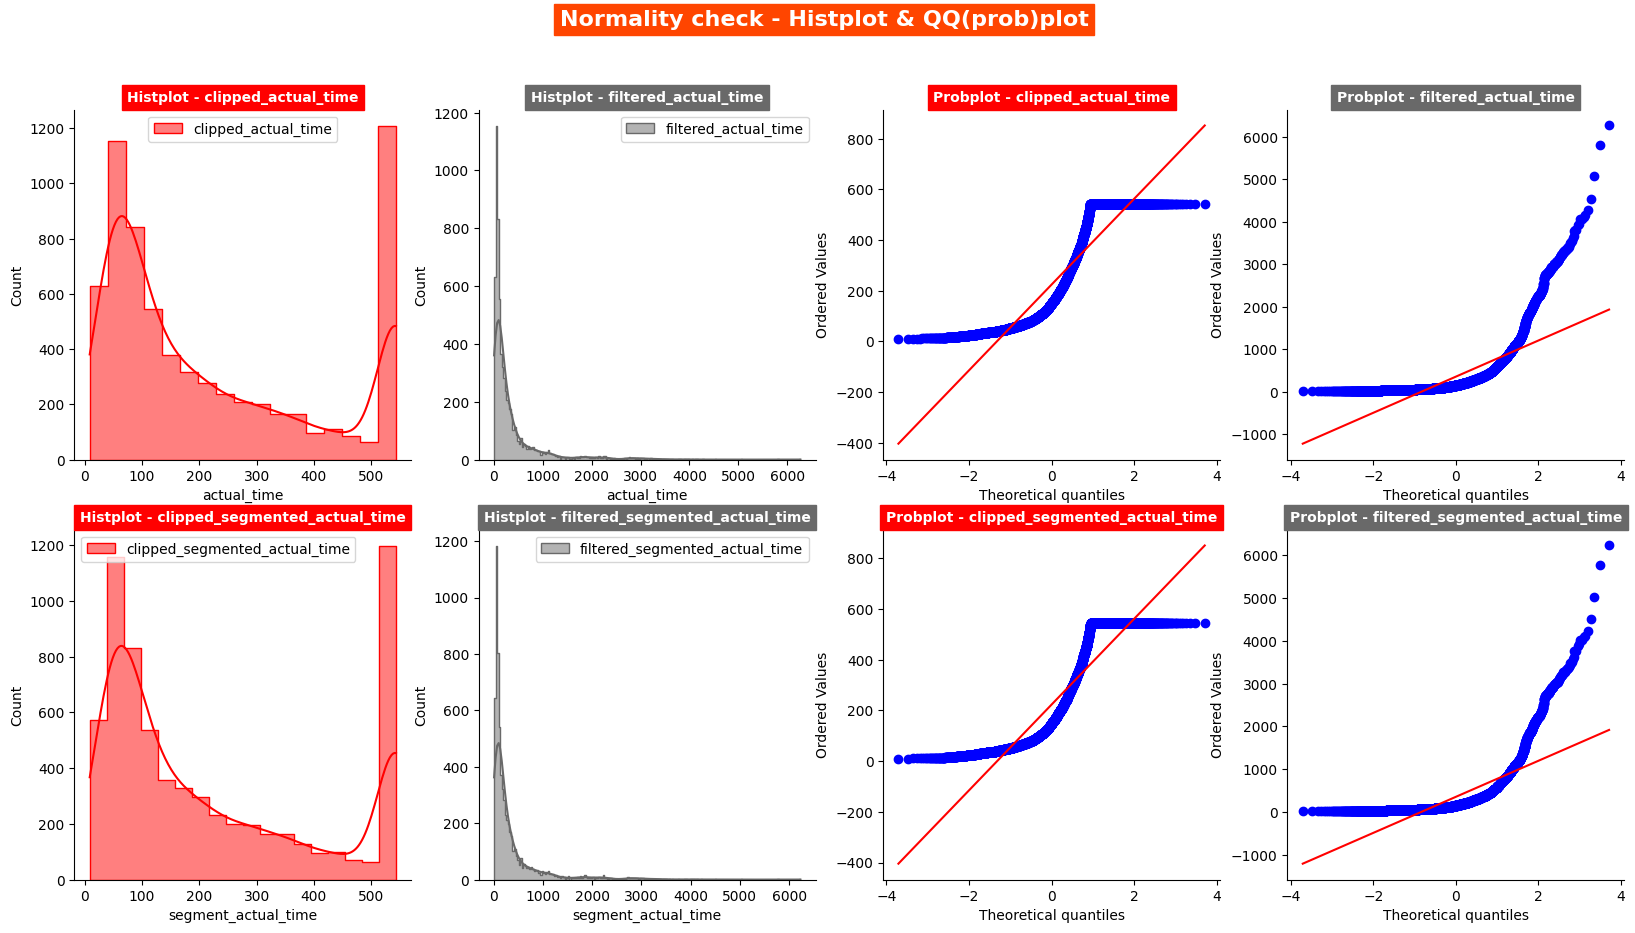

In [186]:
normality_plots("clipped_actual_time","clipped_segmented_actual_time","filtered_actual_time","filtered_segmented_actual_time",
                clipped_actual_time,clipped_segmented_actual_time,filtered_actual_time,filtered_segmented_actual_time)

In [187]:
col_names= ["clipped_actual_time","clipped_segmented_actual_time","filtered_actual_time","filtered_segmented_actual_time"]
cols = [clipped_actual_time,clipped_segmented_actual_time,filtered_actual_time,filtered_segmented_actual_time]

for _ in zip(col_names,cols):
    normality = Normality_check(_[0],_[1])
    normality.shapiro_and_anderson()
    normality.boxcox_transformation()

Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_actual_time column

Shapiro-Wilk Test
clipped_actual_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_actual_time - Data does not follow a normal distribution.

--------------------------------------------------
Performing BOXCOX transformation on clipped_actual_time column
Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_actual_time column

Shapiro-Wilk Test
clipped_actual_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_actual_time - Data does not follow a normal distribution.

--------------------------------------------------
Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_segmented_actual_time column

Shapiro-Wilk Test
clipped_segmented_actual_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_segmented_actual_time - Data does not follow a no

In [188]:
levene_test("clipped_actual_time","clipped_segmented_actual_time",clipped_actual_time,clipped_segmented_actual_time),
levene_test("filtered_actual_time","filtered_segmented_actual_time",filtered_actual_time,filtered_segmented_actual_time)

Performing Levene Test for clipped_actual_time & clipped_segmented_actual_time
Have Homogenous (similar) variance

--------------------------------------------------

Performing Levene Test for filtered_actual_time & filtered_segmented_actual_time
Have Homogenous (similar) variance

--------------------------------------------------



''

In [189]:
### MannWhitney u Rank test

test_cols = [("clipped_actual_time","clipped_segmented_actual_time",clipped_actual_time,clipped_segmented_actual_time),
       ("filtered_actual_time","filtered_segmented_actual_time",filtered_actual_time,filtered_segmented_actual_time)]

for _ in test_cols:
    mannwhitneyu_test(_[0],_[1],_[2],_[3])

Performing Non-parametric Test - MannWhitneyU for clipped_actual_time & clipped_segmented_actual_time
Failed to Reject Null Hypothesis - Accept Ho
There is NO significant difference in the Mean values of clipped_actual_time and clipped_segmented_actual_time

--------------------------------------------------

Performing Non-parametric Test - MannWhitneyU for filtered_actual_time & filtered_segmented_actual_time
Failed to Reject Null Hypothesis - Accept Ho
There is NO significant difference in the Mean values of filtered_actual_time and filtered_segmented_actual_time

--------------------------------------------------



##Insights:
- Even thought data is not gaussian , though it has similar variance (confirmed by Levene's test)

- It is confirmed that There is NO significant difference in the Mean values of Aggregated actual_time and segmented_actual_time through MannWHitneyU test.

#OSRM distance aggregated value and segment OSRM distance aggregated value.

In [190]:
filtered_num_df.sample()

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
1658,1.307777,78.0,9.034022,33.0,11.0,10.6435,33.0,11.0,10.6435,33.0,11.0,10.6435


In [191]:
clipped_num_df[['osrm_distance','segment_osrm_distance']].describe().T

,count,mean,std,min,25%,50%,75%,max
osrm_distance,6681.0,144.950719,163.239187,9.0729,30.955502,65.985100,204.741394,543.225452
segment_osrm_distance,6681.0,151.561949,165.780350,9.0729,32.950199,71.223404,215.281693,543.225452


In [192]:
filtered_num_df[['osrm_distance','segment_osrm_distance']].describe().T

,count,mean,std,min,25%,50%,75%,max
osrm_distance,6681.0,204.014145,368.380951,9.0729,30.955502,65.985100,204.741394,2839.660156
segment_osrm_distance,6681.0,222.448029,412.019104,9.0729,32.950199,71.223404,215.281693,3418.182861


In [193]:
clipped_osrm_distance = clipped_num_df['osrm_distance']
clipped_segmented_osrm_distance = clipped_num_df['segment_osrm_distance']
filtered_osrm_distance = filtered_num_df['osrm_distance']
filtered_segmented_osrm_distance = filtered_num_df['segment_osrm_distance']

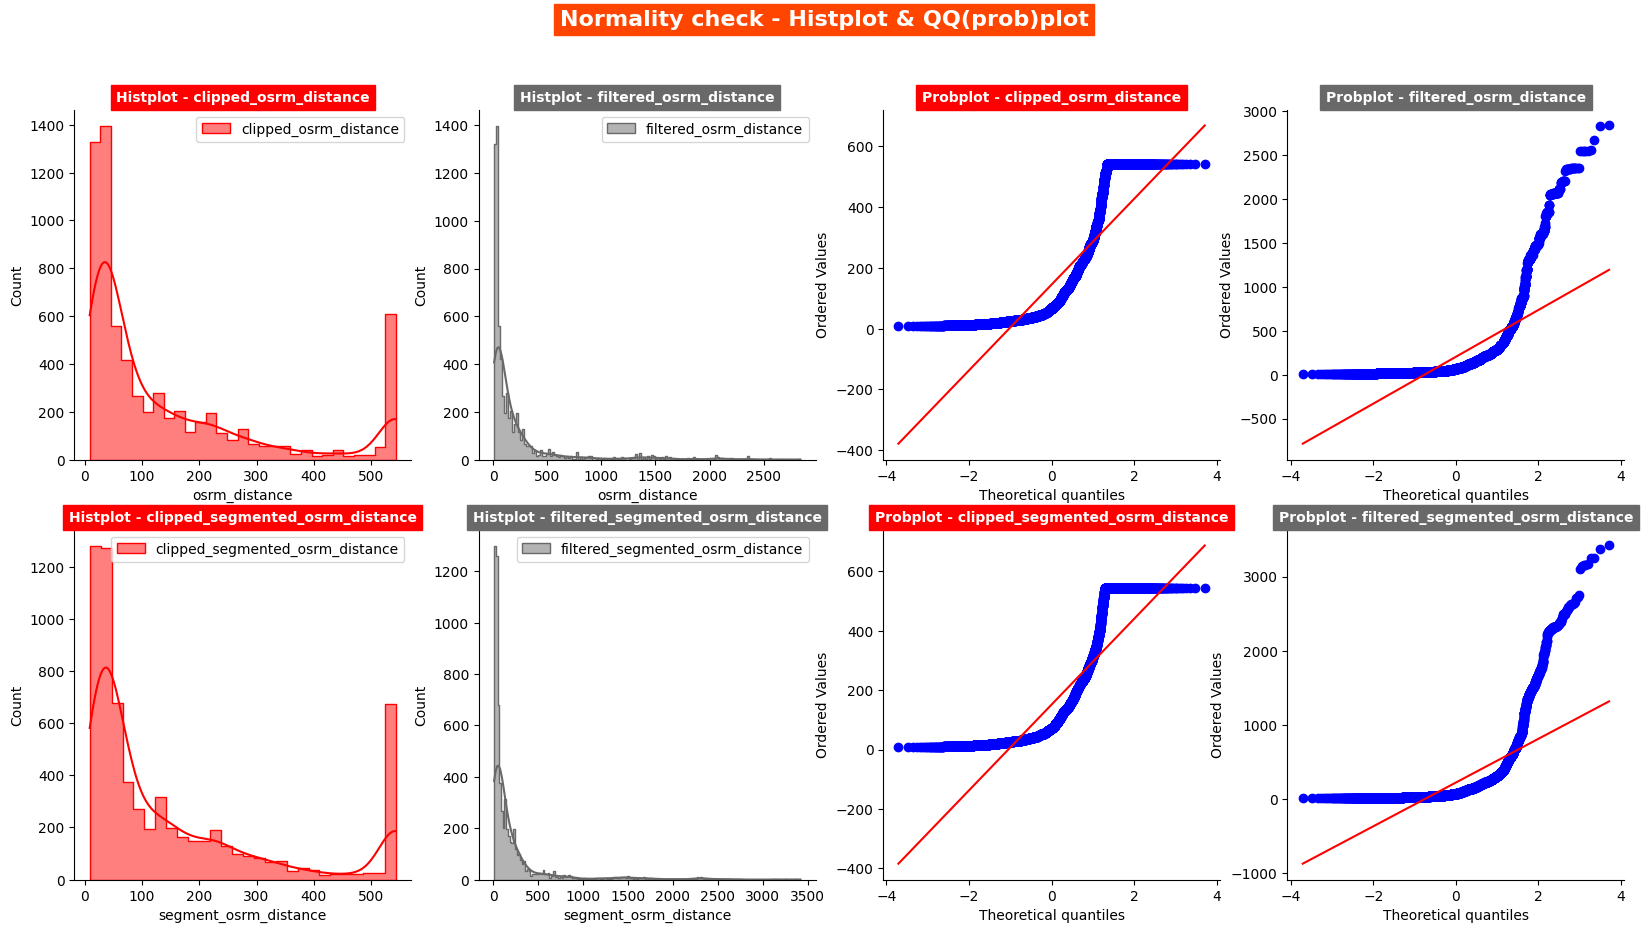

In [194]:
normality_plots("clipped_osrm_distance","clipped_segmented_osrm_distance","filtered_osrm_distance","filtered_segmented_osrm_distance",
                clipped_osrm_distance,clipped_segmented_osrm_distance,filtered_osrm_distance,filtered_segmented_osrm_distance)

In [195]:
col_names= ["clipped_osrm_distance","clipped_segmented_osrm_distance","filtered_osrm_distance","filtered_segmented_osrm_distance"]
cols = [clipped_osrm_distance,clipped_segmented_osrm_distance,filtered_osrm_distance,filtered_segmented_osrm_distance]

for _ in zip(col_names,cols):
    normality = Normality_check(_[0],_[1])
    normality.shapiro_and_anderson()
    normality.boxcox_transformation()

Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_osrm_distance column

Shapiro-Wilk Test
clipped_osrm_distance - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_osrm_distance - Data does not follow a normal distribution.

--------------------------------------------------
Performing BOXCOX transformation on clipped_osrm_distance column
Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_osrm_distance column

Shapiro-Wilk Test
clipped_osrm_distance - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_osrm_distance - Data does not follow a normal distribution.

--------------------------------------------------
Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_segmented_osrm_distance column

Shapiro-Wilk Test
clipped_segmented_osrm_distance - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_segmented_osrm_distance - Data 

In [196]:
levene_test("clipped_osrm_distance","clipped_segmented_osrm_distance",clipped_osrm_distance,clipped_segmented_osrm_distance),
levene_test("filtered_osrm_distance","filtered_segmented_osrm_distance",filtered_osrm_distance,filtered_segmented_osrm_distance)

Performing Levene Test for clipped_osrm_distance & clipped_segmented_osrm_distance
Have Homogenous (similar) variance

--------------------------------------------------

Performing Levene Test for filtered_osrm_distance & filtered_segmented_osrm_distance
Does not have Homogenous (different) Variance

--------------------------------------------------



''

In [197]:
### MannWhitney u Rank test

test_cols = [("clipped_osrm_distance","clipped_segmented_osrm_distance",clipped_osrm_distance,clipped_segmented_osrm_distance),
       ("filtered_osrm_distance","filtered_segmented_osrm_distance",filtered_osrm_distance,filtered_segmented_osrm_distance)]

for _ in test_cols:
    mannwhitneyu_test(_[0],_[1],_[2],_[3])

Performing Non-parametric Test - MannWhitneyU for clipped_osrm_distance & clipped_segmented_osrm_distance
Reject Null Hypothesis
There is a significant difference in the Mean values of clipped_osrm_distance and clipped_segmented_osrm_distance

--------------------------------------------------

Performing Non-parametric Test - MannWhitneyU for filtered_osrm_distance & filtered_segmented_osrm_distance
Reject Null Hypothesis
There is a significant difference in the Mean values of filtered_osrm_distance and filtered_segmented_osrm_distance

--------------------------------------------------



##Insights:
- It is confirmed that There is a significant difference in the Mean values of osrm_distance and segmented_osrm_distance aggregated through MannwhitneyU test.

#OSRM time aggregated value and segment OSRM time aggregated value.

In [198]:
filtered_num_df.sample()

,od_time_diff_hour,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum
210,1.366097,81.0,16.803877,34.0,18.0,22.0574,34.0,18.0,22.0574,34.0,18.0,22.0574


In [199]:
clipped_num_df[['osrm_time','segment_osrm_time']].describe().T

,count,mean,std,min,25%,50%,75%,max
osrm_time,6681.0,128.789523,151.099345,6.0,30.0,60.0,167.0,543.225452
segment_osrm_time,6681.0,137.598111,155.964638,6.0,31.0,65.0,184.0,543.225452


In [200]:
filtered_num_df[['osrm_time','segment_osrm_time']].describe().T

,count,mean,std,min,25%,50%,75%,max
osrm_time,6681.0,161.133957,269.826721,6.0,30.0,60.0,167.0,2032.0
segment_osrm_time,6681.0,180.391113,311.022125,6.0,31.0,65.0,184.0,2494.0


In [201]:
clipped_osrm_time = clipped_num_df['osrm_time']
clipped_segmented_osrm_time = clipped_num_df['segment_osrm_time']
filtered_osrm_time = filtered_num_df['osrm_time']
filtered_segmented_osrm_time = filtered_num_df['segment_osrm_time']

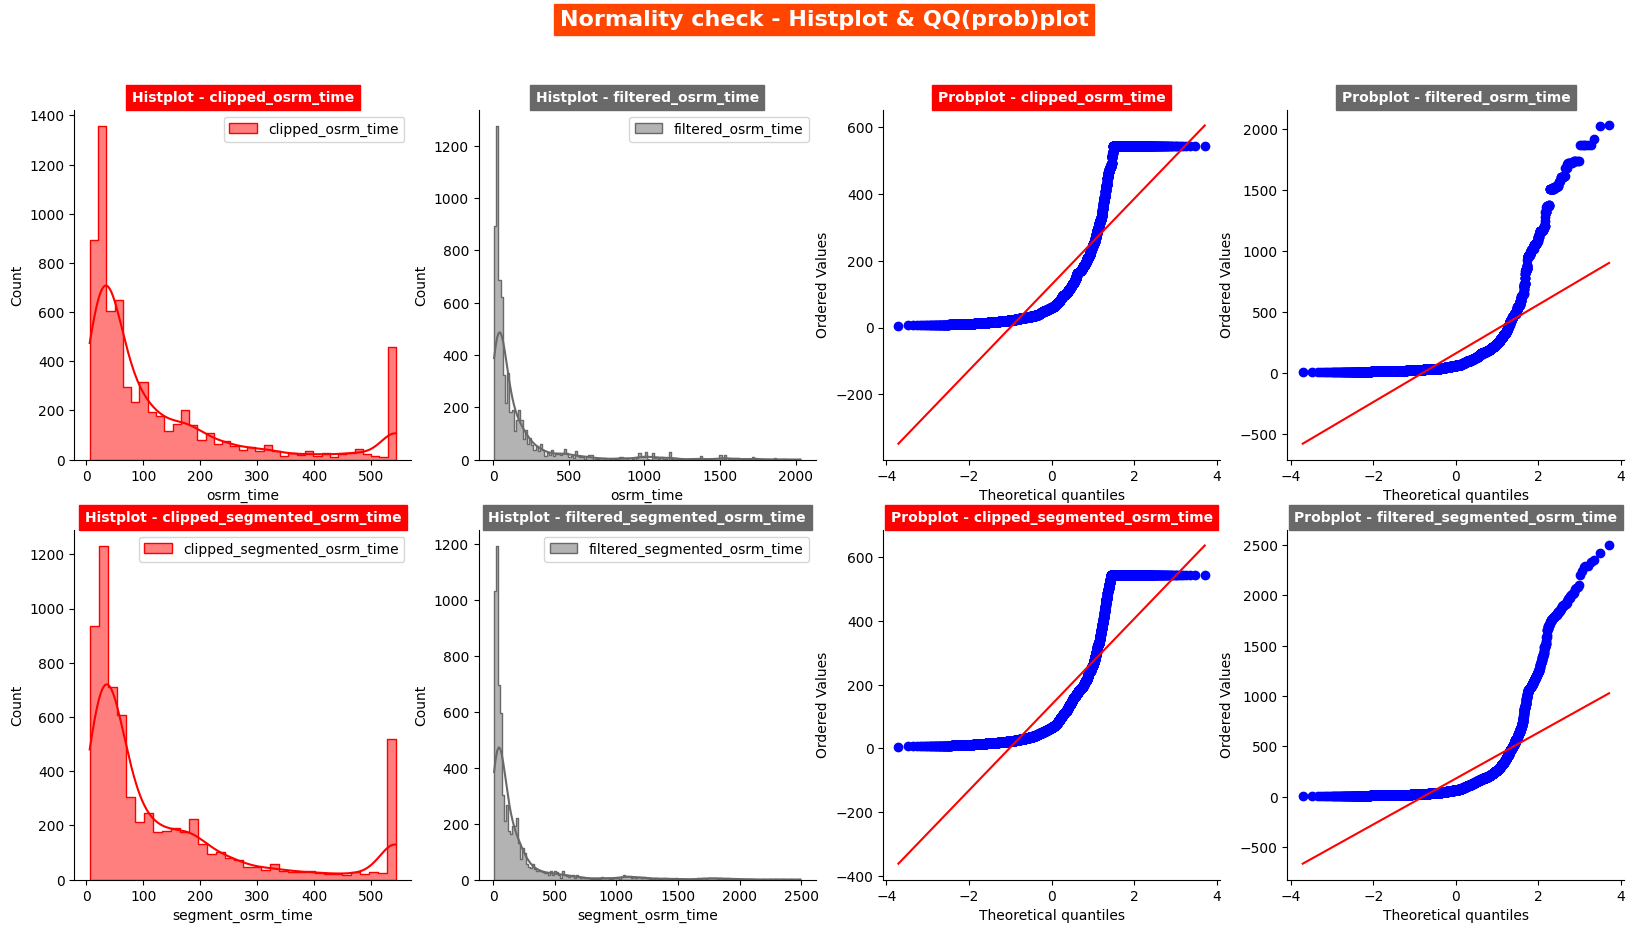

In [202]:
normality_plots("clipped_osrm_time","clipped_segmented_osrm_time","filtered_osrm_time","filtered_segmented_osrm_time",
                clipped_osrm_time,clipped_segmented_osrm_time,filtered_osrm_time,filtered_segmented_osrm_time)

In [203]:
col_names= ["clipped_osrm_time","clipped_segmented_osrm_time","filtered_osrm_time","filtered_segmented_osrm_time"]
cols = [clipped_osrm_time,clipped_segmented_osrm_time,filtered_osrm_time,filtered_segmented_osrm_time]

for _ in zip(col_names,cols):
    normality = Normality_check(_[0],_[1])
    normality.shapiro_and_anderson()
    normality.boxcox_transformation()

Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_osrm_time column

Shapiro-Wilk Test
clipped_osrm_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_osrm_time - Data does not follow a normal distribution.

--------------------------------------------------
Performing BOXCOX transformation on clipped_osrm_time column
Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_osrm_time column

Shapiro-Wilk Test
clipped_osrm_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_osrm_time - Data does not follow a normal distribution.

--------------------------------------------------
Performing SHAPIRO & ANDERSON-DARLING TEST for clipped_segmented_osrm_time column

Shapiro-Wilk Test
clipped_segmented_osrm_time - Data is not Gaussian

Since Shapiro-Wilk test is sensitive, we go with Anderson-Darling Test
clipped_segmented_osrm_time - Data does not follow a normal distribution.



In [204]:
levene_test("clipped_osrm_time","clipped_segmented_osrm_time",clipped_osrm_time,clipped_segmented_osrm_time),
levene_test("filtered_osrm_time","filtered_segmented_osrm_time",filtered_osrm_time,filtered_segmented_osrm_time)

Performing Levene Test for clipped_osrm_time & clipped_segmented_osrm_time
Does not have Homogenous (different) Variance

--------------------------------------------------

Performing Levene Test for filtered_osrm_time & filtered_segmented_osrm_time
Does not have Homogenous (different) Variance

--------------------------------------------------



''

In [205]:
### MannWhitney u Rank test

test_cols = [("clipped_osrm_time","clipped_segmented_osrm_time",clipped_osrm_time,clipped_segmented_osrm_time),
       ("filtered_osrm_time","filtered_segmented_osrm_time",filtered_osrm_time,filtered_segmented_osrm_time)]

for _ in test_cols:
    mannwhitneyu_test(_[0],_[1],_[2],_[3])

Performing Non-parametric Test - MannWhitneyU for clipped_osrm_time & clipped_segmented_osrm_time
Reject Null Hypothesis
There is a significant difference in the Mean values of clipped_osrm_time and clipped_segmented_osrm_time

--------------------------------------------------

Performing Non-parametric Test - MannWhitneyU for filtered_osrm_time & filtered_segmented_osrm_time
Reject Null Hypothesis
There is a significant difference in the Mean values of filtered_osrm_time and filtered_segmented_osrm_time

--------------------------------------------------



##Insights:
- It is confirmed that There is a significant difference in the Mean values of Aggregated osrm_time and segmented_osrm_time aggregated through MannwhitneyU test.

In [206]:
trip_df.sample()

,trip_uuid,data,route_type,od_start_time,od_end_time,od_time_diff_hour,trip_creation_time,trip_creation_month,trip_creation_year,trip_creation_day,trip_creation_hour,trip_creation_weekday,trip_creation_week,start_scan_to_end_scan,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_actual_time_sum,segment_osrm_time_sum,segment_osrm_distance_sum,source_name,source_city,source_state,source_place,destination_name,destination_city,destination_state,destination_place,corridor,state_corridor,city_corridor,trip_creation_day_week,trip_creation_dayofdate
6165,trip-153843754582557540,test,Carting,2018-10-01 23:45:45.825787,2018-10-02 02:02:54.534965,2.285753,2018-10-01 23:45:45.825787,10,2018,1,23,0,40,137.0,12.233445,108.0,17.0,16.955,108.0,21.0,16.8461,108.0,21.0,16.8461,PNQ Vadgaon Sheri DPC (Maharashtra),PNQ,Maharashtra,Vadgaon Sheri DPC,Pune Balaji Nagar (Maharashtra),Pune,Maharashtra,Balaji Nagar,PNQ Vadgaon Sheri DPC (Maharashtra) <---> Pune...,Maharashtra--PNQ <---> Maharashtra--Pune,PNQ--Vadgaon Sheri DPC <---> Pune--Balaji Nagar,Monday,1


In [207]:
# To find the busiest corridor, we'll look at the most common combinations of source and destination states
corridor_counts = trip_df.groupby(['source_state', 'destination_state']).size().reset_index(name='count')
busiest_corridor = corridor_counts.sort_values(by='count', ascending=False).head(1)

# Average distance and time taken for the busiest corridor
busiest_corridor_details = busiest_corridor.merge(trip_df, on=['source_state', 'destination_state'])
average_distance = busiest_corridor_details['actual_distance_to_destination'].mean()
average_time = busiest_corridor_details['od_time_diff_hour'].mean()

print("Busiest corridor:  ")
display(busiest_corridor)
print("Average distance:  ",average_distance)
print("Average time (in hours):  ",average_time)

Busiest corridor:  


,source_state,destination_state,count
81,Maharashtra,Maharashtra,1125


Average distance:   80.097374
Average time (in hours):   5.4897015645291365


#🤔💭Buisness Insights💭🤔
>**Based on EDA:**

- The Timeframe of the data is '2018-09-12' to '2018-10-08' i.e(26 days).
- 88% of the trips are from October Month & remaining are from November
- The entire data is heavily right skewed
- Almost all the features are heavy positively correleated with each other & which is intutive as well.
- Start & End dates of the months have less percent of trips compare to mid of the month. Though the difference is not huge
- Thats very strange to see that there is absolutely no trip from 4th- 11th day of the month
- Most orders come mid-month. That means customers usually make more orders in the mid of the month.
>**Route type:**

- The analysis reveals that a higher proportion of shipments are routed through Full Truck Load (FTL) as opposed to carting. This has important implications for the efficiency and speed of the delivery process.
>**Geographical Focus:**

Understanding the busiest routes and distances can help in optimizing logistics operations, improving transportation efficiency, and potentially reducing costs.

- State: The states of Haryana, Maharashtra, and Karnataka are not only busy - source states but also emerge as the busiest source states, indicating a high demand or significant business activities originating from these regions.

- source city: Gurgaon, Bangalore, and Bhiwandi are identified as the busiest source cities, suggesting that these cities play a crucial role in contributing to the overall business operations or transportation activities.

- Destination city: Gurgaon, Bangalore, and Hyderabad are identified as the busiest destination cities, underscoring their significance in terms of business activities or population movement.

- Busiest corridor: Overall, the busiest corridor is Mumbai_Maharashtra and Bangalore_Karnataka which has the maximum trips.

-- Average distance: 74.852844 kms
-- Average time (in hours): 5.346577921457034
>**Delivery Time & Distance Accuracy:**

**OSRM Time vs. Actual Time:**

- The difference between the mean values of estimated delivery time and actual delivery time suggests that there may be variations or delays in the actual delivery process compared to the initial estimates.
- The fact that the mean of OSRM time is less than the mean of actual delivery time indicates that the estimated times provided by the OSRM (Open Source Routing Machine) service tend to be optimistic.
**OSRM Distance vs. Actual Distance:**

- The mean of OSRM distance being greater than the mean of actual distance to the destination suggests that the OSRM might overestimate the distances. This could impact route planning and fuel efficiency calculations.
**Segment-wise time Analysis:**

- The equality in the mean values of actual time and segment actual time suggests that the time measurements are consistent across different segments of the delivery process
**Segment-wise distance Analysis:**

- The mean of segment OSRM distance being greater than the mean of OSRM distance implies that the OSRM might provide more conservative estimates for distance within individual segments.
>**Further look into :**

- As its depicted from the analysis that there is absolutely no trip from 4th- 11th day of the month, The reason for that can be figured out and catered to receive the orders in the these dates as well.

- More ways to promote FTL route handling system can be implemented to increase this percentage


#✴️⚡Business Recommendations⚡✴️
>**Route Optimization:**

- Given that the busiest state route is within Karnataka, it might be beneficial to optimize the transportation network within Karnataka to improve efficiency and reduce congestion. Consider implementing route optimization algorithms and real-time traffic monitoring to enhance the transportation system.
Since Gurgaon and Bangalore are identified as the busiest source and destination cities, respectively, focus on city-specific strategies to manage the high traffic volume.
>**Operational Efficiency:**

- Since mean of OSRM time is less than the mean of actual delivery time, Businesses could use this insight to set more realistic delivery time expectations for customers.
- Since the mean of OSRM distance greater than the mean of actual distance, Businesses should consider adjusting their distance estimations for more accurate logistics planning.
- Since the mean of segment OSRM distance greater than the mean of OSRM distance, along with this, we have the actual distance travelled, Businesses can use this information to fine-tune their route planning and optimize segment-specific logistics.
- Implement advanced demand forecasting techniques to anticipate peak travel times and adjust transportation services accordingly. This proactive approach can help in better resource allocation and minimize the impact of congestion during peak hours.
- Overall, the analysis hints at potential areas for operational improvement. Businesses could focus on refining their route planning algorithms, addressing discrepancies in estimated times and distances, and streamlining processes between different stages of delivery to enhance overall operational efficiency.
>**Customer Satisfaction:**

- Improving accuracy in estimated delivery times and distances can contribute to increased customer satisfaction.
- FTL shipments: Faster delivery times, facilitated by a higher proportion of FTL shipments, can directly impact customer satisfaction. Customers typically value timely deliveries, and this strategic choice aligns with meeting or exceeding customer expectations in terms of shipment speed.
- Customer profiling of the customers belonging to the states Maharashtra, Karnataka, Haryana, Tamil Nadu and Uttar Pradesh has to be done to get to know why major orders are coming from these atates and to improve customers' buying and delivery experience.
>**Cost Optimization:**

>**Customer profiling:**

- Understanding the differences in estimated and actual times and distances can aid in cost optimization efforts.
- Fine-tuning logistics planning based on more accurate measurements can lead to better resource allocation and potentially reduce operational costs.
>**Strategic Decision-making:**

- The preference for FTL over carting reflects a strategic decision by the logistics management.
- Understanding the reasons behind this choice and continuously evaluating its impact can guide future decision-making processes and help adapt to evolving business needs.
>**Collaboration with Stakeholders:**

- Collaborate with relevant stakeholders, including government authorities, transportation companies, and local communities, to develop and implement comprehensive strategies for managing and optimizing transportation in the identified busy corridors and cities.
